In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ================================================================
# STEP 00 — MAXIMUM MEMORY-SAFE KAGGLE CONFIGURATION
# ================================================================

import os
import gc
import torch

print("=" * 70)
print("STEP 00 — MAXIMUM MEMORY-SAFE CONFIGURATION")
print("=" * 70)

# ------------------------------------------------
# 1. CLEAN PYTHON MEMORY
# ------------------------------------------------
gc.collect()

# ------------------------------------------------
# 2. CLEAN GPU MEMORY
# ------------------------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------
# 3. PROJECT DIRECTORIES
# ------------------------------------------------
PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

BACKUP_DIR = os.path.join(
    PROJECT_DIR,
    "backups"
)

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------
# 4. MEMORY-SAFE TRAINING SETTINGS
# ------------------------------------------------
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_WORKERS = 0

PIN_MEMORY = False

PERSISTENT_WORKERS = False

NUM_EPOCHS = 10

NUM_CLASSES = 4

USE_AMP = torch.cuda.is_available()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ------------------------------------------------
# 5. GPU INFORMATION
# ------------------------------------------------
print("\nDevice       :", device)
print("GPU count    :", torch.cuda.device_count())
print("Batch size   :", BATCH_SIZE)
print("Num workers  :", NUM_WORKERS)
print("Pin memory   :", PIN_MEMORY)
print("Persistent   :", PERSISTENT_WORKERS)
print("AMP          :", USE_AMP)

if torch.cuda.is_available():

    for i in range(torch.cuda.device_count()):

        print(
            f"GPU {i}        : "
            f"{torch.cuda.get_device_name(i)}"
        )

        props = torch.cuda.get_device_properties(i)

        print(
            f"GPU {i} memory: "
            f"{props.total_memory/(1024**3):.2f} GB"
        )

# ------------------------------------------------
# 6. CHECK CURRENT GPU MEMORY
# ------------------------------------------------
if torch.cuda.is_available():

    print("\nCurrent GPU memory:")

    for i in range(torch.cuda.device_count()):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024**3)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024**3)
        )

        print(
            f"GPU {i}: "
            f"Allocated={allocated:.3f} GB | "
            f"Reserved={reserved:.3f} GB"
        )

print("\n" + "=" * 70)
print("✅ MAXIMUM MEMORY-SAFE CONFIGURATION READY")
print("=" * 70)

STEP 00 — MAXIMUM MEMORY-SAFE CONFIGURATION

Device       : cuda
GPU count    : 2
Batch size   : 32
Num workers  : 0
Pin memory   : False
Persistent   : False
AMP          : True
GPU 0        : Tesla T4
GPU 0 memory: 14.56 GB
GPU 1        : Tesla T4
GPU 1 memory: 14.56 GB

Current GPU memory:
GPU 0: Allocated=0.015 GB | Reserved=0.033 GB
GPU 1: Allocated=0.000 GB | Reserved=0.000 GB

✅ MAXIMUM MEMORY-SAFE CONFIGURATION READY


In [3]:
# ============================================================
# PROJECT PERSISTENCE SETUP
# ============================================================

import os
import json
from datetime import datetime

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR       = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
BACKUP_DIR     = os.path.join(PROJECT_DIR, "backups")

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories ready.")
print("PROJECT_DIR:", PROJECT_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("BACKUP_DIR:", BACKUP_DIR)

Project directories ready.
PROJECT_DIR: /kaggle/working/skin_cancer_project
CHECKPOINT_DIR: /kaggle/working/skin_cancer_project/checkpoints
DATA_DIR: /kaggle/working/skin_cancer_project/data
RESULTS_DIR: /kaggle/working/skin_cancer_project/results
BACKUP_DIR: /kaggle/working/skin_cancer_project/backups


In [4]:
# STEP 1 — Project Configuration and Safe Storage Setup

import os
import random
import numpy as np
import pandas as pd
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project folders
PROJECT_DIR = "/kaggle/working/skin_cancer_project"
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Final cancer classes
CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = len(CLASS_NAMES)

# Dataset paths
HAM_ROOT = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

ISIC_ROOT = "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"

DERMA_ROOT = "/kaggle/input/datasets/hiro002/dermacon-in-d-dataset"

MCC_ROOT = "/kaggle/input/datasets/quantumcoders03/datasetmcc"

MCC_NEW_ROOTS = [
    "/kaggle/input/datasets/quantumcoders03/mcc-1-dataset",
    "/kaggle/input/datasets/quantumcoders03/mcc-2-datatset",
    "/kaggle/input/datasets/quantumcoders03/mcc-3-datatse"
]

print("=" * 60)
print("PROJECT SETUP")
print("=" * 60)

print("Project directory :", PROJECT_DIR)
print("Checkpoint folder :", CHECKPOINT_DIR)
print("Data folder       :", DATA_DIR)
print("Results folder    :", RESULTS_DIR)

print("\nClasses:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")

print("\nDataset paths:")
print("HAM10000 :", os.path.exists(HAM_ROOT))
print("ISIC     :", os.path.exists(ISIC_ROOT))
print("DermaCon :", os.path.exists(DERMA_ROOT))
print("MCC      :", os.path.exists(MCC_ROOT))

for i, path in enumerate(MCC_NEW_ROOTS, 1):
    print(f"MCC-{i}    :", os.path.exists(path))

print("\nPyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("Seed           :", SEED)

PROJECT SETUP
Project directory : /kaggle/working/skin_cancer_project
Checkpoint folder : /kaggle/working/skin_cancer_project/checkpoints
Data folder       : /kaggle/working/skin_cancer_project/data
Results folder    : /kaggle/working/skin_cancer_project/results

Classes:
0 -> Melanoma
1 -> BCC
2 -> SCC
3 -> MCC

Dataset paths:
HAM10000 : True
ISIC     : True
DermaCon : False
MCC      : False
MCC-1    : False
MCC-2    : False
MCC-3    : False

PyTorch version: 2.10.0+cu128
CUDA available : True
Seed           : 42


In [5]:
# ============================================================
# PROJECT PERSISTENCE SETUP
# ============================================================

import os
import json
from datetime import datetime

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_DIR       = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
BACKUP_DIR     = os.path.join(PROJECT_DIR, "backups")

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories ready.")
print("PROJECT_DIR:", PROJECT_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("BACKUP_DIR:", BACKUP_DIR)

Project directories ready.
PROJECT_DIR: /kaggle/working/skin_cancer_project
CHECKPOINT_DIR: /kaggle/working/skin_cancer_project/checkpoints
DATA_DIR: /kaggle/working/skin_cancer_project/data
RESULTS_DIR: /kaggle/working/skin_cancer_project/results
BACKUP_DIR: /kaggle/working/skin_cancer_project/backups


In [6]:
# STEP 2 — Verify Dataset Paths and Folder Structure

import os

print("=" * 70)
print("DATASET STRUCTURE CHECK")
print("=" * 70)

# Show all available dataset folders
datasets_root = "/kaggle/input/datasets"

print("\nAvailable dataset folders:")
for item in sorted(os.listdir(datasets_root)):
    print(" -", item)

# Search for DermaCon-related folders
print("\n" + "=" * 70)
print("DERMACON SEARCH")
print("=" * 70)

for root, dirs, files in os.walk(datasets_root):
    root_lower = root.lower()

    if "derma" in root_lower or "dermacon" in root_lower:
        print("\nFolder:", root)
        print("Subfolders:", dirs[:10])
        print("Files:", files[:10])

# Check the other important datasets
print("\n" + "=" * 70)
print("IMPORTANT DATASET CHECK")
print("=" * 70)

paths_to_check = {
    "HAM10000": HAM_ROOT,
    "ISIC": ISIC_ROOT,
    "MCC": MCC_ROOT,
    "MCC-1": MCC_NEW_ROOTS[0],
    "MCC-2": MCC_NEW_ROOTS[1],
    "MCC-3": MCC_NEW_ROOTS[2]
}

for name, path in paths_to_check.items():
    print(f"\n{name}")
    print("Path:", path)
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        try:
            items = os.listdir(path)
            print("Items:", items[:10])
        except Exception as e:
            print("Error:", e)

DATASET STRUCTURE CHECK

Available dataset folders:
 - ahmedxc4
 - hiro002
 - kmader
 - nodoubttome
 - quantumcoders07
 - riyaelizashaju
 - tomooinubushi

DERMACON SEARCH

Folder: /kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/dermatofibroma
Subfolders: []
Files: ['ISIC_0024845.jpg', 'ISIC_0011865.jpg', 'ISIC_0001114.jpg', 'ISIC_0011478.jpg', 'ISIC_0011677.jpg', 'ISIC_0024330.jpg', 'ISIC_0024994.jpg', 'ISIC_0024973.jpg', 'ISIC_0011410.jpg', 'ISIC_0024396.jpg']

Folder: /kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma
Subfolders: []
Files: ['ISIC_0027107.jpg', 'ISIC_0029973.jpg', 'ISIC_0025954.jpg', 'ISIC_0027216.jpg', 'ISIC_0029297.jpg', 'ISIC_0032468.jpg', 'ISIC_0031457.jpg', 'ISIC_0033554.jpg', 'ISIC_0029578.jpg', 'ISIC_0031271.jpg']

Folder: /kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/skin cancer

In [7]:
import os
import gc
import torch

print("=" * 70)
print("MEMORY / KERNEL STATUS CHECK")
print("=" * 70)

# Python garbage collection
gc.collect()

# GPU memory
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / (1024**3)
        reserved = torch.cuda.memory_reserved(i) / (1024**3)

        print(f"GPU {i}:")
        print(f"  Allocated: {allocated:.2f} GB")
        print(f"  Reserved : {reserved:.2f} GB")

print("\nKernel restarted successfully.")
print("=" * 70)

MEMORY / KERNEL STATUS CHECK
GPU 0:
  Allocated: 0.02 GB
  Reserved : 0.03 GB
GPU 1:
  Allocated: 0.00 GB
  Reserved : 0.00 GB

Kernel restarted successfully.


In [8]:
import os

print("=" * 70)
print("CURRENT WORKING FILES")
print("=" * 70)

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

if os.path.exists(PROJECT_DIR):
    for root, dirs, files in os.walk(PROJECT_DIR):
        for f in files:
            path = os.path.join(root, f)
            size_mb = os.path.getsize(path) / (1024 * 1024)
            print(f"{size_mb:8.2f} MB | {path}")
else:
    print("PROJECT DIRECTORY NOT FOUND")

print("=" * 70)

CURRENT WORKING FILES
    7.19 MB | /kaggle/working/skin_cancer_project/results/step12e_random_visual_quality_check.png
    0.01 MB | /kaggle/working/skin_cancer_project/data/mcc_direct_source_audit.csv
    1.64 MB | /kaggle/working/skin_cancer_project/data/final_4class_classification_dataset.csv
    0.00 MB | /kaggle/working/skin_cancer_project/data/missing_mcc_from_final_dataset.csv
    1.65 MB | /kaggle/working/skin_cancer_project/data/final_4class_classification_dataset_with_mcc.csv
    0.23 MB | /kaggle/working/skin_cancer_project/data/ham10000_preprocessed.csv
    0.01 MB | /kaggle/working/skin_cancer_project/data/unique_mcc_manifest.csv
    0.01 MB | /kaggle/working/skin_cancer_project/data/step12c_mcc_existing_overlap_audit.csv
    0.25 MB | /kaggle/working/skin_cancer_project/data/val.csv
    1.82 MB | /kaggle/working/skin_cancer_project/data/isic2024_preprocessed.csv
    0.25 MB | /kaggle/working/skin_cancer_project/data/test.csv
    0.01 MB | /kaggle/working/skin_cancer_proj

In [9]:
import os
import torch

checkpoint_path = (
    "/kaggle/working/skin_cancer_project/"
    "checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth"
)

print("=" * 70)
print("FINAL EFFICIENTNET-B0 CHECKPOINT VERIFICATION")
print("=" * 70)

if os.path.exists(checkpoint_path):

    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)

    print("✅ CHECKPOINT FOUND")
    print(f"Path : {checkpoint_path}")
    print(f"Size : {size_mb:.2f} MB")

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    print("\nCheckpoint information:")
    print("Epoch       :", checkpoint.get("epoch"))
    print("Val Loss    :", checkpoint.get("val_loss"))
    print("Val Accuracy:", checkpoint.get("val_acc"))
    print("Model       :", checkpoint.get("model_name"))
    print("Input size  :", checkpoint.get("input_size"))
    print("Classes     :", checkpoint.get("class_names"))

else:
    print("❌ CHECKPOINT NOT FOUND")

print("=" * 70)

FINAL EFFICIENTNET-B0 CHECKPOINT VERIFICATION
✅ CHECKPOINT FOUND
Path : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth
Size : 46.41 MB

Checkpoint information:
Epoch       : 1
Val Loss    : 1.5669569755390607
Val Accuracy: 0.6111111111111112
Model       : EfficientNet-B0
Input size  : 224
Classes     : ['Melanoma', 'BCC', 'SCC', 'MCC']


In [10]:
# STEP 3 — Load and Inspect Main Dataset Metadata

import os
import pandas as pd

print("=" * 70)
print("STEP 3 — METADATA INSPECTION")
print("=" * 70)

# ---------------------------------------------------------
# 1. Correct DermaCon-IN path
# ---------------------------------------------------------

DERMA_ROOT = "/kaggle/input/datasets/hiro002/dermacon-in-dataset"

print("\nDermaCon-IN path:")
print(DERMA_ROOT)
print("Exists:", os.path.exists(DERMA_ROOT))

# ---------------------------------------------------------
# 2. HAM10000 metadata
# ---------------------------------------------------------

HAM_METADATA_PATH = os.path.join(
    HAM_ROOT,
    "HAM10000_metadata.csv"
)

ham = pd.read_csv(HAM_METADATA_PATH)

print("\n" + "-" * 70)
print("HAM10000")
print("-" * 70)

print("Shape:", ham.shape)
print("Columns:")
print(ham.columns.tolist())

print("\nDiagnosis distribution:")
print(ham["dx"].value_counts())

# ---------------------------------------------------------
# 3. ISIC 2024 metadata
# ---------------------------------------------------------

ISIC_METADATA_PATH = os.path.join(
    ISIC_ROOT,
    "metadata.csv"
)

isic = pd.read_csv(
    ISIC_METADATA_PATH,
    low_memory=False
)

print("\n" + "-" * 70)
print("ISIC 2024")
print("-" * 70)

print("Shape:", isic.shape)
print("Columns:")
print(isic.columns.tolist())

print("\nDiagnosis distribution — top 20:")
print(isic["diagnosis"].value_counts().head(20))

# ---------------------------------------------------------
# 4. DermaCon-IN metadata
# ---------------------------------------------------------

DERMA_METADATA_PATH = os.path.join(
    DERMA_ROOT,
    "METADATA",
    "Skin_Metadata.csv"
)

derma = pd.read_csv(DERMA_METADATA_PATH)

print("\n" + "-" * 70)
print("DermaCon-IN")
print("-" * 70)

print("Shape:", derma.shape)
print("Columns:")
print(derma.columns.tolist())

print("\nDisease distribution:")
print(derma["Disease_label"].value_counts().head(20))

# ---------------------------------------------------------
# 5. Candidate SCC dataset inspection
# ---------------------------------------------------------

SCC_CANDIDATE_ROOT = "/kaggle/input/datasets/ahmedxc4/skin-ds"

print("\n" + "-" * 70)
print("SCC CANDIDATE DATASET")
print("-" * 70)

print("Path:", SCC_CANDIDATE_ROOT)
print("Exists:", os.path.exists(SCC_CANDIDATE_ROOT))

if os.path.exists(SCC_CANDIDATE_ROOT):

    for split in ["train", "val", "test"]:

        split_path = os.path.join(
            SCC_CANDIDATE_ROOT,
            split
        )

        if os.path.exists(split_path):

            print(f"\n{split.upper()} folders:")

            folders = sorted([
                x for x in os.listdir(split_path)
                if os.path.isdir(os.path.join(split_path, x))
            ])

            for folder in folders:
                folder_path = os.path.join(
                    split_path,
                    folder
                )

                image_count = sum(
                    1
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(
                        (".jpg", ".jpeg", ".png")
                    )
                )

                print(f"  {folder}: {image_count}")

print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

STEP 3 — METADATA INSPECTION

DermaCon-IN path:
/kaggle/input/datasets/hiro002/dermacon-in-dataset
Exists: True

----------------------------------------------------------------------
HAM10000
----------------------------------------------------------------------
Shape: (10015, 7)
Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

----------------------------------------------------------------------
ISIC 2024
----------------------------------------------------------------------
Shape: (81722, 28)
Columns:
['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'benign_malignant', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'mel

In [11]:
# STEP 4 — HAM10000 Cancer Image Records

import os
import pandas as pd

print("=" * 70)
print("STEP 4 — HAM10000 PREPROCESSING")
print("=" * 70)

# ---------------------------------------------------------
# 1. HAM10000 metadata
# ---------------------------------------------------------

ham_mapping = {
    "mel": 0,   # Melanoma
    "bcc": 1    # Basal Cell Carcinoma
}

ham_cancer = ham[
    ham["dx"].isin(ham_mapping.keys())
].copy()

# ---------------------------------------------------------
# 2. Create standardized dataframe
# ---------------------------------------------------------

ham_df = pd.DataFrame()

ham_df["image_name"] = ham_cancer["image_id"]
ham_df["class_name"] = ham_cancer["dx"].map({
    "mel": "Melanoma",
    "bcc": "Basal Cell Carcinoma"
})
ham_df["label"] = ham_cancer["dx"].map(ham_mapping)
ham_df["age"] = ham_cancer["age"]
ham_df["sex"] = ham_cancer["sex"]
ham_df["dataset"] = "HAM10000"

# ---------------------------------------------------------
# 3. Find actual image path
# ---------------------------------------------------------

HAM_IMAGE_DIRS = [
    os.path.join(HAM_ROOT, "HAM10000_images_part_1"),
    os.path.join(HAM_ROOT, "HAM10000_images_part_2"),
    os.path.join(HAM_ROOT, "ham10000_images_part_1"),
    os.path.join(HAM_ROOT, "ham10000_images_part_2")
]

# Create filename -> full path lookup
ham_image_lookup = {}

for image_dir in HAM_IMAGE_DIRS:

    if os.path.exists(image_dir):

        for filename in os.listdir(image_dir):

            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                image_id = os.path.splitext(filename)[0]
                ham_image_lookup[image_id] = os.path.join(
                    image_dir,
                    filename
                )

ham_df["image_path"] = ham_df["image_name"].map(
    ham_image_lookup
)

# ---------------------------------------------------------
# 4. Validate image paths
# ---------------------------------------------------------

ham_df["image_exists"] = ham_df["image_path"].apply(
    lambda x: os.path.isfile(x)
)

# ---------------------------------------------------------
# 5. Remove records without images
# ---------------------------------------------------------

before_count = len(ham_df)

ham_df = ham_df[
    ham_df["image_exists"]
].copy()

after_count = len(ham_df)

# ---------------------------------------------------------
# 6. Reset index
# ---------------------------------------------------------

ham_df = ham_df.reset_index(drop=True)

# ---------------------------------------------------------
# 7. Save intermediate preprocessing result
# ---------------------------------------------------------

ham_save_path = os.path.join(
    DATA_DIR,
    "ham10000_preprocessed.csv"
)

ham_df.to_csv(
    ham_save_path,
    index=False
)

# ---------------------------------------------------------
# 8. Results
# ---------------------------------------------------------

print("\nHAM10000 relevant records BEFORE image check:", before_count)
print("HAM10000 records AFTER image check :", after_count)
print("Images removed due to missing path :", before_count - after_count)

print("\nClass distribution:")
print(ham_df["class_name"].value_counts())

print("\nLabel distribution:")
print(ham_df["label"].value_counts().sort_index())

print("\nDataset distribution:")
print(ham_df["dataset"].value_counts())

print("\nImage existence:")
print(ham_df["image_exists"].value_counts())

print("\nSample records:")
display(
    ham_df[
        [
            "image_name",
            "class_name",
            "label",
            "age",
            "sex",
            "image_path"
        ]
    ].head()
)

print("\nSaved to:")
print(ham_save_path)

print("\n" + "=" * 70)
print("STEP 4 COMPLETE")
print("=" * 70)

STEP 4 — HAM10000 PREPROCESSING

HAM10000 relevant records BEFORE image check: 1627
HAM10000 records AFTER image check : 1627
Images removed due to missing path : 0

Class distribution:
class_name
Melanoma                1113
Basal Cell Carcinoma     514
Name: count, dtype: int64

Label distribution:
label
0    1113
1     514
Name: count, dtype: int64

Dataset distribution:
dataset
HAM10000    1627
Name: count, dtype: int64

Image existence:
image_exists
True    1627
Name: count, dtype: int64

Sample records:


,image_name,class_name,label,age,sex,image_path
0,ISIC_0025964,Melanoma,0,40.0,female,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0030623,Melanoma,0,40.0,female,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0027190,Melanoma,0,80.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0031023,Melanoma,0,60.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0028086,Melanoma,0,60.0,male,/kaggle/input/datasets/kmader/skin-cancer-mnis...



Saved to:
/kaggle/working/skin_cancer_project/data/ham10000_preprocessed.csv

STEP 4 COMPLETE


In [12]:
# STEP 5 — ISIC 2024 Preprocessing

import os
import pandas as pd

print("=" * 70)
print("STEP 5 — ISIC 2024 PREPROCESSING")
print("=" * 70)

# ---------------------------------------------------------
# 1. Define cancer diagnosis mapping
# ---------------------------------------------------------

ISIC_MAPPING = {
    "melanoma": 0,
    "melanoma metastasis": 0,
    "basal cell carcinoma": 1,
    "squamous cell carcinoma": 2
}

ISIC_CLASS_NAMES = {
    0: "Melanoma",
    1: "Basal Cell Carcinoma",
    2: "Squamous Cell Carcinoma"
}

# ---------------------------------------------------------
# 2. Select only required cancer diagnoses
# ---------------------------------------------------------

isic_cancer = isic[
    isic["diagnosis"].astype(str).str.lower().isin(
        ISIC_MAPPING.keys()
    )
].copy()

print("\nSelected ISIC cancer records:", len(isic_cancer))

# ---------------------------------------------------------
# 3. Standardized dataframe
# ---------------------------------------------------------

isic_df = pd.DataFrame()

isic_df["image_name"] = isic_cancer["isic_id"]

isic_df["class_name"] = (
    isic_cancer["diagnosis"]
    .astype(str)
    .str.lower()
    .map(ISIC_MAPPING)
    .map(ISIC_CLASS_NAMES)
)

isic_df["label"] = (
    isic_cancer["diagnosis"]
    .astype(str)
    .str.lower()
    .map(ISIC_MAPPING)
)

isic_df["age"] = isic_cancer["age_approx"]
isic_df["sex"] = isic_cancer["sex"]
isic_df["dataset"] = "ISIC 2024"

# ---------------------------------------------------------
# 4. Build ISIC image lookup
# ---------------------------------------------------------

ISIC_IMAGE_DIR = os.path.join(
    ISIC_ROOT,
    "images"
)

print("\nISIC image directory:")
print(ISIC_IMAGE_DIR)
print("Exists:", os.path.exists(ISIC_IMAGE_DIR))

isic_image_lookup = {}

if os.path.exists(ISIC_IMAGE_DIR):

    for filename in os.listdir(ISIC_IMAGE_DIR):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_id = os.path.splitext(filename)[0]

            isic_image_lookup[image_id] = os.path.join(
                ISIC_IMAGE_DIR,
                filename
            )

# ---------------------------------------------------------
# 5. Match metadata IDs to actual images
# ---------------------------------------------------------

isic_df["image_path"] = isic_df["image_name"].map(
    isic_image_lookup
)

# ---------------------------------------------------------
# 6. Check image existence
# ---------------------------------------------------------

isic_df["image_exists"] = isic_df["image_path"].apply(
    lambda x: os.path.isfile(x)
)

missing_count = (~isic_df["image_exists"]).sum()

print("\nMissing image paths:", missing_count)

# ---------------------------------------------------------
# 7. Keep only records with valid images
# ---------------------------------------------------------

before_count = len(isic_df)

isic_df = isic_df[
    isic_df["image_exists"]
].copy()

after_count = len(isic_df)

isic_df = isic_df.reset_index(drop=True)

# ---------------------------------------------------------
# 8. Save intermediate result
# ---------------------------------------------------------

isic_save_path = os.path.join(
    DATA_DIR,
    "isic2024_preprocessed.csv"
)

isic_df.to_csv(
    isic_save_path,
    index=False
)

# ---------------------------------------------------------
# 9. Results
# ---------------------------------------------------------

print("\nRecords BEFORE image check:", before_count)
print("Records AFTER image check :", after_count)
print("Removed records           :", before_count - after_count)

print("\nClass distribution:")
print(isic_df["class_name"].value_counts())

print("\nLabel distribution:")
print(
    isic_df["label"]
    .value_counts()
    .sort_index()
)

print("\nDiagnosis/source distribution:")
print(isic_cancer["diagnosis"].value_counts())

print("\nImage existence:")
print(isic_df["image_exists"].value_counts())

print("\nSample records:")
display(
    isic_df[
        [
            "image_name",
            "class_name",
            "label",
            "age",
            "sex",
            "image_path"
        ]
    ].head()
)

print("\nSaved to:")
print(isic_save_path)

print("\n" + "=" * 70)
print("STEP 5 COMPLETE")
print("=" * 70)

STEP 5 — ISIC 2024 PREPROCESSING

Selected ISIC cancer records: 13681

ISIC image directory:
/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/images
Exists: True

Missing image paths: 0

Records BEFORE image check: 13681
Records AFTER image check : 13681
Removed records           : 0

Class distribution:
class_name
Melanoma                   7388
Basal Cell Carcinoma       4921
Squamous Cell Carcinoma    1372
Name: count, dtype: int64

Label distribution:
label
0    7388
1    4921
2    1372
Name: count, dtype: int64

Diagnosis/source distribution:
diagnosis
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
melanoma metastasis          39
Name: count, dtype: int64

Image existence:
image_exists
True    13681
Name: count, dtype: int64

Sample records:


,image_name,class_name,label,age,sex,image_path
0,ISIC_7244280,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
1,ISIC_5054247,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
2,ISIC_6683697,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...
3,ISIC_1633321,Melanoma,0,80.0,male,/kaggle/input/datasets/tomooinubushi/all-isic-...
4,ISIC_8353193,Melanoma,0,65.0,female,/kaggle/input/datasets/tomooinubushi/all-isic-...



Saved to:
/kaggle/working/skin_cancer_project/data/isic2024_preprocessed.csv

STEP 5 COMPLETE


In [13]:
# STEP 6 — DermaCon-IN Cancer Records Check

import os
import pandas as pd

print("=" * 70)
print("STEP 6 — DERMACON-IN CANCER DATA CHECK")
print("=" * 70)

# ---------------------------------------------------------
# 1. Find all cancer-related disease labels
# ---------------------------------------------------------

cancer_keywords = [
    "melanoma",
    "basal cell",
    "squamous cell",
    "merkel"
]

derma_labels = (
    derma["Disease_label"]
    .astype(str)
    .str.strip()
)

mask = derma_labels.str.lower().str.contains(
    "|".join(cancer_keywords),
    na=False
)

derma_cancer_check = derma[mask].copy()

print("\nCancer-related records found:",
      len(derma_cancer_check))

print("\nCancer-related disease labels:")
print(
    derma_cancer_check["Disease_label"]
    .value_counts()
)

# ---------------------------------------------------------
# 2. Check image directories
# ---------------------------------------------------------

DERMA_IMAGE_ROOT = os.path.join(
    DERMA_ROOT,
    "DATASET"
)

print("\n" + "-" * 70)
print("DermaCon-IN image folders")
print("-" * 70)

for root, dirs, files in os.walk(DERMA_IMAGE_ROOT):

    image_files = [
        f for f in files
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if image_files:
        print("\nFolder:", root)
        print("Number of images:", len(image_files))
        print("Sample:", image_files[:5])

# ---------------------------------------------------------
# 3. Build image filename lookup
# ---------------------------------------------------------

derma_image_lookup = {}

for root, dirs, files in os.walk(DERMA_IMAGE_ROOT):

    for filename in files:

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            derma_image_lookup[filename] = os.path.join(
                root,
                filename
            )

# ---------------------------------------------------------
# 4. Check whether cancer metadata images exist
# ---------------------------------------------------------

if len(derma_cancer_check) > 0:

    derma_cancer_check["image_path"] = (
        derma_cancer_check["Image_name"]
        .astype(str)
        .map(derma_image_lookup)
    )

    derma_cancer_check["image_exists"] = (
        derma_cancer_check["image_path"]
        .apply(lambda x: os.path.isfile(x))
    )

    print("\n" + "-" * 70)
    print("Cancer metadata → image matching")
    print("-" * 70)

    print(
        derma_cancer_check["image_exists"]
        .value_counts()
    )

    print("\nSample matched records:")

    display(
        derma_cancer_check[
            [
                "Image_name",
                "Disease_label",
                "Age",
                "Sex",
                "image_path",
                "image_exists"
            ]
        ].head(10)
    )

else:

    print("\nNo cancer-related DermaCon-IN records found.")

print("\n" + "=" * 70)
print("STEP 6 COMPLETE")
print("=" * 70)

STEP 6 — DERMACON-IN CANCER DATA CHECK

Cancer-related records found: 17

Cancer-related disease labels:
Disease_label
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64

----------------------------------------------------------------------
DermaCon-IN image folders
----------------------------------------------------------------------

Folder: /kaggle/input/datasets/hiro002/dermacon-in-dataset/DATASET/DATASET_0/DATASET_0
Number of images: 2626
Sample: ['IMG_2104.jpg', 'IMG_1306.jpg', 'IMG_2771.jpg', 'IMG_3912.jpg', 'IMG_3167.jpg']

Folder: /kaggle/input/datasets/hiro002/dermacon-in-dataset/DATASET/DATASET_1/DATASET_1
Number of images: 2824
Sample: ['IMG_E3472_2.jpg', 'IMG_20240214_120444_1.jpg', 'IMG_20230713_135805_1.jpg', 'IMG_9304_1.jpg', 'IMG_9816_1.jpg']

----------------------------------------------------------------------
Cancer metadata → image matching
----------------------------------------------------------

,Image_name,Disease_label,Age,Sex,image_path,image_exists
76,IMG_0166.jpg,Squamous Cell Carcinoma,40 - 60,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
802,IMG_1834.jpg,Squamous Cell Carcinoma,60 - 80,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
873,IMG_20190712_105158.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
877,IMG_20190816_122607_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1039,IMG_20230105_203256.jpg,Basal Cell Carcinoma,40 - 60,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1040,IMG_20230105_203258_1.jpg,Basal Cell Carcinoma,40 - 60,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1491,IMG_20230720_122930_BURST3_1.jpg,Basal Cell Carcinoma,60 - 80,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1626,IMG_20231117_140137_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
1849,IMG_20240611_132130_1.jpg,Basal Cell Carcinoma,60 - 80,Male,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True
2176,IMG_2807.jpg,Melanoma,20 - 40,Female,/kaggle/input/datasets/hiro002/dermacon-in-dat...,True



STEP 6 COMPLETE


In [14]:
# STEP 7 — Dataset Overlap & Duplicate Check

import os
import pandas as pd
from collections import Counter

print("=" * 70)
print("STEP 7 — DATASET OVERLAP & DUPLICATE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the two preprocessed datasets created earlier
# ------------------------------------------------------------

ham_csv = os.path.join(DATA_DIR, "ham10000_preprocessed.csv")
isic_csv = os.path.join(DATA_DIR, "isic2024_preprocessed.csv")

ham_df = pd.read_csv(ham_csv)
isic_df = pd.read_csv(isic_csv)

print("\nLoaded datasets:")
print(f"HAM10000 : {len(ham_df)}")
print(f"ISIC     : {len(isic_df)}")

# ------------------------------------------------------------
# 2. Check filename overlap
# ------------------------------------------------------------

ham_names = set(
    ham_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

isic_names = set(
    isic_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

name_overlap = ham_names.intersection(isic_names)

print("\n" + "-" * 70)
print("HAM10000 ↔ ISIC filename overlap")
print("-" * 70)

print(f"HAM unique filenames : {len(ham_names)}")
print(f"ISIC unique filenames: {len(isic_names)}")
print(f"Overlapping filenames: {len(name_overlap)}")

if len(name_overlap) > 0:
    print("\nSample overlapping filenames:")
    for x in sorted(list(name_overlap))[:20]:
        print(x)

# ------------------------------------------------------------
# 3. DermaCon cancer records
# ------------------------------------------------------------

derma_cancer = derma_cancer_check.copy()

print("\n" + "-" * 70)
print("DermaCon-IN cancer records")
print("-" * 70)

print(f"DermaCon cancer records: {len(derma_cancer)}")

print("\nClass distribution:")
print(
    derma_cancer["Disease_label"]
    .value_counts()
)

# ------------------------------------------------------------
# 4. Compare DermaCon filenames with HAM and ISIC
# ------------------------------------------------------------

derma_names = set(
    derma_cancer["Image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

derma_ham_overlap = derma_names.intersection(ham_names)
derma_isic_overlap = derma_names.intersection(isic_names)

print("\n" + "-" * 70)
print("DermaCon filename overlap")
print("-" * 70)

print(f"DermaCon ↔ HAM  : {len(derma_ham_overlap)}")
print(f"DermaCon ↔ ISIC : {len(derma_isic_overlap)}")

# ------------------------------------------------------------
# 5. Final decision information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 7 COMPLETE")
print("=" * 70)

print("\nNext step:")
print("Based on these overlap counts, we will decide which datasets")
print("should enter the FINAL classification dataset.")

STEP 7 — DATASET OVERLAP & DUPLICATE CHECK

Loaded datasets:
HAM10000 : 1627
ISIC     : 13681

----------------------------------------------------------------------
HAM10000 ↔ ISIC filename overlap
----------------------------------------------------------------------
HAM unique filenames : 1627
ISIC unique filenames: 13681
Overlapping filenames: 1627

Sample overlapping filenames:
isic_0024310
isic_0024313
isic_0024315
isic_0024323
isic_0024331
isic_0024332
isic_0024333
isic_0024345
isic_0024351
isic_0024360
isic_0024367
isic_0024400
isic_0024403
isic_0024410
isic_0024411
isic_0024431
isic_0024432
isic_0024436
isic_0024443
isic_0024448

----------------------------------------------------------------------
DermaCon-IN cancer records
----------------------------------------------------------------------
DermaCon cancer records: 17

Class distribution:
Disease_label
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64

----

In [15]:
# STEP 8 — Find Candidate SCC Dataset Sources

import os

print("=" * 70)
print("STEP 8 — CANDIDATE SCC DATASET SOURCES")
print("=" * 70)

DATASETS_ROOT = "/kaggle/input/datasets"

# Known dataset roots from our project
candidate_roots = {
    "ahmedxc4_skin_ds":
        os.path.join(DATASETS_ROOT, "ahmedxc4", "skin-ds"),

    "riyaelizashaju_isic_labelled":
        os.path.join(
            DATASETS_ROOT,
            "riyaelizashaju",
            "isic-skin-disease-image-dataset-labelled"
        ),

    "nodoubttome_skin_cancer9":
        os.path.join(
            DATASETS_ROOT,
            "nodoubttome",
            "skin-cancer9-classesisic"
        ),
}

for name, path in candidate_roots.items():

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    if not os.path.exists(path):
        print("Path NOT FOUND:")
        print(path)
        continue

    print("Path FOUND:")
    print(path)

    # Show immediate folders/files
    try:
        items = sorted(os.listdir(path))
        print("\nContents:")
        for item in items[:50]:
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                print(f"[DIR ] {item}")
            else:
                print(f"[FILE] {item}")

        if len(items) > 50:
            print(f"... and {len(items) - 50} more items")

    except Exception as e:
        print("Could not inspect:", e)

print("\n" + "=" * 70)
print("STEP 8 COMPLETE")
print("=" * 70)

STEP 8 — CANDIDATE SCC DATASET SOURCES

----------------------------------------------------------------------
ahmedxc4_skin_ds
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/ahmedxc4/skin-ds

Contents:
[FILE] README.md
[DIR ] test
[DIR ] train
[DIR ] val

----------------------------------------------------------------------
riyaelizashaju_isic_labelled
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled

Contents:
[DIR ] ISIC_Labelled

----------------------------------------------------------------------
nodoubttome_skin_cancer9
----------------------------------------------------------------------
Path FOUND:
/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic

Contents:
[DIR ] Skin cancer ISIC The International Skin Imaging Collaboration
[DIR ] skin cancer isic the international skin imaging collaboration



In [16]:
# STEP 9 — Count SCC Images in Candidate Datasets

import os

print("=" * 70)
print("STEP 9 — SCC IMAGE COUNT & FOLDER INSPECTION")
print("=" * 70)

candidate_roots = {
    "AhmedXC4":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "RiyaElizashaju":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "NoDoubtToMe":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

for dataset_name, root in candidate_roots.items():

    print("\n" + "-" * 70)
    print(dataset_name)
    print("-" * 70)

    if not os.path.exists(root):
        print("NOT FOUND:", root)
        continue

    scc_files = []

    # Search all folders/files recursively
    for current_root, dirs, files in os.walk(root):

        folder_name = os.path.basename(current_root).lower()

        # Only inspect folders whose name contains SCC / squamous
        if (
            "squamous" in folder_name
            or folder_name == "scc"
            or "scc" in folder_name
        ):

            for file_name in files:

                ext = os.path.splitext(file_name)[1].lower()

                if ext in IMAGE_EXTENSIONS:
                    scc_files.append(
                        os.path.join(current_root, file_name)
                    )

    print("SCC image count:", len(scc_files))

    # Show folders containing SCC images
    folders = sorted(
        set(os.path.dirname(x) for x in scc_files)
    )

    print("\nSCC folders found:")

    if folders:
        for folder in folders:
            print(folder)
    else:
        print("No SCC-labelled folder detected.")

    print("\nSample SCC filenames:")

    for path in scc_files[:20]:
        print(os.path.basename(path))

print("\n" + "=" * 70)
print("STEP 9 COMPLETE")
print("=" * 70)

STEP 9 — SCC IMAGE COUNT & FOLDER INSPECTION

----------------------------------------------------------------------
AhmedXC4
----------------------------------------------------------------------
SCC image count: 628

SCC folders found:
/kaggle/input/datasets/ahmedxc4/skin-ds/test/Squamous cell carcinoma
/kaggle/input/datasets/ahmedxc4/skin-ds/train/Squamous cell carcinoma
/kaggle/input/datasets/ahmedxc4/skin-ds/val/Squamous cell carcinoma

Sample SCC filenames:
ISIC_0024710.jpg
ISIC_0032154.jpg
ISIC_0027184.jpg
ISIC_0024329.jpg
ISIC_0033550.jpg
ISIC_0059835.jpg
ISIC_0071222.jpg
ISIC_0061238.jpg
ISIC_0063085.jpg
ISIC_0070445.jpg
ISIC_0060774.jpg
ISIC_0068334.jpg
ISIC_0030245.jpg
ISIC_0053685.jpg
ISIC_0053602.jpg
ISIC_0065103.jpg
ISIC_0025182.jpg
ISIC_0063363.jpg
ISIC_0057182.jpg
ISIC_0069388.jpg

----------------------------------------------------------------------
RiyaElizashaju
----------------------------------------------------------------------
SCC image count: 628

SCC folders 

In [17]:
# STEP 10 — Exact Unique SCC Images & ISIC Overlap

import os
import pandas as pd

print("=" * 70)
print("STEP 10 — EXACT UNIQUE SCC IMAGES & ISIC OVERLAP")
print("=" * 70)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

scc_roots = {
    "AhmedXC4":
        "/kaggle/input/datasets/ahmedxc4/skin-ds",

    "RiyaElizashaju":
        "/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",

    "NoDoubtToMe":
        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
}

# ------------------------------------------------------------
# 1. Collect SCC files using filenames
# ------------------------------------------------------------

dataset_files = {}

for dataset_name, root in scc_roots.items():

    files_found = []

    for current_root, dirs, files in os.walk(root):

        folder_name = os.path.basename(current_root).lower()

        if (
            "squamous cell carcinoma" in folder_name
            or folder_name == "scc"
        ):

            for file_name in files:

                ext = os.path.splitext(file_name)[1].lower()

                if ext in IMAGE_EXTENSIONS:
                    files_found.append(
                        os.path.join(current_root, file_name)
                    )

    dataset_files[dataset_name] = files_found

# ------------------------------------------------------------
# 2. Convert filenames to normalized IDs
# ------------------------------------------------------------

dataset_ids = {}

for dataset_name, files_found in dataset_files.items():

    ids = set()

    for path in files_found:

        file_name = os.path.basename(path)

        # Remove extension
        image_id = os.path.splitext(file_name)[0].lower().strip()

        ids.add(image_id)

    dataset_ids[dataset_name] = ids

# ------------------------------------------------------------
# 3. Print counts
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SCC COUNTS")
print("-" * 70)

for name, ids in dataset_ids.items():
    print(f"{name:20s}: {len(ids)} unique filenames")

# ------------------------------------------------------------
# 4. Pairwise overlaps between SCC datasets
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PAIRWISE SCC OVERLAPS")
print("-" * 70)

names = list(dataset_ids.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):

        a = names[i]
        b = names[j]

        overlap = dataset_ids[a].intersection(dataset_ids[b])

        print(f"{a} ↔ {b}: {len(overlap)}")

        if overlap:
            print("  Sample:", sorted(list(overlap))[:10])

# ------------------------------------------------------------
# 5. Combined unique SCC set
# ------------------------------------------------------------

all_scc_ids = set().union(*dataset_ids.values())

print("\n" + "-" * 70)
print("COMBINED SCC SET")
print("-" * 70)

print("Total unique SCC IDs:", len(all_scc_ids))

# ------------------------------------------------------------
# 6. Compare against ISIC 2024
# ------------------------------------------------------------

isic_ids = set(
    isic_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

scc_isic_overlap = all_scc_ids.intersection(isic_ids)

print("\n" + "-" * 70)
print("SCC ↔ ISIC OVERLAP")
print("-" * 70)

print("ISIC unique IDs:", len(isic_ids))
print("Unique SCC IDs :", len(all_scc_ids))
print("SCC IDs already in ISIC:", len(scc_isic_overlap))
print(
    "Potentially new SCC IDs:",
    len(all_scc_ids - isic_ids)
)

if scc_isic_overlap:
    print("\nSample SCC IDs already present in ISIC:")
    for x in sorted(list(scc_isic_overlap))[:20]:
        print(x)

# ------------------------------------------------------------
# 7. Check overlap with DermaCon
# ------------------------------------------------------------

derma_ids = set(
    derma_cancer["Image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

scc_derma_overlap = all_scc_ids.intersection(derma_ids)

print("\n" + "-" * 70)
print("SCC ↔ DERMACON OVERLAP")
print("-" * 70)

print("SCC ↔ DermaCon overlap:", len(scc_derma_overlap))

# ------------------------------------------------------------
# 8. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10 COMPLETE")
print("=" * 70)

print("\nThese numbers will be used to build the final")
print("duplicate-safe classification dataset.")

STEP 10 — EXACT UNIQUE SCC IMAGES & ISIC OVERLAP

----------------------------------------------------------------------
SCC COUNTS
----------------------------------------------------------------------
AhmedXC4            : 628 unique filenames
RiyaElizashaju      : 628 unique filenames
NoDoubtToMe         : 197 unique filenames

----------------------------------------------------------------------
PAIRWISE SCC OVERLAPS
----------------------------------------------------------------------
AhmedXC4 ↔ RiyaElizashaju: 628
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_0024450', 'isic_0024463', 'isic_0024517', 'isic_0024522', 'isic_0024539', 'isic_0024562', 'isic_0024575']
AhmedXC4 ↔ NoDoubtToMe: 192
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_0024450', 'isic_0024463', 'isic_0024517', 'isic_0024522', 'isic_0024539', 'isic_0024562', 'isic_0024575']
RiyaElizashaju ↔ NoDoubtToMe: 192
  Sample: ['isic_0024329', 'isic_0024372', 'isic_0024418', 'isic_002

In [18]:
# STEP 11 — Build Duplicate-Safe Final 4-Class Dataset

import os
import pandas as pd

print("=" * 70)
print("STEP 11 — FINAL 4-CLASS DATASET BUILD")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load ISIC preprocessed data
# ------------------------------------------------------------

isic_final = isic_df.copy()

# Standardize columns
isic_final = isic_final[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

print("\nISIC records:", len(isic_final))

# ------------------------------------------------------------
# 2. Prepare DermaCon cancer records
# ------------------------------------------------------------

derma_final = derma_cancer.copy()

derma_label_map = {
    "Melanoma": 0,
    "Basal Cell Carcinoma": 1,
    "Squamous Cell Carcinoma": 2
}

derma_final["class_name"] = (
    derma_final["Disease_label"]
    .map(derma_label_map)
    .map({
        0: "Melanoma",
        1: "BCC",
        2: "SCC"
    })
)

derma_final["label"] = (
    derma_final["Disease_label"]
    .map(derma_label_map)
)

derma_final["image_name"] = (
    derma_final["Image_name"]
    .astype(str)
)

derma_final["age"] = derma_final["Age"].astype(str)
derma_final["sex"] = derma_final["Sex"].astype(str)
derma_final["dataset"] = "DermaCon-IN"

derma_final = derma_final[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

print("DermaCon cancer records:", len(derma_final))

# ------------------------------------------------------------
# 3. Prepare existing MCC dataset
# ------------------------------------------------------------

MCC_EXISTING_ROOT = (
    "/kaggle/input/datasets/quantumcoders03/datasetmcc"
)

mcc_existing_files = []

for current_root, dirs, files in os.walk(MCC_EXISTING_ROOT):

    for file_name in files:

        ext = os.path.splitext(file_name)[1].lower()

        if ext in IMAGE_EXTENSIONS:

            mcc_existing_files.append(
                os.path.join(current_root, file_name)
            )

mcc_existing_df = pd.DataFrame({
    "image_name": [
        os.path.splitext(os.path.basename(x))[0]
        for x in mcc_existing_files
    ],
    "class_name": "MCC",
    "label": 3,
    "age": "unknown",
    "sex": "unknown",
    "dataset": "MCC-existing",
    "image_path": mcc_existing_files
})

print("Existing MCC images:", len(mcc_existing_df))

# ------------------------------------------------------------
# 4. Prepare new MCC datasets
# ------------------------------------------------------------

new_mcc_files = []

for root in MCC_NEW_ROOTS:

    if not os.path.exists(root):
        print("WARNING — MCC path not found:", root)
        continue

    for current_root, dirs, files in os.walk(root):

        for file_name in files:

            ext = os.path.splitext(file_name)[1].lower()

            if ext in IMAGE_EXTENSIONS:

                new_mcc_files.append(
                    os.path.join(current_root, file_name)
                )

print("Raw new MCC image files:", len(new_mcc_files))

new_mcc_df = pd.DataFrame({
    "image_name": [
        os.path.splitext(os.path.basename(x))[0]
        for x in new_mcc_files
    ],
    "class_name": "MCC",
    "label": 3,
    "age": "unknown",
    "sex": "unknown",
    "dataset": "MCC-new",
    "image_path": new_mcc_files
})

# ------------------------------------------------------------
# 5. Remove duplicate MCC filenames
# ------------------------------------------------------------

mcc_existing_ids = set(
    mcc_existing_df["image_name"]
    .astype(str)
    .str.lower()
)

new_mcc_df["normalized_id"] = (
    new_mcc_df["image_name"]
    .astype(str)
    .str.lower()
)

# Remove duplicates inside new MCC datasets
new_mcc_df = new_mcc_df.drop_duplicates(
    subset=["normalized_id"]
).copy()

# Remove images already present in existing MCC
new_mcc_df = new_mcc_df[
    ~new_mcc_df["normalized_id"].isin(mcc_existing_ids)
].copy()

new_mcc_df = new_mcc_df.drop(
    columns=["normalized_id"]
)

print("Unique new MCC images:", len(new_mcc_df))

# ------------------------------------------------------------
# 6. Combine all valid sources
# ------------------------------------------------------------

final_df = pd.concat(
    [
        isic_final,
        derma_final,
        mcc_existing_df,
        new_mcc_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 7. Final duplicate protection
# ------------------------------------------------------------

final_df["normalized_id"] = (
    final_df["image_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

duplicate_count = (
    final_df["normalized_id"]
    .duplicated()
    .sum()
)

print("\nDuplicate IDs before final removal:", duplicate_count)

final_df = final_df.drop_duplicates(
    subset=["normalized_id"],
    keep="first"
).copy()

final_df = final_df.drop(
    columns=["normalized_id"]
)

# ------------------------------------------------------------
# 8. Verify image paths
# ------------------------------------------------------------

final_df["image_exists"] = (
    final_df["image_path"]
    .apply(os.path.isfile)
)

missing_images = (
    (~final_df["image_exists"])
    .sum()
)

print("Missing image files:", missing_images)

final_df = final_df[
    final_df["image_exists"]
].copy()

final_df = final_df.drop(
    columns=["image_exists"]
)

# ------------------------------------------------------------
# 9. Final class distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL CLASS DISTRIBUTION")
print("-" * 70)

print(
    final_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("\nTotal final images:", len(final_df))

# ------------------------------------------------------------
# 10. Dataset-source distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("DATASET SOURCE DISTRIBUTION")
print("-" * 70)

print(
    final_df["dataset"]
    .value_counts()
)

# ------------------------------------------------------------
# 11. Save final classification CSV
# ------------------------------------------------------------

FINAL_CLASSIFICATION_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset.csv"
)

final_df.to_csv(
    FINAL_CLASSIFICATION_CSV,
    index=False
)

print("\nSaved:")
print(FINAL_CLASSIFICATION_CSV)

print("\n" + "=" * 70)
print("STEP 11 COMPLETE")
print("=" * 70)

STEP 11 — FINAL 4-CLASS DATASET BUILD

ISIC records: 13681
DermaCon cancer records: 17
Existing MCC images: 0
WARNING — MCC path not found: /kaggle/input/datasets/quantumcoders03/mcc-1-dataset
WARNING — MCC path not found: /kaggle/input/datasets/quantumcoders03/mcc-2-datatset
WARNING — MCC path not found: /kaggle/input/datasets/quantumcoders03/mcc-3-datatse
Raw new MCC image files: 0
Unique new MCC images: 0

Duplicate IDs before final removal: 0
Missing image files: 0

----------------------------------------------------------------------
FINAL CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7390.0
BCC           10.0
SCC            5.0
MCC            NaN
Name: count, dtype: float64

Total final images: 13698

----------------------------------------------------------------------
DATASET SOURCE DISTRIBUTION
----------------------------------------------------------------------
dataset
ISIC 2024      13681
DermaCon-IN     

In [19]:
# STEP 12 — Fix Class Labels + Content-Based Duplicate Check

import os
import hashlib
import pandas as pd

print("=" * 70)
print("STEP 12 — CLASS LABEL FIX + CONTENT DUPLICATE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reload source datasets
# ------------------------------------------------------------

isic_clean = isic_df.copy()
derma_clean = derma_cancer.copy()

# ------------------------------------------------------------
# 2. Standardize ISIC class names
# ------------------------------------------------------------

isic_class_map = {
    0: "Melanoma",
    1: "BCC",
    2: "SCC"
}

isic_clean["class_name"] = (
    isic_clean["label"].map(isic_class_map)
)

isic_clean["dataset"] = "ISIC 2024"

isic_clean = isic_clean[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

# ------------------------------------------------------------
# 3. Standardize DermaCon class names
# ------------------------------------------------------------

derma_class_map = {
    "Melanoma": ("Melanoma", 0),
    "Basal Cell Carcinoma": ("BCC", 1),
    "Squamous Cell Carcinoma": ("SCC", 2)
}

derma_clean["class_name"] = (
    derma_clean["Disease_label"]
    .map(lambda x: derma_class_map[x][0])
)

derma_clean["label"] = (
    derma_clean["Disease_label"]
    .map(lambda x: derma_class_map[x][1])
)

derma_clean["image_name"] = (
    derma_clean["Image_name"].astype(str)
)

derma_clean["age"] = derma_clean["Age"].astype(str)
derma_clean["sex"] = derma_clean["Sex"].astype(str)
derma_clean["dataset"] = "DermaCon-IN"

derma_clean = derma_clean[
    [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path"
    ]
].copy()

# ------------------------------------------------------------
# 4. Collect existing MCC images
# ------------------------------------------------------------

mcc_existing_files = []

for current_root, dirs, files in os.walk(MCC_EXISTING_ROOT):

    for file_name in files:

        ext = os.path.splitext(file_name)[1].lower()

        if ext in IMAGE_EXTENSIONS:
            mcc_existing_files.append(
                os.path.join(current_root, file_name)
            )

mcc_existing_clean = pd.DataFrame({
    "image_name": [
        os.path.splitext(os.path.basename(x))[0]
        for x in mcc_existing_files
    ],
    "class_name": "MCC",
    "label": 3,
    "age": "unknown",
    "sex": "unknown",
    "dataset": "MCC-existing",
    "image_path": mcc_existing_files
})

# ------------------------------------------------------------
# 5. Collect all new MCC images
# ------------------------------------------------------------

new_mcc_files = []

for root in MCC_NEW_ROOTS:

    if not os.path.exists(root):
        continue

    for current_root, dirs, files in os.walk(root):

        for file_name in files:

            ext = os.path.splitext(file_name)[1].lower()

            if ext in IMAGE_EXTENSIONS:
                new_mcc_files.append(
                    os.path.join(current_root, file_name)
                )

mcc_new_clean = pd.DataFrame({
    "image_name": [
        os.path.splitext(os.path.basename(x))[0]
        for x in new_mcc_files
    ],
    "class_name": "MCC",
    "label": 3,
    "age": "unknown",
    "sex": "unknown",
    "dataset": "MCC-new",
    "image_path": new_mcc_files
})

# ------------------------------------------------------------
# 6. Calculate SHA256 image hashes
# ------------------------------------------------------------

def file_hash(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            sha.update(chunk)

    return sha.hexdigest()

print("\nCalculating image hashes...")

all_mcc = pd.concat(
    [
        mcc_existing_clean,
        mcc_new_clean
    ],
    ignore_index=True
)

all_mcc["image_hash"] = (
    all_mcc["image_path"].apply(file_hash)
)

# ------------------------------------------------------------
# 7. Detect exact duplicate MCC images
# ------------------------------------------------------------

duplicate_hashes = (
    all_mcc["image_hash"]
    .duplicated(keep=False)
)

mcc_duplicates = all_mcc[
    duplicate_hashes
].sort_values("image_hash")

print("\n" + "-" * 70)
print("MCC CONTENT DUPLICATE CHECK")
print("-" * 70)

print(
    "Total MCC files:",
    len(all_mcc)
)

print(
    "Unique MCC image contents:",
    all_mcc["image_hash"].nunique()
)

print(
    "Duplicate MCC files:",
    duplicate_hashes.sum()
)

print(
    "Duplicate image groups:",
    mcc_duplicates["image_hash"].nunique()
)

if len(mcc_duplicates) > 0:

    print("\nDuplicate groups:")

    for h, group in mcc_duplicates.groupby("image_hash"):

        print("\nHash:", h[:16] + "...")

        for _, row in group.iterrows():
            print(
                f"  {row['dataset']:15s} | "
                f"{row['image_name']}"
            )

# ------------------------------------------------------------
# 8. Keep only one copy of each MCC image
# ------------------------------------------------------------

mcc_final = (
    all_mcc
    .drop_duplicates(
        subset=["image_hash"],
        keep="first"
    )
    .drop(columns=["image_hash"])
    .copy()
)

# ------------------------------------------------------------
# 9. Combine ISIC + DermaCon + MCC
# ------------------------------------------------------------

final_fixed = pd.concat(
    [
        isic_clean,
        derma_clean,
        mcc_final
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 10. Content-based duplicate check across ALL sources
# ------------------------------------------------------------

print("\nCalculating final dataset image hashes...")

final_fixed["image_hash"] = (
    final_fixed["image_path"].apply(file_hash)
)

final_duplicate_count = (
    final_fixed["image_hash"]
    .duplicated()
    .sum()
)

print("\n" + "-" * 70)
print("FINAL CROSS-SOURCE CONTENT DUPLICATE CHECK")
print("-" * 70)

print(
    "Total records before final deduplication:",
    len(final_fixed)
)

print(
    "Duplicate image contents:",
    final_duplicate_count
)

final_fixed = (
    final_fixed
    .drop_duplicates(
        subset=["image_hash"],
        keep="first"
    )
    .copy()
)

final_fixed = final_fixed.drop(
    columns=["image_hash"]
)

# ------------------------------------------------------------
# 11. Verify all image files
# ------------------------------------------------------------

final_fixed["image_exists"] = (
    final_fixed["image_path"].apply(os.path.isfile)
)

missing_count = (
    (~final_fixed["image_exists"]).sum()
)

final_fixed = final_fixed[
    final_fixed["image_exists"]
].drop(columns=["image_exists"])

# ------------------------------------------------------------
# 12. Final class distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL CORRECTED CLASS DISTRIBUTION")
print("=" * 70)

class_counts = (
    final_fixed["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print(class_counts)

print("\nTotal final images:", len(final_fixed))

# ------------------------------------------------------------
# 13. Dataset source distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL DATASET SOURCE DISTRIBUTION")
print("-" * 70)

print(
    final_fixed["dataset"].value_counts()
)

# ------------------------------------------------------------
# 14. Save corrected dataset
# ------------------------------------------------------------

FINAL_CLASSIFICATION_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset.csv"
)

final_fixed.to_csv(
    FINAL_CLASSIFICATION_CSV,
    index=False
)

print("\nSaved corrected dataset:")
print(FINAL_CLASSIFICATION_CSV)

print("\nMissing images:", missing_count)

print("\n" + "=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

STEP 12 — CLASS LABEL FIX + CONTENT DUPLICATE CHECK

Calculating image hashes...

----------------------------------------------------------------------
MCC CONTENT DUPLICATE CHECK
----------------------------------------------------------------------
Total MCC files: 0
Unique MCC image contents: 0
Duplicate MCC files: 0
Duplicate image groups: 0

Calculating final dataset image hashes...

----------------------------------------------------------------------
FINAL CROSS-SOURCE CONTENT DUPLICATE CHECK
----------------------------------------------------------------------
Total records before final deduplication: 13698
Duplicate image contents: 50

FINAL CORRECTED CLASS DISTRIBUTION
class_name
Melanoma    7354
BCC         4917
SCC         1377
MCC            0
Name: count, dtype: int64

Total final images: 13648

----------------------------------------------------------------------
FINAL DATASET SOURCE DISTRIBUTION
----------------------------------------------------------------------


In [20]:
# ================================================================
# MCC DATASET CHECK
# ================================================================

import os

print("=" * 70)
print("SEARCHING FOR MCC DATASETS")
print("=" * 70)

mcc_keywords = [
    "mcc",
    "merkel",
    "merkel cell"
]

found = []

for root, dirs, files in os.walk("/kaggle/input/datasets"):

    root_lower = root.lower()

    if any(k in root_lower for k in mcc_keywords):

        if root not in found:
            found.append(root)

for root in sorted(found):
    print(root)

print("\n" + "-" * 70)
print("MCC-RELATED DIRECTORIES:", len(found))
print("-" * 70)

if len(found) == 0:
    print("NO MCC DATASET FOUND.")
    print("\nPlease attach the MCC dataset using:")
    print("Right side → Input → Add Input → Datasets")

print("\n" + "=" * 70)

SEARCHING FOR MCC DATASETS
/kaggle/input/datasets/quantumcoders07/datasetmcc
/kaggle/input/datasets/quantumcoders07/datasetmcc/mcc image
/kaggle/input/datasets/quantumcoders07/mcc-1-dataset
/kaggle/input/datasets/quantumcoders07/mcc-1-dataset/New folder
/kaggle/input/datasets/quantumcoders07/mcc-2-dataset
/kaggle/input/datasets/quantumcoders07/mcc-2-dataset/MCC-2
/kaggle/input/datasets/quantumcoders07/mcc-3-datatse
/kaggle/input/datasets/quantumcoders07/mcc-3-datatse/MCC-3

----------------------------------------------------------------------
MCC-RELATED DIRECTORIES: 8
----------------------------------------------------------------------



In [21]:
# ================================================================
# STEP 12A — MCC DATASET AUDIT
# ================================================================

import os
import hashlib
import pandas as pd

MCC_ROOTS = [
    "/kaggle/input/datasets/quantumcoders07/datasetmcc",
    "/kaggle/input/datasets/quantumcoders07/mcc-1-dataset",
    "/kaggle/input/datasets/quantumcoders07/mcc-2-datatset",
    "/kaggle/input/datasets/quantumcoders07/mcc-3-datatset",
]

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

records = []

for root in MCC_ROOTS:

    if not os.path.exists(root):
        print("NOT FOUND:", root)
        continue

    for current_root, dirs, files in os.walk(root):

        for file in files:

            ext = os.path.splitext(file)[1].lower()

            if ext in IMAGE_EXTENSIONS:

                full_path = os.path.join(current_root, file)

                records.append({
                    "source_root": root,
                    "image_path": full_path,
                    "filename": file
                })

mcc_df = pd.DataFrame(records)

print("=" * 70)
print("MCC DATASET AUDIT")
print("=" * 70)

print("\nTotal MCC candidate images:", len(mcc_df))

print("\nImages by source:")
print(
    mcc_df["source_root"]
    .value_counts()
)

# ------------------------------------------------
# SHA256 duplicate check
# ------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

print("\nCalculating SHA-256 hashes...")

mcc_df["sha256"] = mcc_df["image_path"].apply(sha256_file)

duplicate_mask = mcc_df.duplicated(
    subset="sha256",
    keep=False
)

duplicates = mcc_df[duplicate_mask].copy()

print("\nUnique MCC images:",
      mcc_df["sha256"].nunique())

print("Duplicate image records:",
      len(duplicates))

print("Duplicate groups:",
      duplicates["sha256"].nunique())

print("\n" + "-" * 70)
print("DUPLICATE GROUPS")
print("-" * 70)

if len(duplicates) > 0:

    for sha, group in duplicates.groupby("sha256"):

        print("\nSHA256:", sha)

        for path in group["image_path"]:
            print("  ", path)

else:
    print("No exact duplicates found.")

# ------------------------------------------------
# Save audit
# ------------------------------------------------

audit_path = (
    "/kaggle/working/skin_cancer_project/data/"
    "mcc_dataset_audit.csv"
)

os.makedirs(
    os.path.dirname(audit_path),
    exist_ok=True
)

mcc_df.to_csv(
    audit_path,
    index=False
)

print("\nSaved:")
print(audit_path)

print("\n" + "=" * 70)
print("MCC DATASET AUDIT COMPLETE")
print("=" * 70)

NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-2-datatset
NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-3-datatset
MCC DATASET AUDIT

Total MCC candidate images: 29

Images by source:
source_root
/kaggle/input/datasets/quantumcoders07/datasetmcc       17
/kaggle/input/datasets/quantumcoders07/mcc-1-dataset    12
Name: count, dtype: int64

Calculating SHA-256 hashes...

Unique MCC images: 29
Duplicate image records: 0
Duplicate groups: 0

----------------------------------------------------------------------
DUPLICATE GROUPS
----------------------------------------------------------------------
No exact duplicates found.

Saved:
/kaggle/working/skin_cancer_project/data/mcc_dataset_audit.csv

MCC DATASET AUDIT COMPLETE


In [22]:
# ================================================================
# STEP 12B — BUILD UNIQUE MCC DATASET
# ================================================================

import os
import shutil
import pandas as pd

MCC_OUTPUT_DIR = (
    "/kaggle/working/skin_cancer_project/data/"
    "mcc_unique"
)

os.makedirs(MCC_OUTPUT_DIR, exist_ok=True)

# mcc_df came from STEP 12A
# Keep exactly one image from each SHA-256 group
unique_mcc_df = (
    mcc_df
    .drop_duplicates(subset="sha256", keep="first")
    .copy()
    .reset_index(drop=True)
)

print("=" * 70)
print("BUILDING UNIQUE MCC DATASET")
print("=" * 70)

print("\nCandidate images :", len(mcc_df))
print("Unique MCC images:", len(unique_mcc_df))
print("Removed duplicates:",
      len(mcc_df) - len(unique_mcc_df))

# ------------------------------------------------
# Copy unique MCC images
# ------------------------------------------------

output_records = []

for i, row in unique_mcc_df.iterrows():

    src = row["image_path"]

    ext = os.path.splitext(src)[1].lower()

    new_name = f"MCC_{i+1:04d}{ext}"

    dst = os.path.join(
        MCC_OUTPUT_DIR,
        new_name
    )

    shutil.copy2(src, dst)

    output_records.append({
        "image_name": new_name,
        "image_path": dst,
        "class_name": "MCC",
        "label": 3,
        "source_path": src,
        "sha256": row["sha256"]
    })

unique_mcc_manifest = pd.DataFrame(
    output_records
)

manifest_path = (
    "/kaggle/working/skin_cancer_project/data/"
    "unique_mcc_manifest.csv"
)

unique_mcc_manifest.to_csv(
    manifest_path,
    index=False
)

print("\nOutput directory:")
print(MCC_OUTPUT_DIR)

print("\nManifest:")
print(manifest_path)

print("\nFinal unique MCC images:",
      len(unique_mcc_manifest))

print("\nClass:")
print(unique_mcc_manifest["class_name"].value_counts())

print("\n" + "=" * 70)
print("STEP 12B COMPLETE")
print("=" * 70)

BUILDING UNIQUE MCC DATASET

Candidate images : 29
Unique MCC images: 29
Removed duplicates: 0

Output directory:
/kaggle/working/skin_cancer_project/data/mcc_unique

Manifest:
/kaggle/working/skin_cancer_project/data/unique_mcc_manifest.csv

Final unique MCC images: 29

Class:
class_name
MCC    29
Name: count, dtype: int64

STEP 12B COMPLETE


In [23]:
# ================================================================
# STEP 12C — MCC vs EXISTING DATASET OVERLAP AUDIT
# ================================================================

import os
import hashlib
import pandas as pd

print("=" * 70)
print("STEP 12C — MCC vs EXISTING DATASET OVERLAP AUDIT")
print("=" * 70)

# ------------------------------------------------
# Existing dataset manifests
# ------------------------------------------------

manifest_paths = [
    "/kaggle/working/skin_cancer_project/data/train.csv",
    "/kaggle/working/skin_cancer_project/data/val.csv",
    "/kaggle/working/skin_cancer_project/data/test.csv"
]

existing_records = []

for manifest_path in manifest_paths:

    if not os.path.exists(manifest_path):
        print("WARNING - Missing:", manifest_path)
        continue

    df = pd.read_csv(manifest_path)

    split_name = os.path.basename(
        manifest_path
    ).replace(".csv", "")

    print(
        f"\n{split_name.upper():<12}: "
        f"{len(df)} rows"
    )

    for _, row in df.iterrows():

        image_path = row["image_path"]

        if os.path.exists(image_path):

            existing_records.append({
                "split": split_name,
                "image_path": image_path,
                "class_name": row["class_name"]
            })

print("\nExisting dataset image files found:",
      len(existing_records))

# ------------------------------------------------
# SHA-256 function
# ------------------------------------------------

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()

# ------------------------------------------------
# Hash existing dataset
# ------------------------------------------------

print("\nHashing existing dataset...")

existing_df = pd.DataFrame(existing_records)

existing_df["sha256"] = (
    existing_df["image_path"]
    .apply(sha256_file)
)

# ------------------------------------------------
# Hash unique MCC dataset
# ------------------------------------------------

print("Hashing unique MCC dataset...")

mcc_unique_df = pd.read_csv(
    "/kaggle/working/skin_cancer_project/data/"
    "unique_mcc_manifest.csv"
)

mcc_unique_df["sha256"] = (
    mcc_unique_df["image_path"]
    .apply(sha256_file)
)

# ------------------------------------------------
# Find exact overlaps
# ------------------------------------------------

existing_hash_map = {}

for _, row in existing_df.iterrows():

    existing_hash_map.setdefault(
        row["sha256"],
        []
    ).append({
        "split": row["split"],
        "image_path": row["image_path"],
        "class_name": row["class_name"]
    })

overlap_records = []

for _, row in mcc_unique_df.iterrows():

    sha = row["sha256"]

    if sha in existing_hash_map:

        for match in existing_hash_map[sha]:

            overlap_records.append({
                "mcc_image": row["image_path"],
                "mcc_source": row["source_path"],
                "split": match["split"],
                "existing_image": match["image_path"],
                "existing_class": match["class_name"],
                "sha256": sha
            })

overlap_df = pd.DataFrame(
    overlap_records
)

# ------------------------------------------------
# Results
# ------------------------------------------------

print("\n" + "-" * 70)
print("OVERLAP RESULTS")
print("-" * 70)

print(
    "\nUnique MCC images checked:",
    len(mcc_unique_df)
)

print(
    "Exact overlaps found:",
    len(overlap_df)
)

if len(overlap_df) > 0:

    print(
        "\nMCC images overlapping existing dataset:",
        overlap_df["mcc_image"].nunique()
    )

    print("\nOverlap by split:")
    print(
        overlap_df["split"].value_counts()
    )

    print("\nOVERLAPPING FILES:")
    display(overlap_df)

else:

    print(
        "\nPASS — No exact SHA-256 overlap found."
    )

# ------------------------------------------------
# Save audit
# ------------------------------------------------

audit_path = (
    "/kaggle/working/skin_cancer_project/data/"
    "step12c_mcc_existing_overlap_audit.csv"
)

overlap_df.to_csv(
    audit_path,
    index=False
)

print("\nSaved:")
print(audit_path)

print("\n" + "=" * 70)
print("STEP 12C COMPLETE")
print("=" * 70)

STEP 12C — MCC vs EXISTING DATASET OVERLAP AUDIT

TRAIN       : 9573 rows

VAL         : 2052 rows

TEST        : 2052 rows

Existing dataset image files found: 13677

Hashing existing dataset...
Hashing unique MCC dataset...

----------------------------------------------------------------------
OVERLAP RESULTS
----------------------------------------------------------------------

Unique MCC images checked: 29
Exact overlaps found: 29

MCC images overlapping existing dataset: 29

Overlap by split:
split
train    20
val       5
test      4
Name: count, dtype: int64

OVERLAPPING FILES:


,mcc_image,mcc_source,split,existing_image,existing_class,sha256
0,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,06a7ebe53b1dd91ee23445ef7417728280a7016633a32a...
1,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,25c538a4b7eead4616238181ef823bcb1fd7111980ae62...
2,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,20961dac4c5d81938e50c340de0dba12042c40d87b3be5...
3,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,e8ee9c00094c651d0f9d0209b901ec701837fe2b5a4713...
4,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,17ff8a34cabbe59599ceb6d29e95ac56dbbe5b34a9148c...
5,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,1d82a637687c6a9ee2d34b834d42293510e766e09c15f8...
6,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,3d2ae094ba0d60ac06efcf7a2c6e76f84e1f9703c22d9d...
7,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,d11f3a3dd11de80b309628033cb9caed01d0b2d9b39cc3...
8,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,train,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,a361fb6db1283d318b471d46acdc88b5411f4032985328...
9,/kaggle/working/skin_cancer_project/data/mcc_u...,/kaggle/input/datasets/quantumcoders07/dataset...,val,/kaggle/working/skin_cancer_project/data/mcc_u...,MCC,2b5f3f2fe8ed55308c173d52e9e26fa7343b47ce699b35...



Saved:
/kaggle/working/skin_cancer_project/data/step12c_mcc_existing_overlap_audit.csv

STEP 12C COMPLETE


In [24]:
# ================================================================
# STEP 12D — MERGE UNIQUE MCC INTO FINAL 4-CLASS DATASET
# ================================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 12D — MERGING MCC INTO FINAL DATASET")
print("=" * 70)

# ------------------------------------------------
# Existing master dataset
# ------------------------------------------------

MASTER_PATH = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset.csv"
)

MCC_MANIFEST_PATH = (
    "/kaggle/working/skin_cancer_project/data/"
    "unique_mcc_manifest.csv"
)

if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(
        f"Master dataset not found:\n{MASTER_PATH}"
    )

if not os.path.exists(MCC_MANIFEST_PATH):
    raise FileNotFoundError(
        f"MCC manifest not found:\n{MCC_MANIFEST_PATH}"
    )

# ------------------------------------------------
# Load datasets
# ------------------------------------------------

master_df = pd.read_csv(MASTER_PATH)
mcc_df = pd.read_csv(MCC_MANIFEST_PATH)

print("\nExisting master dataset:", len(master_df))
print("Unique MCC images:", len(mcc_df))

# ------------------------------------------------
# Standardize MCC records
# ------------------------------------------------

mcc_add = pd.DataFrame({
    "image_name": mcc_df["image_name"],
    "class_name": "MCC",
    "label": 3,
    "image_path": mcc_df["image_path"]
})

# Keep any extra columns from master dataset
for col in master_df.columns:

    if col not in mcc_add.columns:

        mcc_add[col] = pd.NA

# Same column order
mcc_add = mcc_add[
    master_df.columns
]

# ------------------------------------------------
# Merge
# ------------------------------------------------

final_df = pd.concat(
    [master_df, mcc_add],
    ignore_index=True
)

# Remove accidental exact image-path duplicates
final_df = final_df.drop_duplicates(
    subset=["image_path"],
    keep="first"
).reset_index(drop=True)

# ------------------------------------------------
# Verify
# ------------------------------------------------

print("\n" + "-" * 70)
print("FINAL DATASET DISTRIBUTION")
print("-" * 70)

print(
    final_df["class_name"]
    .value_counts()
)

print("\nTotal images:", len(final_df))

expected_total = len(master_df) + len(mcc_df)

print("Expected total:", expected_total)

print(
    "Total correct:",
    len(final_df) == expected_total
)

# ------------------------------------------------
# Save
# ------------------------------------------------

FINAL_PATH = (
    "/kaggle/working/skin_cancer_project/data/"
    "final_4class_classification_dataset_with_mcc.csv"
)

final_df.to_csv(
    FINAL_PATH,
    index=False
)

print("\nSaved:")
print(FINAL_PATH)

print("\n" + "=" * 70)
print("STEP 12D COMPLETE")
print("=" * 70)

STEP 12D — MERGING MCC INTO FINAL DATASET

Existing master dataset: 13648
Unique MCC images: 29

----------------------------------------------------------------------
FINAL DATASET DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    7354
BCC         4917
SCC         1377
MCC           29
Name: count, dtype: int64

Total images: 13677
Expected total: 13677
Total correct: True

Saved:
/kaggle/working/skin_cancer_project/data/final_4class_classification_dataset_with_mcc.csv

STEP 12D COMPLETE


STEP 12E — RANDOM VISUAL QUALITY CHECK
Total images: 13677

Class distribution:
class_name
Melanoma    7354
BCC         4917
SCC         1377
MCC           29
Name: count, dtype: int64

Random images selected: 16


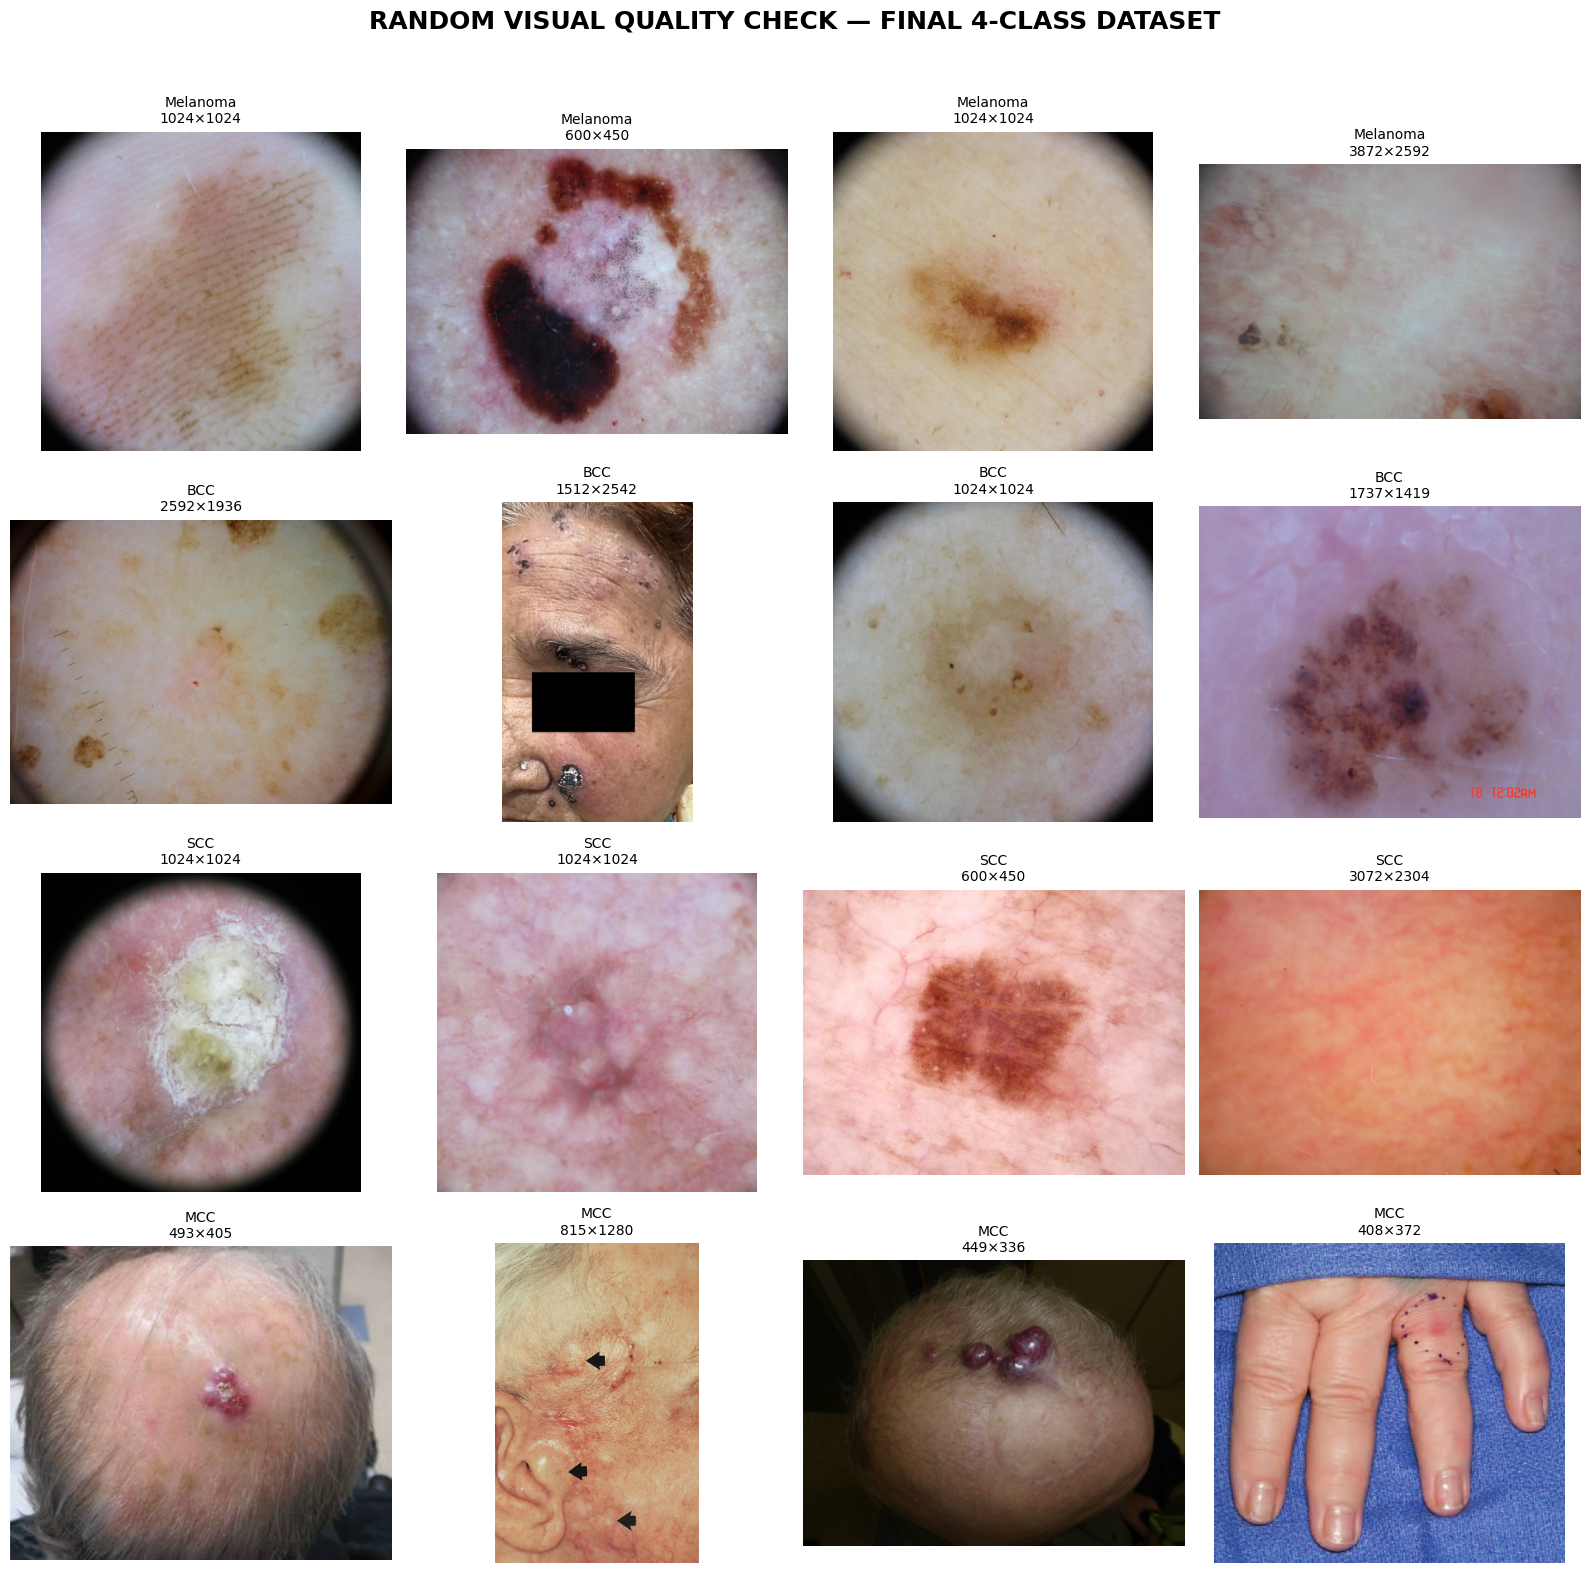


----------------------------------------------------------------------
VISUAL QUALITY CHECK COMPLETE
----------------------------------------------------------------------
Images displayed: 16
Samples per class: 4

Saved:
/kaggle/working/skin_cancer_project/results/step12e_random_visual_quality_check.png

STEP 12E COMPLETE


In [25]:
# ================================================================
# STEP 12E — RANDOM VISUAL QUALITY CHECK
# ================================================================

import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 70)
print("STEP 12E — RANDOM VISUAL QUALITY CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. Load FINAL dataset INCLUDING MCC
# ------------------------------------------------

FINAL_CLASSIFICATION_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset_with_mcc.csv"
)

visual_df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("Total images:", len(visual_df))

# ------------------------------------------------
# 2. Check required columns
# ------------------------------------------------

required_columns = [
    "image_path",
    "class_name",
    "label"
]

missing_columns = [
    col for col in required_columns
    if col not in visual_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ------------------------------------------------
# 3. Check class distribution
# ------------------------------------------------

print("\nClass distribution:")
print(
    visual_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

# ------------------------------------------------
# 4. Random sample from EACH class
# ------------------------------------------------

SAMPLES_PER_CLASS = 4

random.seed(SEED)

sample_rows = []

for class_name in CLASS_NAMES:

    class_df = visual_df[
        visual_df["class_name"] == class_name
    ]

    if len(class_df) == 0:
        print(
            f"WARNING: No images found for {class_name}"
        )
        continue

    n_samples = min(
        SAMPLES_PER_CLASS,
        len(class_df)
    )

    sampled = class_df.sample(
        n=n_samples,
        random_state=SEED
    )

    sample_rows.append(sampled)

visual_samples = pd.concat(
    sample_rows,
    ignore_index=True
)

print("\nRandom images selected:", len(visual_samples))

# ------------------------------------------------
# 5. Create 4 × 4 image grid
# ------------------------------------------------

fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 16)
)

axes = axes.flatten()

for i, (_, row) in enumerate(
    visual_samples.iterrows()
):

    ax = axes[i]

    image_path = row["image_path"]
    class_name = row["class_name"]

    # --------------------------------------------
    # Try opening image
    # --------------------------------------------

    try:

        img = Image.open(image_path)

        # Original resolution
        width, height = img.size

        ax.imshow(img)

        ax.set_title(
            f"{class_name}\n{width}×{height}",
            fontsize=10
        )

        ax.axis("off")

    except Exception as e:

        ax.text(
            0.5,
            0.5,
            f"IMAGE ERROR\n{class_name}\n{str(e)[:40]}",
            ha="center",
            va="center",
            fontsize=9
        )

        ax.axis("off")

# ------------------------------------------------
# 6. Hide unused subplot cells
# ------------------------------------------------

for j in range(
    len(visual_samples),
    len(axes)
):

    axes[j].axis("off")

# ------------------------------------------------
# 7. Main title
# ------------------------------------------------

fig.suptitle(
    "RANDOM VISUAL QUALITY CHECK — FINAL 4-CLASS DATASET",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# ------------------------------------------------
# 8. Save figure
# ------------------------------------------------

VISUAL_CHECK_PATH = os.path.join(
    RESULTS_DIR,
    "step12e_random_visual_quality_check.png"
)

plt.savefig(
    VISUAL_CHECK_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------
# 9. Final output
# ------------------------------------------------

print("\n" + "-" * 70)
print("VISUAL QUALITY CHECK COMPLETE")
print("-" * 70)

print("Images displayed:", len(visual_samples))
print("Samples per class:", SAMPLES_PER_CLASS)

print("\nSaved:")
print(VISUAL_CHECK_PATH)

print("\n" + "=" * 70)
print("STEP 12E COMPLETE")
print("=" * 70)

In [26]:
# STEP 13 — CREATE FRESH TRAIN / VALIDATION / TEST SPLIT
# CURRENT DATASET: 13,677 IMAGES / MCC = 29

from sklearn.model_selection import train_test_split
import pandas as pd
import os

print("=" * 70)
print("STEP 13 — FRESH TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

FINAL_CLASSIFICATION_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset_with_mcc.csv"
)

final_df = pd.read_csv(FINAL_CLASSIFICATION_CSV)

print("Total images:", len(final_df))

# ------------------------------------------------------------
# VERIFY CURRENT DATASET
# ------------------------------------------------------------

expected_counts = {
    "Melanoma": 7354,
    "BCC": 4917,
    "SCC": 1377,
    "MCC": 29
}

actual_counts = (
    final_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .to_dict()
)

print("\nCURRENT CLASS COUNTS")
for cls in CLASS_NAMES:
    print(f"{cls:10s}: {actual_counts.get(cls, 0)}")

assert len(final_df) == 13677, "Unexpected total dataset size"
assert actual_counts["MCC"] == 29, "Unexpected MCC count"

# ------------------------------------------------------------
# 70 / 15 / 15 STRATIFIED SPLIT
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    stratify=final_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV = os.path.join(DATA_DIR, "val.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SPLIT SIZES")
print("-" * 70)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\n" + "-" * 70)
print("TRAIN CLASS DISTRIBUTION")
print("-" * 70)
print(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\n" + "-" * 70)
print("VALIDATION CLASS DISTRIBUTION")
print("-" * 70)
print(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\n" + "-" * 70)
print("TEST CLASS DISTRIBUTION")
print("-" * 70)
print(
    test_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

total_after_split = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\n" + "-" * 70)
print("SPLIT VERIFICATION")
print("-" * 70)

print("Total after split :", total_after_split)
print("Original total    :", len(final_df))

assert total_after_split == len(final_df)

# Check no overlap by image_path
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print("Train/Val overlap :", len(train_paths & val_paths))
print("Train/Test overlap:", len(train_paths & test_paths))
print("Val/Test overlap  :", len(val_paths & test_paths))

assert len(train_paths & val_paths) == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths & test_paths) == 0

print("\nSaved:")
print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

print("\n" + "=" * 70)
print("STEP 13 COMPLETE — CURRENT DATASET SPLIT READY")
print("=" * 70)

STEP 13 — FRESH TRAIN / VALIDATION / TEST SPLIT
Total images: 13677

CURRENT CLASS COUNTS
Melanoma  : 7354
BCC       : 4917
SCC       : 1377
MCC       : 29

----------------------------------------------------------------------
SPLIT SIZES
----------------------------------------------------------------------
Train      : 9573
Validation : 2052
Test       : 2052

----------------------------------------------------------------------
TRAIN CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    5147
BCC         3442
SCC          964
MCC           20
Name: count, dtype: int64

----------------------------------------------------------------------
VALIDATION CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma    1103
BCC          738
SCC          206
MCC            5
Name: count, dtype: int64

----------------------------------------------------------------------
TEST CLASS D

In [28]:
# ============================================================
# STEP 13B — MCC LOSS AUDIT
# Find which unique MCC images are missing from final dataset
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 13B — MCC LOSS AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

MCC_MANIFEST = os.path.join(
    DATA_DIR,
    "unique_mcc_manifest.csv"
)

FINAL_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset_with_mcc.csv"
)

print("\nMCC manifest:")
print(MCC_MANIFEST)

print("\nFinal dataset:")
print(FINAL_CSV)

# ------------------------------------------------------------
# 2. Load files
# ------------------------------------------------------------

if not os.path.exists(MCC_MANIFEST):
    raise FileNotFoundError(
        f"MCC manifest not found:\n{MCC_MANIFEST}"
    )

if not os.path.exists(FINAL_CSV):
    raise FileNotFoundError(
        f"Final classification CSV not found:\n{FINAL_CSV}"
    )

mcc_manifest_df = pd.read_csv(
    MCC_MANIFEST
)

final_df_audit = pd.read_csv(
    FINAL_CSV
)

print("\nManifest rows :", len(mcc_manifest_df))
print("Final rows    :", len(final_df_audit))

# ------------------------------------------------------------
# 3. Inspect columns
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("MCC MANIFEST COLUMNS")
print("-" * 70)

print(
    mcc_manifest_df.columns.tolist()
)

print("\n" + "-" * 70)
print("FINAL DATASET COLUMNS")
print("-" * 70)

print(
    final_df_audit.columns.tolist()
)

# ------------------------------------------------------------
# 4. Find image-path column
# ------------------------------------------------------------

possible_path_columns = [
    "image_path",
    "path",
    "filepath",
    "file_path"
]

manifest_path_col = None
final_path_col = None

for col in possible_path_columns:

    if col in mcc_manifest_df.columns:
        manifest_path_col = col
        break

for col in possible_path_columns:

    if col in final_df_audit.columns:
        final_path_col = col
        break

if manifest_path_col is None:
    raise ValueError(
        "Could not find image path column in MCC manifest."
    )

if final_path_col is None:
    raise ValueError(
        "Could not find image path column in final dataset."
    )

print("\nManifest path column:",
      manifest_path_col)

print("Final path column   :",
      final_path_col)

# ------------------------------------------------------------
# 5. Normalize paths for comparison
# ------------------------------------------------------------

manifest_paths = (
    mcc_manifest_df[manifest_path_col]
    .astype(str)
    .map(lambda x: os.path.normpath(x))
)

final_paths = (
    final_df_audit[final_path_col]
    .astype(str)
    .map(lambda x: os.path.normpath(x))
)

# ------------------------------------------------------------
# 6. Identify missing MCC records
# ------------------------------------------------------------

final_path_set = set(
    final_paths
)

missing_mask = ~manifest_paths.isin(
    final_path_set
)

missing_mcc_df = mcc_manifest_df[
    missing_mask
].copy()

# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("MCC LOSS RESULT")
print("-" * 70)

print(
    "Unique MCC manifest:",
    len(mcc_manifest_df)
)

print(
    "MCC found in final :",
    len(mcc_manifest_df) -
    len(missing_mcc_df)
)

print(
    "MCC missing        :",
    len(missing_mcc_df)
)

# ------------------------------------------------------------
# 8. Print missing records
# ------------------------------------------------------------

if len(missing_mcc_df) > 0:

    print("\n" + "-" * 70)
    print("MISSING MCC RECORDS")
    print("-" * 70)

    for i, row in missing_mcc_df.iterrows():

        print(
            f"{i}: "
            f"{row[manifest_path_col]}"
        )

else:

    print(
        "\n✅ No MCC records missing by exact path."
    )

# ------------------------------------------------------------
# 9. Save audit
# ------------------------------------------------------------

MISSING_MCC_AUDIT = os.path.join(
    DATA_DIR,
    "missing_mcc_from_final_dataset.csv"
)

missing_mcc_df.to_csv(
    MISSING_MCC_AUDIT,
    index=False
)

print("\nAudit saved:")
print(MISSING_MCC_AUDIT)

# ------------------------------------------------------------
# 10. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)

if len(missing_mcc_df) == 25:

    print(
        "✅ EXACTLY 25 MCC RECORDS ARE MISSING."
    )

    print(
        "This explains 54 → 29 MCC reduction."
    )

elif len(missing_mcc_df) > 0:

    print(
        "⚠️ MCC records are missing, but count is not 25."
    )

else:

    print(
        "⚠️ No exact path mismatch found."
    )

print("=" * 70)

STEP 13B — MCC LOSS AUDIT

MCC manifest:
/kaggle/working/skin_cancer_project/data/unique_mcc_manifest.csv

Final dataset:
/kaggle/working/skin_cancer_project/data/final_4class_classification_dataset_with_mcc.csv

Manifest rows : 29
Final rows    : 13677

----------------------------------------------------------------------
MCC MANIFEST COLUMNS
----------------------------------------------------------------------
['image_name', 'image_path', 'class_name', 'label', 'source_path', 'sha256']

----------------------------------------------------------------------
FINAL DATASET COLUMNS
----------------------------------------------------------------------
['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

Manifest path column: image_path
Final path column   : image_path

----------------------------------------------------------------------
MCC LOSS RESULT
----------------------------------------------------------------------
Unique MCC manifest: 29
MCC found in 

In [29]:
# ============================================================
# STEP 13C — DIRECT MCC SOURCE RE-AUDIT
# DO NOT USE unique_mcc_manifest.csv
# ============================================================

import os
import hashlib
import pandas as pd

print("=" * 70)
print("STEP 13C — DIRECT MCC SOURCE RE-AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. MCC source directories
# ------------------------------------------------------------

MCC_SOURCE_DIRS = [
    "/kaggle/input/datasets/quantumcoders07/datasetmcc",
    "/kaggle/input/datasets/quantumcoders07/datasetmcc/mcc image",

    "/kaggle/input/datasets/quantumcoders07/mcc-1-dataset",
    "/kaggle/input/datasets/quantumcoders07/mcc-1-dataset/New folder",

    "/kaggle/input/datasets/quantumcoders07/mcc-2-datatset",
    "/kaggle/input/datasets/quantumcoders07/mcc-2-datatset/MCC-2",

    "/kaggle/input/datasets/quantumcoders07/mcc-3-datatset",
    "/kaggle/input/datasets/quantumcoders07/mcc-3-datatset/MCC-3",
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff"
}

# ------------------------------------------------------------
# 2. SHA-256 helper
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ------------------------------------------------------------
# 3. Scan source folders
# ------------------------------------------------------------

records = []

print("\nScanning MCC source directories...")

for source_dir in MCC_SOURCE_DIRS:

    if not os.path.exists(source_dir):

        print(
            "\n⚠️ NOT FOUND:",
            source_dir
        )

        continue

    source_count = 0

    for root, dirs, files in os.walk(source_dir):

        for filename in files:

            ext = os.path.splitext(
                filename
            )[1].lower()

            if ext not in IMAGE_EXTENSIONS:
                continue

            full_path = os.path.join(
                root,
                filename
            )

            try:

                file_hash = sha256_file(
                    full_path
                )

                records.append({
                    "image_name": filename,
                    "image_path": full_path,
                    "source_path": source_dir,
                    "sha256": file_hash
                })

                source_count += 1

            except Exception as e:

                print(
                    "\n⚠️ Could not hash:",
                    full_path
                )

                print(
                    "Error:",
                    e
                )

    print(
        f"{source_dir} -> "
        f"{source_count} image files"
    )

# ------------------------------------------------------------
# 4. Raw source count
# ------------------------------------------------------------

source_df = pd.DataFrame(records)

print("\n" + "-" * 70)
print("RAW MCC SOURCE AUDIT")
print("-" * 70)

print(
    "Raw image records:",
    len(source_df)
)

# ------------------------------------------------------------
# 5. Exact duplicate groups using SHA-256
# ------------------------------------------------------------

duplicate_groups = (
    source_df[
        source_df["sha256"].duplicated(
            keep=False
        )
    ]
    .sort_values("sha256")
)

duplicate_group_count = (
    duplicate_groups["sha256"]
    .nunique()
)

duplicate_record_count = (
    len(duplicate_groups)
)

unique_source_count = (
    source_df["sha256"]
    .nunique()
)

print(
    "Unique SHA-256 images:",
    unique_source_count
)

print(
    "Duplicate groups:",
    duplicate_group_count
)

print(
    "Records involved in duplicates:",
    duplicate_record_count
)

# ------------------------------------------------------------
# 6. Print duplicate groups
# ------------------------------------------------------------

if duplicate_group_count > 0:

    print("\n" + "-" * 70)
    print("DUPLICATE GROUPS")
    print("-" * 70)

    for sha, group in duplicate_groups.groupby(
        "sha256"
    ):

        print(
            f"\nSHA256: {sha}"
        )

        for path in group["image_path"].tolist():

            print(
                "  ",
                path
            )

# ------------------------------------------------------------
# 7. Compare against FINAL CSV
# ------------------------------------------------------------

FINAL_CSV = os.path.join(
    DATA_DIR,
    "final_4class_classification_dataset_with_mcc.csv"
)

final_df_13c = pd.read_csv(
    FINAL_CSV
)

final_mcc_df = final_df_13c[
    final_df_13c["label"] == 3
].copy()

print("\n" + "-" * 70)
print("FINAL DATASET MCC CHECK")
print("-" * 70)

print(
    "MCC in final CSV:",
    len(final_mcc_df)
)

# ------------------------------------------------------------
# 8. Compare source hashes against final paths
# ------------------------------------------------------------

final_path_set = set(
    final_mcc_df["image_path"]
    .astype(str)
    .map(os.path.normpath)
)

source_path_set = set(
    source_df["image_path"]
    .astype(str)
    .map(os.path.normpath)
)

source_paths_in_final = (
    source_path_set.intersection(
        final_path_set
    )
)

source_paths_missing_from_final = (
    source_path_set - final_path_set
)

print(
    "Source paths found in final:",
    len(source_paths_in_final)
)

print(
    "Source paths absent from final:",
    len(source_paths_missing_from_final)
)

# ------------------------------------------------------------
# 9. Save complete direct audit
# ------------------------------------------------------------

DIRECT_MCC_AUDIT = os.path.join(
    DATA_DIR,
    "mcc_direct_source_audit.csv"
)

source_df.to_csv(
    DIRECT_MCC_AUDIT,
    index=False
)

print(
    "\nDirect source audit saved:"
)

print(
    DIRECT_MCC_AUDIT
)

# ------------------------------------------------------------
# 10. Final interpretation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 13C RESULT")
print("=" * 70)

if unique_source_count == 54:

    print(
        "✅ ORIGINAL MCC SOURCE SET = 54 UNIQUE IMAGES"
    )

    if len(final_mcc_df) == 29:

        print(
            "⚠️ FINAL DATASET HAS ONLY 29 MCC"
        )

        print(
            "➡️ 25 MCC records were lost during "
            "dataset construction."
        )

elif unique_source_count == 29:

    print(
        "⚠️ CURRENT MCC SOURCE DIRECTORIES "
        "CONTAIN ONLY 29 UNIQUE IMAGES."
    )

    print(
        "The earlier 54-count audit cannot be reproduced "
        "from the currently accessible source files."
    )

else:

    print(
        f"⚠️ CURRENT DIRECT SOURCE UNIQUE COUNT = "
        f"{unique_source_count}"
    )

    print(
        "This differs from both 29 and the earlier 54."
    )

print("=" * 70)

STEP 13C — DIRECT MCC SOURCE RE-AUDIT

Scanning MCC source directories...
/kaggle/input/datasets/quantumcoders07/datasetmcc -> 17 image files
/kaggle/input/datasets/quantumcoders07/datasetmcc/mcc image -> 17 image files
/kaggle/input/datasets/quantumcoders07/mcc-1-dataset -> 12 image files
/kaggle/input/datasets/quantumcoders07/mcc-1-dataset/New folder -> 12 image files

⚠️ NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-2-datatset

⚠️ NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-2-datatset/MCC-2

⚠️ NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-3-datatset

⚠️ NOT FOUND: /kaggle/input/datasets/quantumcoders07/mcc-3-datatset/MCC-3

----------------------------------------------------------------------
RAW MCC SOURCE AUDIT
----------------------------------------------------------------------
Raw image records: 58
Unique SHA-256 images: 29
Duplicate groups: 29
Records involved in duplicates: 58

----------------------------------------------------------------------

In [30]:
# ============================================================
# STEP 14 — IMAGE DATASET + DATALOADERS
# ULTRA RAM-SAFE + RAM DIAGNOSTIC VERSION
# ============================================================

import os
import gc
import torch
import psutil

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


print("=" * 70)
print("STEP 14 — IMAGE DATASET + DATALOADERS")
print("ULTRA RAM-SAFE VERSION")
print("=" * 70)


# ============================================================
# 1. RAM MONITOR
# ============================================================

process = psutil.Process(os.getpid())


def show_ram(label):

    process_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system_ram = (
        psutil.virtual_memory().used
        / (1024 ** 3)
    )

    system_total = (
        psutil.virtual_memory().total
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python process = {process_ram:.2f} GB | "
        f"System = {system_ram:.2f} / "
        f"{system_total:.2f} GB"
    )


show_ram("STEP 14 START")


# ============================================================
# 2. SETTINGS
# ============================================================

IMAGE_SIZE = 224

# IMPORTANT:
# Keep this small because CPU RAM is our bottleneck.
BATCH_SIZE = 8

NUM_WORKERS = 0

PIN_MEMORY = False

PERSISTENT_WORKERS = False


print("\nConfiguration:")
print("Image size :", IMAGE_SIZE)
print("Batch size :", BATCH_SIZE)
print("Workers    :", NUM_WORKERS)
print("Pin memory :", PIN_MEMORY)


# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 4. DATASET
# ============================================================

class SkinCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        # Only dataframe metadata is stored.
        # Images are NOT loaded here.

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = row[
            "image_path"
        ]

        label = int(
            row["label"]
        )

        # Image is loaded ONLY when
        # this sample is requested.

        with Image.open(
            image_path
        ) as img:

            image = img.convert(
                "RGB"
            )

            if self.transform is not None:

                image = self.transform(
                    image
                )

        return image, label


# ============================================================
# 5. CREATE DATASETS
# ============================================================

print("\nCreating datasets...")

train_dataset = SkinCancerDataset(
    train_df,
    transform=train_transform
)

val_dataset = SkinCancerDataset(
    val_df,
    transform=eval_transform
)

test_dataset = SkinCancerDataset(
    test_df,
    transform=eval_transform
)


show_ram(
    "After dataset creation"
)


# ============================================================
# 6. CREATE DATALOADERS
# ============================================================

print(
    "\nCreating DataLoaders..."
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False,
    drop_last=False
)


show_ram(
    "After DataLoader creation"
)


# ============================================================
# 7. DATASET SIZES
# ============================================================

print("\nDataset sizes:")

print(
    "Train      :",
    len(train_dataset)
)

print(
    "Validation :",
    len(val_dataset)
)

print(
    "Test       :",
    len(test_dataset)
)


# ============================================================
# 8. VERIFY ONLY ONE BATCH
# ============================================================

print(
    "\nLoading ONE test batch..."
)

show_ram(
    "Before first batch"
)


images, labels = next(
    iter(train_loader)
)


print(
    "\nBatch image shape :",
    tuple(images.shape)
)

print(
    "Batch label shape:",
    tuple(labels.shape)
)

print(
    "First 10 labels   :",
    labels[:10].tolist()
)


show_ram(
    "After first batch"
)


# ============================================================
# 9. SANITY CHECKS
# ============================================================

assert images.ndim == 4

assert images.shape[1] == 3

assert images.shape[2] == IMAGE_SIZE

assert images.shape[3] == IMAGE_SIZE

assert labels.ndim == 1

assert len(images) == len(labels)


print(
    "\nSanity check: PASSED"
)


# ============================================================
# 10. DELETE TEST BATCH
# ============================================================

del images
del labels

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


show_ram(
    "After deleting test batch"
)


# ============================================================
# 11. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

print(
    "STEP 14 COMPLETE"
)

print("=" * 70)

print(
    "\nFinal settings:"
)

print(
    "Batch size       :",
    BATCH_SIZE
)

print(
    "Num workers      :",
    NUM_WORKERS
)

print(
    "Pin memory       :",
    PIN_MEMORY
)

print(
    "Persistent       : False"
)

print(
    "Image size       :",
    IMAGE_SIZE
)

show_ram(
    "STEP 14 FINAL"
)

print(
    "\nREADY FOR STEP 15"
)

print("=" * 70)

STEP 14 — IMAGE DATASET + DATALOADERS
ULTRA RAM-SAFE VERSION
[RAM] STEP 14 START: Python process = 1.47 GB | System = 2.03 / 31.35 GB

Configuration:
Image size : 224
Batch size : 8
Workers    : 0
Pin memory : False

Creating datasets...
[RAM] After dataset creation: Python process = 1.47 GB | System = 2.03 / 31.35 GB

Creating DataLoaders...
[RAM] After DataLoader creation: Python process = 1.47 GB | System = 2.03 / 31.35 GB

Dataset sizes:
Train      : 9573
Validation : 2052
Test       : 2052

Loading ONE test batch...
[RAM] Before first batch: Python process = 1.47 GB | System = 2.03 / 31.35 GB

Batch image shape : (8, 3, 224, 224)
Batch label shape: (8,)
First 10 labels   : [0, 0, 2, 2, 1, 1, 1, 1]
[RAM] After first batch: Python process = 1.46 GB | System = 2.18 / 31.35 GB

Sanity check: PASSED
[RAM] After deleting test batch: Python process = 1.46 GB | System = 2.18 / 31.35 GB

STEP 14 COMPLETE

Final settings:
Batch size       : 8
Num workers      : 0
Pin memory       : False
Pe

In [31]:
# ============================================================
# STEP 15 — EFFICIENTNET-B0 MODEL
# RAM-SAFE / FRESH CURRENT DATASET
# ============================================================

import gc
import os
import psutil
import torch
import torch.nn as nn
from torchvision import models


print("=" * 70)
print("STEP 15 — EFFICIENTNET-B0 MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. RAM monitor
# ------------------------------------------------------------

process = psutil.Process(os.getpid())


def show_ram(label):

    process_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system = psutil.virtual_memory()

    system_used = (
        system.used
        / (1024 ** 3)
    )

    system_total = (
        system.total
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python = {process_ram:.2f} GB | "
        f"System = {system_used:.2f} / "
        f"{system_total:.2f} GB"
    )


show_ram("Before model")


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)


if torch.cuda.is_available():

    print(
        "GPU count:",
        torch.cuda.device_count()
    )

    for i in range(
        torch.cuda.device_count()
    ):

        print(
            f"GPU {i}:",
            torch.cuda.get_device_name(i)
        )


# ------------------------------------------------------------
# 3. Clear old model if any
# ------------------------------------------------------------

for name in [
    "model",
    "optimizer",
    "scheduler",
    "scaler"
]:

    if name in globals():

        try:
            del globals()[name]
        except:
            pass


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 4. Create EfficientNet-B0
# ------------------------------------------------------------

print(
    "\nCreating EfficientNet-B0..."
)

model = models.efficientnet_b0(
    weights=None
)


# ------------------------------------------------------------
# 5. Replace classifier
# ------------------------------------------------------------

NUM_CLASSES = 4

in_features = (
    model.classifier[1].in_features
)

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)


# ------------------------------------------------------------
# 6. Move model to GPU
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# 7. DataParallel
# ------------------------------------------------------------

if torch.cuda.device_count() > 1:

    model = nn.DataParallel(
        model
    )

    print(
        "\nDataParallel: ENABLED"
    )

else:

    print(
        "\nDataParallel: DISABLED"
    )


# ------------------------------------------------------------
# 8. Parameter count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\nModel:")
print("EfficientNet-B0")

print(
    "Weights:",
    "None / From scratch"
)

print(
    "Classes:",
    NUM_CLASSES
)

print(
    "Input:",
    "224 x 224"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)


# ------------------------------------------------------------
# 9. GPU memory
# ------------------------------------------------------------

if torch.cuda.is_available():

    print("\nGPU memory:")

    for i in range(
        torch.cuda.device_count()
    ):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024 ** 2)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024 ** 2)
        )

        print(
            f"GPU {i}: "
            f"allocated={allocated:.1f} MB | "
            f"reserved={reserved:.1f} MB"
        )


# ------------------------------------------------------------
# 10. RAM after model
# ------------------------------------------------------------

show_ram(
    "After model creation"
)


# ------------------------------------------------------------
# 11. Final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 15 COMPLETE")
print("=" * 70)

print(
    "EfficientNet-B0 ready."
)

print(
    "Ready for STEP 16."
)

print("=" * 70)

STEP 15 — EFFICIENTNET-B0 MODEL
[RAM] Before model: Python = 1.46 GB | System = 2.02 / 31.35 GB

Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Creating EfficientNet-B0...

DataParallel: ENABLED

Model:
EfficientNet-B0
Weights: None / From scratch
Classes: 4
Input: 224 x 224
Total parameters: 4,012,672
Trainable parameters: 4,012,672

GPU memory:
GPU 0: allocated=31.1 MB | reserved=46.0 MB
GPU 1: allocated=0.0 MB | reserved=0.0 MB
[RAM] After model creation: Python = 1.46 GB | System = 2.02 / 31.35 GB

STEP 15 COMPLETE
EfficientNet-B0 ready.
Ready for STEP 16.


In [32]:
# ============================================================
# STEP 16 — LOSS + CLASS WEIGHTS + OPTIMIZER
# RAM-SAFE VERSION
# ============================================================

import gc
import os
import psutil
import torch
import torch.nn as nn
import torch.optim as optim


print("=" * 70)
print("STEP 16 — LOSS + OPTIMIZER")
print("=" * 70)


# ============================================================
# 1. RAM MONITOR
# ============================================================

process = psutil.Process(os.getpid())


def show_ram(label):

    process_ram = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    system = psutil.virtual_memory()

    system_used = (
        system.used
        / (1024 ** 3)
    )

    system_total = (
        system.total
        / (1024 ** 3)
    )

    print(
        f"[RAM] {label}: "
        f"Python = {process_ram:.2f} GB | "
        f"System = {system_used:.2f} / "
        f"{system_total:.2f} GB"
    )


show_ram("STEP 16 START")


# ============================================================
# 2. CLASS INFORMATION
# ============================================================

class_names = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = 4


# Current TRAIN counts
class_counts = torch.tensor(
    [
        5147,   # Melanoma
        3442,   # BCC
        964,    # SCC
        20      # MCC
    ],
    dtype=torch.float32
)


print("\nClass counts:")

for name, count in zip(
    class_names,
    class_counts
):

    print(
        f"{name:10s}: {int(count.item())}"
    )


# ============================================================
# 3. INVERSE-SQRT CLASS WEIGHTS
# ============================================================

class_weights = (
    1.0 /
    torch.sqrt(class_counts)
)

class_weights = (
    class_weights /
    class_weights.mean()
)


print("\nClass weights:")

for name, weight in zip(
    class_names,
    class_weights
):

    print(
        f"{name:10s}: "
        f"{weight.item():.4f}"
    )


# Move weights to GPU
class_weights = class_weights.to(
    device
)


# ============================================================
# 4. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


print("\nLoss:")
print(
    "CrossEntropyLoss"
)

print(
    "Label smoothing : 0.05"
)

print(
    "Class weighting : inverse sqrt"
)


# ============================================================
# 5. OPTIMIZER
# ============================================================

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 5e-4


optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


print("\nOptimizer:")
print("AdamW")
print(
    "Learning rate :",
    LEARNING_RATE
)

print(
    "Weight decay  :",
    WEIGHT_DECAY
)


# ============================================================
# 6. LR SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)


print("\nScheduler:")
print("ReduceLROnPlateau")
print("Factor   : 0.5")
print("Patience : 1")


# ============================================================
# 7. AMP SCALER
# ============================================================

USE_AMP = torch.cuda.is_available()


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)


print("\nAMP:")
print(
    "Enabled:",
    USE_AMP
)


# ============================================================
# 8. MEMORY CHECK
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


show_ram(
    "STEP 16 AFTER SETUP"
)


# ============================================================
# 9. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    print("\nGPU memory:")

    for i in range(
        torch.cuda.device_count()
    ):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024 ** 2)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024 ** 2)
        )

        print(
            f"GPU {i}: "
            f"allocated={allocated:.1f} MB | "
            f"reserved={reserved:.1f} MB"
        )


# ============================================================
# 10. FINAL
# ============================================================

print("\n" + "=" * 70)
print("STEP 16 COMPLETE")
print("=" * 70)

print(
    "Loss function ready."
)

print(
    "Optimizer ready."
)

print(
    "Scheduler ready."
)

print(
    "AMP scaler ready."
)

print(
    "\nNO TRAINING HAS STARTED YET."
)

print(
    "Ready for STEP 17."
)

print("=" * 70)

STEP 16 — LOSS + OPTIMIZER
[RAM] STEP 16 START: Python = 1.46 GB | System = 2.01 / 31.35 GB

Class counts:
Melanoma  : 5147
BCC       : 3442
SCC       : 964
MCC       : 20

Class weights:
Melanoma  : 0.1944
BCC       : 0.2377
SCC       : 0.4492
MCC       : 3.1187

Loss:
CrossEntropyLoss
Label smoothing : 0.05
Class weighting : inverse sqrt

Optimizer:
AdamW
Learning rate : 5e-05
Weight decay  : 0.0005

Scheduler:
ReduceLROnPlateau
Factor   : 0.5
Patience : 1

AMP:
Enabled: True
[RAM] STEP 16 AFTER SETUP: Python = 1.46 GB | System = 2.01 / 31.35 GB

GPU memory:
GPU 0: allocated=31.1 MB | reserved=46.0 MB
GPU 1: allocated=0.0 MB | reserved=0.0 MB

STEP 16 COMPLETE
Loss function ready.
Optimizer ready.
Scheduler ready.
AMP scaler ready.

NO TRAINING HAS STARTED YET.
Ready for STEP 17.


In [34]:
# ================================================================
# STEP 17 v2
# RAM-SAFE SINGLE GPU TRAINING
# Batch 4 + Grad Accumulation 8
# Effective Batch = 32
# Safe Resume + RAM Guard
# ================================================================

import os
import gc
import time
import copy
import ctypes
import psutil
import torch

print("=" * 72)
print("STEP 17 v2 — RAM-SAFE SINGLE-GPU TRAINING")
print("=" * 72)


# ================================================================
# 1. CONFIG
# ================================================================

NUM_EPOCHS = 10

BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 8
EFFECTIVE_BATCH_SIZE = (
    BATCH_SIZE * GRAD_ACCUM_STEPS
)

NUM_WORKERS = 0
PIN_MEMORY = False
PERSISTENT_WORKERS = False

INPUT_SIZE = 224
NUM_CLASSES = 4

RAM_WARNING_PERCENT = 70.0
RAM_STOP_PERCENT = 85.0

CHECKPOINT_EVERY_BATCHES = 200

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

CHECKPOINT_DIR = (
    "/kaggle/working/"
    "skin_cancer_project/checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_best.pth"
)

LATEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_latest.pth"
)

RESUME_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_batch_resume.pth"
)


# ================================================================
# 2. RAM MONITOR
# ================================================================

def ram_info(label):

    process = psutil.Process(
        os.getpid()
    )

    rss_gb = (
        process.memory_info().rss
        / (1024 ** 3)
    )

    vm = psutil.virtual_memory()

    used_gb = (
        vm.used
        / (1024 ** 3)
    )

    available_gb = (
        vm.available
        / (1024 ** 3)
    )

    total_gb = (
        vm.total
        / (1024 ** 3)
    )

    percent = vm.percent

    print(
        f"[RAM] {label} | "
        f"Python={rss_gb:.2f} GB | "
        f"System={used_gb:.2f}/{total_gb:.2f} GB | "
        f"Available={available_gb:.2f} GB | "
        f"Usage={percent:.1f}%"
    )

    return percent


def gpu_info(label):

    if not torch.cuda.is_available():
        print(
            f"[GPU] {label}: CUDA unavailable"
        )
        return

    print(f"[GPU] {label}")

    for i in range(
        torch.cuda.device_count()
    ):

        allocated = (
            torch.cuda.memory_allocated(i)
            / (1024 ** 2)
        )

        reserved = (
            torch.cuda.memory_reserved(i)
            / (1024 ** 2)
        )

        print(
            f"GPU {i}: "
            f"allocated={allocated:.1f} MB | "
            f"reserved={reserved:.1f} MB"
        )


# ================================================================
# 3. RETURN MEMORY TO OS WHEN POSSIBLE
# ================================================================

def release_cpu_memory():

    gc.collect()

    # Linux glibc memory trimming
    try:

        libc = ctypes.CDLL(
            "libc.so.6"
        )

        libc.malloc_trim(0)

    except Exception:
        pass

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


# ================================================================
# 4. DEVICE — SINGLE GPU ONLY
# ================================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required."
    )

DEVICE = torch.device(
    "cuda:0"
)

torch.cuda.set_device(0)

print(
    "\nUsing SINGLE GPU:"
)

print(
    torch.cuda.get_device_name(0)
)


# ================================================================
# 5. CHECK REQUIRED OBJECTS
# ================================================================

required = [
    "model",
    "optimizer",
    "scheduler",
    "scaler",
    "train_loader",
    "val_loader"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:

    raise RuntimeError(
        "Missing objects: "
        + ", ".join(missing)
        + "\nRun STEP 14, 15 and 16 first."
    )


# ================================================================
# 6. LOSS FUNCTION
# ================================================================

if "criterion" in globals():

    loss_fn = criterion

elif "loss_fn" in globals():

    loss_fn = loss_fn

else:

    raise RuntimeError(
        "Loss function not found."
    )


# ================================================================
# 7. REMOVE DATA PARALLEL
# ================================================================

print("\nChecking model...")

if isinstance(
    model,
    torch.nn.DataParallel
):

    print(
        "DataParallel detected."
    )

    print(
        "Removing DataParallel "
        "for RAM-safe single-GPU training."
    )

    model = model.module

else:

    print(
        "Model is already single-GPU."
    )


model = model.to(
    DEVICE
)


# ================================================================
# 8. REBUILD SMALLER DATALOADERS
# ================================================================

from torch.utils.data import DataLoader


train_dataset = train_loader.dataset
val_dataset = val_loader.dataset


print("\nRebuilding DataLoaders...")

del train_loader
del val_loader

release_cpu_memory()


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)


# ================================================================
# 9. IMPORTANT — RESET GRADIENTS
# ================================================================

optimizer.zero_grad(
    set_to_none=True
)

release_cpu_memory()

ram_info(
    "STEP 17 v2 BEFORE TRAINING"
)

gpu_info(
    "BEFORE TRAINING"
)


# ================================================================
# 10. CHECKPOINT CONFIG
# ================================================================

TRAIN_SIZE = len(
    train_loader.dataset
)

VAL_SIZE = len(
    val_loader.dataset
)


CURRENT_CONFIG = {

    "model_name":
        "EfficientNet-B0",

    "training_type":
        "from_scratch",

    "num_classes":
        NUM_CLASSES,

    "input_size":
        INPUT_SIZE,

    "batch_size":
        BATCH_SIZE,

    "grad_accum_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH_SIZE,

    "train_size":
        TRAIN_SIZE,

    "val_size":
        VAL_SIZE,

    "class_names":
        CLASS_NAMES,

    "num_workers":
        NUM_WORKERS,

    "pin_memory":
        PIN_MEMORY,

    "single_gpu":
        True
}


# ================================================================
# 11. ATOMIC CHECKPOINT SAVE
# ================================================================

def atomic_save(
    obj,
    path
):

    temp_path = (
        path + ".tmp"
    )

    torch.save(
        obj,
        temp_path
    )

    os.replace(
        temp_path,
        path
    )


# ================================================================
# 12. MODEL STATE
# ================================================================

def model_state():

    return model.state_dict()


# ================================================================
# 13. CHECKPOINT COMPATIBILITY
# ================================================================

def checkpoint_valid(
    checkpoint
):

    if not isinstance(
        checkpoint,
        dict
    ):
        return False

    cfg = checkpoint.get(
        "config",
        {}
    )

    keys = [
        "model_name",
        "training_type",
        "num_classes",
        "input_size",
        "batch_size",
        "grad_accum_steps",
        "train_size",
        "val_size",
        "class_names",
        "single_gpu"
    ]

    for key in keys:

        if (
            cfg.get(key)
            != CURRENT_CONFIG.get(key)
        ):

            print(
                f"Mismatch: {key}"
            )

            print(
                "Checkpoint:",
                cfg.get(key)
            )

            print(
                "Current:",
                CURRENT_CONFIG.get(key)
            )

            return False

    return True


# ================================================================
# 14. TRAINING STATE
# ================================================================

start_epoch = 0
start_batch = 0

best_val_loss = float(
    "inf"
)

history = {

    "train_loss": [],

    "val_loss": [],

    "learning_rate": []
}


# ================================================================
# 15. LOAD RESUME CHECKPOINT
# ================================================================

if os.path.exists(
    RESUME_PATH
):

    print("\n")
    print(
        "=" * 72
    )

    print(
        "RESUME CHECKPOINT FOUND"
    )

    print(
        "=" * 72
    )

    try:

        checkpoint = torch.load(
            RESUME_PATH,
            map_location="cpu"
        )

        if checkpoint_valid(
            checkpoint
        ):

            print(
                "Checkpoint configuration OK."
            )

            model.load_state_dict(
                checkpoint[
                    "model_state_dict"
                ]
            )

            optimizer.load_state_dict(
                checkpoint[
                    "optimizer_state_dict"
                ]
            )

            if (
                "scheduler_state_dict"
                in checkpoint
            ):

                scheduler.load_state_dict(
                    checkpoint[
                        "scheduler_state_dict"
                    ]
                )

            if (
                "scaler_state_dict"
                in checkpoint
            ):

                scaler.load_state_dict(
                    checkpoint[
                        "scaler_state_dict"
                    ]
                )

            start_epoch = int(
                checkpoint.get(
                    "epoch",
                    0
                )
            )

            start_batch = int(
                checkpoint.get(
                    "next_batch",
                    0
                )
            )

            best_val_loss = float(
                checkpoint.get(
                    "best_val_loss",
                    float("inf")
                )
            )

            history = checkpoint.get(
                "history",
                history
            )

            print(
                "\nResume successful."
            )

            print(
                "Epoch:",
                start_epoch + 1
            )

            print(
                "Next batch:",
                start_batch
            )

            print(
                "Best val loss:",
                best_val_loss
            )

        else:

            print(
                "Existing checkpoint "
                "does not match current setup."
            )

            print(
                "Starting fresh."
            )

    except Exception as e:

        print(
            "Resume failed:"
        )

        print(
            repr(e)
        )

        print(
            "Starting fresh."
        )

else:

    print(
        "\nNo compatible resume checkpoint."
    )

    print(
        "Starting fresh training."
    )


# ================================================================
# 16. NEVER LOAD OLD RECOVERY
# ================================================================

OLD_RECOVERY = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_epoch1_recovery.pth"
)

if os.path.exists(
    OLD_RECOVERY
):

    print(
        "\nOld recovery checkpoint exists."
    )

    print(
        "It will NOT be loaded:"
    )

    print(
        OLD_RECOVERY
    )


# ================================================================
# 17. TRAINING
# ================================================================

print("\n")
print("=" * 72)
print(
    "TRAINING STARTING"
)
print("=" * 72)

ram_info(
    "RIGHT BEFORE TRAINING"
)

gpu_info(
    "RIGHT BEFORE TRAINING"
)


global_start = time.time()

training_interrupted = False


for epoch in range(
    start_epoch,
    NUM_EPOCHS
):

    print("\n")
    print(
        "=" * 72
    )

    print(
        f"EPOCH {epoch + 1}/{NUM_EPOCHS}"
    )

    print(
        "=" * 72
    )

    epoch_start = time.time()

    model.train()

    running_loss = 0.0
    samples_seen = 0

    optimizer.zero_grad(
        set_to_none=True
    )

    total_batches = len(
        train_loader
    )

    batch_start = (
        start_batch
        if epoch == start_epoch
        else 0
    )

    for batch_idx, batch in enumerate(
        train_loader
    ):

        # ------------------------------------------------
        # RESUME
        # ------------------------------------------------

        if batch_idx < batch_start:

            continue


        images, targets = batch


        # ------------------------------------------------
        # MOVE BATCH
        # ------------------------------------------------

        images = images.to(
            DEVICE
        )

        targets = targets.to(
            DEVICE
        )


        # ------------------------------------------------
        # FORWARD
        # ------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=True
        ):

            outputs = model(
                images
            )

            loss = loss_fn(
                outputs,
                targets
            )

            scaled_loss = (
                loss
                / GRAD_ACCUM_STEPS
            )


        # ------------------------------------------------
        # BACKWARD
        # ------------------------------------------------

        scaler.scale(
            scaled_loss
        ).backward()


        # ------------------------------------------------
        # METRICS
        # ------------------------------------------------

        bs = images.size(0)

        running_loss += (
            loss.detach().item()
            * bs
        )

        samples_seen += bs


        # ------------------------------------------------
        # OPTIMIZER STEP
        # ------------------------------------------------

        accumulation_done = (

            (
                (batch_idx + 1)
                % GRAD_ACCUM_STEPS
            == 0
            )

            or

            (
                (batch_idx + 1)
                == total_batches
            )
        )


        if accumulation_done:

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )


        # ------------------------------------------------
        # DELETE CURRENT BATCH
        # ------------------------------------------------

        del images
        del targets
        del outputs
        del loss
        del scaled_loss
        del batch


        # ------------------------------------------------
        # CHECKPOINT
        # ------------------------------------------------

        completed_batches = (
            batch_idx + 1
        )


        if (

            completed_batches
            % CHECKPOINT_EVERY_BATCHES
            == 0

            and

            accumulation_done

        ):

            checkpoint = {

                "epoch":
                    epoch,

                "batch_idx":
                    batch_idx,

                "next_batch":
                    batch_idx + 1,

                "model_state_dict":
                    model_state(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "scaler_state_dict":
                    scaler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "history":
                    history,

                "config":
                    CURRENT_CONFIG,

                "checkpoint_type":
                    "batch_resume",

                "timestamp":
                    time.time()
            }


            atomic_save(
                checkpoint,
                RESUME_PATH
            )


            del checkpoint

            release_cpu_memory()


            print(
                "\n"
                f"Checkpoint saved "
                f"at batch "
                f"{completed_batches}"
            )

            ram_percent = ram_info(
                f"AFTER BATCH "
                f"{completed_batches}"
            )

            gpu_info(
                f"AFTER BATCH "
                f"{completed_batches}"
            )


            # ------------------------------------------------
            # RAM GUARD
            # ------------------------------------------------

            if (
                ram_percent
                >= RAM_WARNING_PERCENT
            ):

                print(
                    "\n"
                    "!!! RAM WARNING !!!"
                )

                print(
                    f"RAM usage: "
                    f"{ram_percent:.1f}%"
                )


            if (
                ram_percent
                >= RAM_STOP_PERCENT
            ):

                print(
                    "\n"
                    "!!! RAM STOP GUARD !!!"
                )

                print(
                    f"RAM reached "
                    f"{ram_percent:.1f}%"
                )

                print(
                    "Latest checkpoint "
                    "has been saved."
                )

                print(
                    "Stopping training safely."
                )

                training_interrupted = True

                break


        # ------------------------------------------------
        # PROGRESS
        # ------------------------------------------------

        if (

            completed_batches % 50 == 0

            or

            completed_batches
            == total_batches

        ):

            current_train_loss = (

                running_loss
                / max(
                    samples_seen,
                    1
                )
            )

            print(
                f"Epoch {epoch + 1} | "
                f"Batch "
                f"{completed_batches}/"
                f"{total_batches} | "
                f"Loss "
                f"{current_train_loss:.5f}"
            )


    # ============================================================
    # IF RAM GUARD STOPPED TRAINING
    # ============================================================

    if training_interrupted:

        release_cpu_memory()

        ram_info(
            "SAFE STOP"
        )

        gpu_info(
            "SAFE STOP"
        )

        break


    # ============================================================
    # TRAIN LOSS
    # ============================================================

    train_loss = (

        running_loss
        / max(
            samples_seen,
            1
        )
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    model.eval()

    val_running_loss = 0.0
    val_samples = 0


    with torch.inference_mode():

        for batch in val_loader:

            images, targets = batch

            images = images.to(
                DEVICE
            )

            targets = targets.to(
                DEVICE
            )


            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=True
            ):

                outputs = model(
                    images
                )

                val_loss = loss_fn(
                    outputs,
                    targets
                )


            bs = images.size(0)

            val_running_loss += (
                val_loss.item()
                * bs
            )

            val_samples += bs


            del images
            del targets
            del outputs
            del val_loss
            del batch


    val_loss_value = (

        val_running_loss
        / max(
            val_samples,
            1
        )
    )


    # ============================================================
    # SCHEDULER
    # ============================================================

    scheduler.step(
        val_loss_value
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ============================================================
    # HISTORY
    # ============================================================

    history[
        "train_loss"
    ].append(
        float(train_loss)
    )

    history[
        "val_loss"
    ].append(
        float(val_loss_value)
    )

    history[
        "learning_rate"
    ].append(
        float(current_lr)
    )


    # ============================================================
    # BEST MODEL
    # ============================================================

    is_best = (
        val_loss_value
        < best_val_loss
    )


    if is_best:

        best_val_loss = (
            val_loss_value
        )


        best_checkpoint = {

            "epoch":
                epoch + 1,

            "model_state_dict":
                model_state(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "scaler_state_dict":
                scaler.state_dict(),

            "best_val_loss":
                best_val_loss,

            "history":
                history,

            "config":
                CURRENT_CONFIG,

            "checkpoint_type":
                "best",

            "training_type":
                "from_scratch"
        }


        atomic_save(
            best_checkpoint,
            BEST_PATH
        )


        del best_checkpoint


        print(
            "\n*** BEST MODEL SAVED ***"
        )


    # ============================================================
    # LATEST MODEL
    # ============================================================

    latest_checkpoint = {

        "epoch":
            epoch + 1,

        "model_state_dict":
            model_state(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "history":
            history,

        "config":
            CURRENT_CONFIG,

        "checkpoint_type":
            "latest",

        "training_type":
            "from_scratch"
    }


    atomic_save(
        latest_checkpoint,
        LATEST_PATH
    )


    del latest_checkpoint


    # ============================================================
    # EPOCH RESUME POINT
    # ============================================================

    epoch_resume = {

        "epoch":
            epoch + 1,

        "batch_idx":
            -1,

        "next_batch":
            0,

        "model_state_dict":
            model_state(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "history":
            history,

        "config":
            CURRENT_CONFIG,

        "checkpoint_type":
            "epoch_boundary"
    }


    atomic_save(
        epoch_resume,
        RESUME_PATH
    )


    del epoch_resume


    # ============================================================
    # CLEAN
    # ============================================================

    release_cpu_memory()


    epoch_time = (
        time.time()
        - epoch_start
    )


    # ============================================================
    # SUMMARY
    # ============================================================

    print("\n")
    print(
        "-" * 72
    )

    print(
        f"EPOCH {epoch + 1} COMPLETE"
    )

    print(
        "-" * 72
    )

    print(
        f"Train loss : "
        f"{train_loss:.5f}"
    )

    print(
        f"Val loss   : "
        f"{val_loss_value:.5f}"
    )

    print(
        f"Learning rate : "
        f"{current_lr:.8f}"
    )

    print(
        f"Best val loss: "
        f"{best_val_loss:.5f}"
    )

    print(
        f"Time: "
        f"{epoch_time / 60:.2f} min"
    )

    print(
        f"Best model: "
        f"{is_best}"
    )

    ram_info(
        f"AFTER EPOCH {epoch + 1}"
    )

    gpu_info(
        f"AFTER EPOCH {epoch + 1}"
    )


    start_batch = 0


# ================================================================
# 18. FINAL
# ================================================================

release_cpu_memory()


print("\n")
print("=" * 72)

if training_interrupted:

    print(
        "STEP 17 v2 — SAFE STOP"
    )

else:

    print(
        "STEP 17 v2 — COMPLETE"
    )

print("=" * 72)


print(
    "\nBEST:"
)

print(
    BEST_PATH
)

print(
    "\nLATEST:"
)

print(
    LATEST_PATH
)

print(
    "\nRESUME:"
)

print(
    RESUME_PATH
)


if len(
    history["train_loss"]
) > 0:

    print(
        "\nTraining history:"
    )

    for i in range(
        len(
            history["train_loss"]
        )
    ):

        print(
            f"Epoch {i + 1}: "
            f"train="
            f"{history['train_loss'][i]:.5f} | "
            f"val="
            f"{history['val_loss'][i]:.5f} | "
            f"lr="
            f"{history['learning_rate'][i]:.8f}"
        )


ram_info(
    "STEP 17 v2 FINAL"
)

gpu_info(
    "FINAL GPU"
)

print(
    "\nDone."
)

STEP 17 v2 — RAM-SAFE SINGLE-GPU TRAINING

Using SINGLE GPU:
Tesla T4

Checking model...
DataParallel detected.
Removing DataParallel for RAM-safe single-GPU training.

Rebuilding DataLoaders...
Train batches: 2394
Val batches: 513
[RAM] STEP 17 v2 BEFORE TRAINING | Python=5.83 GB | System=6.13/31.35 GB | Available=24.71 GB | Usage=21.2%
[GPU] BEFORE TRAINING
GPU 0: allocated=65.0 MB | reserved=128.0 MB
GPU 1: allocated=18.2 MB | reserved=44.0 MB

No compatible resume checkpoint.
Starting fresh training.

Old recovery checkpoint exists.
It will NOT be loaded:
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_epoch1_recovery.pth


TRAINING STARTING
[RAM] RIGHT BEFORE TRAINING | Python=5.83 GB | System=6.13/31.35 GB | Available=24.71 GB | Usage=21.2%
[GPU] RIGHT BEFORE TRAINING
GPU 0: allocated=65.0 MB | reserved=128.0 MB
GPU 1: allocated=18.2 MB | reserved=44.0 MB


EPOCH 1/10
Epoch 1 | Batch 50/2394 | Loss 1.56703
Epoch 1 | Batch 100/2394 | Loss 1.55575
Epoch 1

In [35]:
# ================================================================
# STEP 17A — FINAL MODEL WEIGHTS EXPORT
# Save clean EfficientNet-B0 weights as .pth
# ================================================================

import os
import gc
import torch

print("=" * 70)
print("STEP 17A — FINAL .PTH MODEL EXPORT")
print("=" * 70)


# ------------------------------------------------
# PATHS
# ------------------------------------------------

CHECKPOINT_DIR = (
    "/kaggle/working/"
    "skin_cancer_project/checkpoints"
)

BEST_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_best.pth"
)

FINAL_WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_weights.pth"
)


# ------------------------------------------------
# CHECK BEST CHECKPOINT
# ------------------------------------------------

if not os.path.exists(
    BEST_CHECKPOINT_PATH
):

    raise FileNotFoundError(
        "Best checkpoint not found:\n"
        + BEST_CHECKPOINT_PATH
        + "\n\n"
        "STEP 17 must finish first."
    )


print(
    "\nBest checkpoint found:"
)

print(
    BEST_CHECKPOINT_PATH
)


# ------------------------------------------------
# LOAD BEST CHECKPOINT TO CPU
# ------------------------------------------------

print(
    "\nLoading best checkpoint on CPU..."
)

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True
)


print(
    "Checkpoint loaded."
)


# ------------------------------------------------
# EXTRACT MODEL WEIGHTS
# ------------------------------------------------

if (
    "model_state_dict"
    not in checkpoint
):

    raise KeyError(
        "model_state_dict not found "
        "inside best checkpoint."
    )


model_weights = (
    checkpoint[
        "model_state_dict"
    ]
)


# ------------------------------------------------
# REMOVE module. PREFIX IF PRESENT
# ------------------------------------------------

clean_weights = {}

for key, value in model_weights.items():

    clean_key = key

    if clean_key.startswith(
        "module."
    ):

        clean_key = clean_key[
            len("module.") :
        ]

    clean_weights[
        clean_key
    ] = value


# ------------------------------------------------
# SAVE PURE STATE_DICT
# ------------------------------------------------

print(
    "\nSaving clean model weights..."
)

torch.save(
    clean_weights,
    FINAL_WEIGHTS_PATH
)


# ------------------------------------------------
# CLEAN MEMORY
# ------------------------------------------------

del model_weights
del clean_weights
del checkpoint

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------
# VERIFY FILE
# ------------------------------------------------

if not os.path.exists(
    FINAL_WEIGHTS_PATH
):

    raise RuntimeError(
        "Final .pth file was not created."
    )


file_size_mb = (
    os.path.getsize(
        FINAL_WEIGHTS_PATH
    )
    / (1024 ** 2)
)


print("\n")
print("=" * 70)
print("STEP 17A COMPLETE")
print("=" * 70)

print(
    "\nFINAL MODEL WEIGHTS:"
)

print(
    FINAL_WEIGHTS_PATH
)

print(
    f"\nFile size: "
    f"{file_size_mb:.2f} MB"
)

print(
    "\nThis file contains:"
)

print(
    "✓ EfficientNet-B0 trained weights"
)

print(
    "✓ Final classifier weights"
)

print(
    "✓ BatchNorm running statistics"
)

print(
    "\nThis file does NOT contain:"
)

print(
    "✗ Optimizer state"
)

print(
    "✗ Scheduler state"
)

print(
    "✗ Training history"
)

print(
    "✗ Resume position"
)

print(
    "\nUse this file for:"
)

print(
    "✓ STEP 18 Test Evaluation"
)

print(
    "✓ STEP 18C Grad-CAM"

)

print(
    "✓ STEP 18D Fitzpatrick-wise Grad-CAM"
)

print(
    "✓ Future inference"
)

print(
    "\nCheckpoint files remain available:"
)

print(
    BEST_CHECKPOINT_PATH
)

print(
    os.path.join(
        CHECKPOINT_DIR,
        "skin_cancer_efficientnetb0_latest.pth"
    )
)

print(
    os.path.join(
        CHECKPOINT_DIR,
        "skin_cancer_efficientnetb0_batch_resume.pth"
    )
)

print("=" * 70)

STEP 17A — FINAL .PTH MODEL EXPORT

Best checkpoint found:
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth

Loading best checkpoint on CPU...
Checkpoint loaded.

Saving clean model weights...


STEP 17A COMPLETE

FINAL MODEL WEIGHTS:
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_weights.pth

File size: 15.58 MB

This file contains:
✓ EfficientNet-B0 trained weights
✓ Final classifier weights
✓ BatchNorm running statistics

This file does NOT contain:
✗ Optimizer state
✗ Scheduler state
✗ Training history
✗ Resume position

Use this file for:
✓ STEP 18 Test Evaluation
✓ STEP 18C Grad-CAM
✓ STEP 18D Fitzpatrick-wise Grad-CAM
✓ Future inference

Checkpoint files remain available:
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_best.pth
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_latest.pth
/kaggle/working/skin_cancer_project/checkpoints/skin_cancer_e

In [36]:
# ============================================================
# STEP 18 — FINAL EFFICIENTNET-B0 TEST EVALUATION
# ============================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CONFIG
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(
    PROJECT_DIR, "data"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR, "results"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR, "checkpoints"
)

WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_weights.pth"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = 4
INPUT_SIZE = 224

# RAM-safe evaluation
BATCH_SIZE = 8
NUM_WORKERS = 0
PIN_MEMORY = False

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("=" * 75)
print("STEP 18 — FINAL EFFICIENTNET-B0 TEST EVALUATION")
print("=" * 75)

print("Device       :", DEVICE)
print("Weights      :", WEIGHTS_PATH)
print("Test CSV     :", TEST_CSV)
print("Batch size   :", BATCH_SIZE)
print("Workers      :", NUM_WORKERS)
print("Input size   :", INPUT_SIZE)
print("Classes      :", CLASS_NAMES)


# ============================================================
# 2. CHECK REQUIRED FILES
# ============================================================

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(
        "\n❌ FINAL WEIGHTS NOT FOUND:\n"
        + WEIGHTS_PATH
        + "\n\nPlease make sure STEP 17A was completed."
    )

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        "\n❌ TEST CSV NOT FOUND:\n"
        + TEST_CSV
    )

print("\n✅ Required files found")

print(
    f"Weight file size: "
    f"{os.path.getsize(WEIGHTS_PATH)/(1024**2):.2f} MB"
)


# ============================================================
# 3. LOAD TEST CSV
# ============================================================

test_df = pd.read_csv(TEST_CSV)

print("\nTest dataframe shape:", test_df.shape)
print("\nTest columns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())


# ============================================================
# 4. DETECT IMAGE PATH + LABEL COLUMNS
# ============================================================

possible_image_cols = [
    "image_path",
    "path",
    "filepath",
    "file_path",
    "image",
    "imagePath"
]

possible_label_cols = [
    "label",
    "class",
    "target",
    "diagnosis",
    "class_name"
]

IMAGE_COL = None
LABEL_COL = None

for col in possible_image_cols:
    if col in test_df.columns:
        IMAGE_COL = col
        break

for col in possible_label_cols:
    if col in test_df.columns:
        LABEL_COL = col
        break

if IMAGE_COL is None:
    raise ValueError(
        "\n❌ Could not automatically detect image-path column.\n"
        "Available columns:\n"
        + str(test_df.columns.tolist())
    )

if LABEL_COL is None:
    raise ValueError(
        "\n❌ Could not automatically detect label column.\n"
        "Available columns:\n"
        + str(test_df.columns.tolist())
    )

print("\nDetected image column :", IMAGE_COL)
print("Detected label column :", LABEL_COL)


# ============================================================
# 5. LABEL NORMALIZATION
# ============================================================

label_to_index = {
    "Melanoma": 0,
    "BCC": 1,
    "SCC": 2,
    "MCC": 3
}

index_to_label = {
    0: "Melanoma",
    1: "BCC",
    2: "SCC",
    3: "MCC"
}

def normalize_label(value):

    if isinstance(value, (int, np.integer)):
        value = int(value)

        if value in index_to_label:
            return value

    value = str(value).strip()

    if value in label_to_index:
        return label_to_index[value]

    value_lower = value.lower()

    aliases = {
        "melanoma": 0,
        "bcc": 1,
        "scc": 2,
        "mcc": 3
    }

    if value_lower in aliases:
        return aliases[value_lower]

    raise ValueError(
        f"Unknown label found: {value}"
    )


test_df["_label_index"] = test_df[LABEL_COL].apply(
    normalize_label
)

print("\nTest class distribution:")

for idx, name in index_to_label.items():

    count = int(
        (test_df["_label_index"] == idx).sum()
    )

    print(
        f"{name:<10}: {count}"
    )


# ============================================================
# 6. USE EXISTING DATASET CLASS IF AVAILABLE
# ============================================================

# This cell expects that the dataset/transforms from the
# previous notebook steps are already available.

if "test_dataset" in globals():

    evaluation_dataset = test_dataset

    print(
        "\n✅ Using existing test_dataset from notebook"
    )

else:

    raise RuntimeError(
        "\n❌ test_dataset is not available.\n"
        "\nPlease run the dataset/DataLoader preparation cell "
        "from the earlier pipeline before STEP 18."
    )


# ============================================================
# 7. CREATE RAM-SAFE TEST DATALOADER
# ============================================================

test_loader = DataLoader(
    evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

print("\n✅ Test DataLoader ready")
print("Number of test batches:", len(test_loader))


# ============================================================
# 8. BUILD EXACT EFFICIENTNET-B0 ARCHITECTURE
# ============================================================

model = models.efficientnet_b0(
    weights=None
)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)


# ============================================================
# 9. LOAD FINAL CLEAN STATE_DICT
# ============================================================

print("\nLoading FINAL_weights.pth...")

state_dict = torch.load(
    WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

# Safety: remove "module." prefix if present
clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        clean_key = key[7:]
    else:
        clean_key = key

    clean_state_dict[clean_key] = value


missing_keys, unexpected_keys = model.load_state_dict(
    clean_state_dict,
    strict=False
)

if len(missing_keys) > 0:
    print("\n⚠️ Missing keys:")
    print(missing_keys)

if len(unexpected_keys) > 0:
    print("\n⚠️ Unexpected keys:")
    print(unexpected_keys)

if len(missing_keys) == 0 and len(unexpected_keys) == 0:
    print("✅ State_dict loaded perfectly")
else:
    raise RuntimeError(
        "\n❌ Model weight mismatch detected."
    )


# ============================================================
# 10. EVALUATION MODE
# ============================================================

model.eval()

print("✅ Model set to evaluation mode")


# ============================================================
# 11. FINAL TEST INFERENCE
# ============================================================

all_true = []
all_pred = []
all_probabilities = []

print("\nStarting final test inference...")
print("-" * 75)

with torch.inference_mode():

    for batch_idx, (images, labels) in enumerate(
        test_loader
    ):

        images = images.to(
            DEVICE,
            non_blocking=False
        )

        labels = labels.to(
            DEVICE,
            non_blocking=False
        )

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_true.extend(
            labels.cpu().numpy().tolist()
        )

        all_pred.extend(
            predictions.cpu().numpy().tolist()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().tolist()
        )

        if (
            (batch_idx + 1) % 50 == 0
            or
            (batch_idx + 1) == len(test_loader)
        ):

            print(
                f"Batch {batch_idx+1:04d}/"
                f"{len(test_loader):04d}"
            )

        del images
        del labels
        del outputs
        del probabilities
        del predictions


# ============================================================
# 12. CONVERT RESULTS
# ============================================================

y_true = np.asarray(
    all_true,
    dtype=np.int64
)

y_pred = np.asarray(
    all_pred,
    dtype=np.int64
)

probabilities = np.asarray(
    all_probabilities,
    dtype=np.float32
)

print("\nInference complete")
print("Total test samples:", len(y_true))


# ============================================================
# 13. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

print("\n" + "=" * 75)
print("FINAL TEST RESULTS")
print("=" * 75)

print(
    f"Accuracy          : {accuracy*100:.2f}%"
)

print(
    f"Macro Precision   : {precision_macro*100:.2f}%"
)

print(
    f"Macro Recall      : {recall_macro*100:.2f}%"
)

print(
    f"Macro F1          : {f1_macro*100:.2f}%"
)

print(
    f"Weighted Precision: {precision_weighted*100:.2f}%"
)

print(
    f"Weighted Recall   : {recall_weighted*100:.2f}%"
)

print(
    f"Weighted F1       : {f1_weighted*100:.2f}%"
)


# ============================================================
# 15. CLASS-WISE REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print("\n" + "=" * 75)
print("CLASS-WISE PERFORMANCE")
print("=" * 75)

display(
    report_df.round(4)
)


# ============================================================
# 16. PRINT CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=[
        f"Actual_{name}"
        for name in CLASS_NAMES
    ],
    columns=[
        f"Pred_{name}"
        for name in CLASS_NAMES
    ]
)

print("\n" + "=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

display(cm_df)


# ============================================================
# 17. SAVE CONFUSION MATRIX
# ============================================================

cm_csv_path = os.path.join(
    RESULTS_DIR,
    "step18_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_csv_path
)


# ============================================================
# 18. SAVE CLASS-WISE METRICS
# ============================================================

class_metrics_path = os.path.join(
    RESULTS_DIR,
    "step18_class_wise_metrics.csv"
)

report_df.to_csv(
    class_metrics_path
)


# ============================================================
# 19. SAVE OVERALL METRICS
# ============================================================

metrics = {
    "model": "EfficientNet-B0",
    "input_size": INPUT_SIZE,
    "num_classes": NUM_CLASSES,
    "classes": CLASS_NAMES,

    "test_samples": int(len(y_true)),

    "accuracy": float(accuracy),

    "macro_precision": float(
        precision_macro
    ),

    "macro_recall": float(
        recall_macro
    ),

    "macro_f1": float(
        f1_macro
    ),

    "weighted_precision": float(
        precision_weighted
    ),

    "weighted_recall": float(
        recall_weighted
    ),

    "weighted_f1": float(
        f1_weighted
    ),

    "confusion_matrix": cm.tolist(),

    "weights_path": WEIGHTS_PATH
}

metrics_json_path = os.path.join(
    RESULTS_DIR,
    "step18_final_test_metrics.json"
)

with open(
    metrics_json_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


# ============================================================
# 20. SAVE SAMPLE-LEVEL PREDICTIONS
# ============================================================

pred_df = test_df.copy()

pred_df["true_index"] = y_true
pred_df["pred_index"] = y_pred

pred_df["true_class"] = [
    index_to_label[int(x)]
    for x in y_true
]

pred_df["pred_class"] = [
    index_to_label[int(x)]
    for x in y_pred
]

pred_df["correct"] = (
    y_true == y_pred
)

pred_df["confidence"] = (
    probabilities.max(axis=1)
)

for idx, class_name in enumerate(CLASS_NAMES):

    pred_df[
        f"prob_{class_name}"
    ] = probabilities[:, idx]


predictions_path = os.path.join(
    RESULTS_DIR,
    "step18_test_predictions.csv"
)

pred_df.to_csv(
    predictions_path,
    index=False
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 18 COMPLETE")
print("=" * 75)

print(
    f"Test samples       : {len(y_true)}"
)

print(
    f"Accuracy           : {accuracy*100:.2f}%"
)

print(
    f"Macro Precision    : {precision_macro*100:.2f}%"
)

print(
    f"Macro Recall       : {recall_macro*100:.2f}%"
)

print(
    f"Macro F1           : {f1_macro*100:.2f}%"
)

print("\nSaved files:")

print(
    "1.",
    cm_csv_path
)

print(
    "2.",
    class_metrics_path
)

print(
    "3.",
    metrics_json_path
)

print(
    "4.",
    predictions_path
)

print("\n✅ FINAL TEST EVALUATION FINISHED")
print("=" * 75)


# ============================================================
# 22. MEMORY CLEANUP
# ============================================================

del all_true
del all_pred
del all_probabilities
del y_true
del y_pred
del probabilities
del model
del state_dict
del clean_state_dict

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n🧹 Memory cleanup completed.")

STEP 18 — FINAL EFFICIENTNET-B0 TEST EVALUATION
Device       : cuda:0
Weights      : /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_weights.pth
Test CSV     : /kaggle/working/skin_cancer_project/data/test.csv
Batch size   : 8
Workers      : 0
Input size   : 224
Classes      : ['Melanoma', 'BCC', 'SCC', 'MCC']

✅ Required files found
Weight file size: 15.58 MB

Test dataframe shape: (2052, 7)

Test columns:
['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

First 5 rows:


,image_name,class_name,label,age,sex,dataset,image_path
0,ISIC_0025322,BCC,1,65.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
1,ISIC_0067005,Melanoma,0,80.0,female,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
2,ISIC_8738186,Melanoma,0,65.0,female,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
3,ISIC_0063302,Melanoma,0,70.0,female,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...
4,ISIC_0011590,Melanoma,0,15.0,male,ISIC 2024,/kaggle/input/datasets/tomooinubushi/all-isic-...



Detected image column : image_path
Detected label column : label

Test class distribution:
Melanoma  : 1104
BCC       : 737
SCC       : 207
MCC       : 4

✅ Using existing test_dataset from notebook

✅ Test DataLoader ready
Number of test batches: 257

Loading FINAL_weights.pth...
✅ State_dict loaded perfectly
✅ Model set to evaluation mode

Starting final test inference...
---------------------------------------------------------------------------
Batch 0050/0257
Batch 0100/0257
Batch 0150/0257
Batch 0200/0257
Batch 0250/0257
Batch 0257/0257

Inference complete
Total test samples: 2052

FINAL TEST RESULTS
Accuracy          : 71.15%
Macro Precision   : 36.17%
Macro Recall      : 40.37%
Macro F1          : 37.40%
Weighted Precision: 67.38%
Weighted Recall   : 71.15%
Weighted F1       : 67.93%

CLASS-WISE PERFORMANCE


,precision,recall,f1-score,support
Melanoma,0.8620,0.7355,0.7937,1104.0000
BCC,0.5848,0.8792,0.7024,737.0000
SCC,0.0000,0.0000,0.0000,207.0000
MCC,0.0000,0.0000,0.0000,4.0000
accuracy,0.7115,0.7115,0.7115,0.7115
macro avg,0.3617,0.4037,0.3740,2052.0000
weighted avg,0.6738,0.7115,0.6793,2052.0000



CONFUSION MATRIX


,Pred_Melanoma,Pred_BCC,Pred_SCC,Pred_MCC
Actual_Melanoma,812,291,1,0
Actual_BCC,88,648,1,0
Actual_SCC,41,166,0,0
Actual_MCC,1,3,0,0



STEP 18 COMPLETE
Test samples       : 2052
Accuracy           : 71.15%
Macro Precision    : 36.17%
Macro Recall       : 40.37%
Macro F1           : 37.40%

Saved files:
1. /kaggle/working/skin_cancer_project/results/step18_confusion_matrix.csv
2. /kaggle/working/skin_cancer_project/results/step18_class_wise_metrics.csv
3. /kaggle/working/skin_cancer_project/results/step18_final_test_metrics.json
4. /kaggle/working/skin_cancer_project/results/step18_test_predictions.csv

✅ FINAL TEST EVALUATION FINISHED

🧹 Memory cleanup completed.


In [41]:
# ============================================================
# STEP 18A-PROXY
# IMAGE-DERIVED SKIN-TONE PROXY GROUPING
# ============================================================

import os
import gc
import json
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
PROJECT_DIR = "/kaggle/working/skin_cancer_project"

TEST_CSV = os.path.join(
    PROJECT_DIR,
    "data",
    "test.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "step18A_proxy"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

MANIFEST_CSV = os.path.join(
    OUTPUT_DIR,
    "step18A_skin_tone_proxy_manifest.csv"
)

SUMMARY_JSON = os.path.join(
    OUTPUT_DIR,
    "step18A_skin_tone_proxy_summary.json"
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
IMAGE_SIZE = 224

# We use 6 DATASET-RELATIVE groups.
# IMPORTANT:
# These are NOT true Fitzpatrick I-VI labels.
N_GROUPS = 6

GROUP_NAMES = {
    1: "Proxy Group 1 - Lightest",
    2: "Proxy Group 2",
    3: "Proxy Group 3",
    4: "Proxy Group 4",
    5: "Proxy Group 5",
    6: "Proxy Group 6 - Darkest",
}

print("=" * 70)
print("STEP 18A-PROXY — IMAGE-DERIVED SKIN-TONE GROUPING")
print("=" * 70)

# ------------------------------------------------------------
# LOAD TEST DATA
# ------------------------------------------------------------
if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(f"Test CSV not found:\n{TEST_CSV}")

df = pd.read_csv(TEST_CSV)

print("\nTest dataset:")
print("Shape :", df.shape)
print("Columns:", list(df.columns))

# ------------------------------------------------------------
# FIND IMAGE COLUMN
# ------------------------------------------------------------
image_col_candidates = [
    "image_path",
    "image",
    "filepath",
    "file_path",
    "path",
    "image_name"
]

image_col = None

for col in image_col_candidates:
    if col in df.columns:
        image_col = col
        break

if image_col is None:
    raise ValueError(
        "Could not find image column. "
        f"Available columns: {list(df.columns)}"
    )

print("\nImage column:", image_col)

# ------------------------------------------------------------
# RESOLVE IMAGE PATH
# ------------------------------------------------------------
def resolve_image_path(row):
    value = str(row[image_col])

    # Direct path
    if os.path.exists(value):
        return value

    # If image_path is relative
    candidates = [
        value,
        os.path.join(PROJECT_DIR, value),
        os.path.join("/kaggle/working", value),
        os.path.join("/kaggle/input", value),
    ]

    # If image_name only
    if "image_name" in df.columns:
        name = str(row["image_name"])

        candidates.extend([
            name,
            os.path.join(PROJECT_DIR, name),
            os.path.join("/kaggle/working", name),
        ])

    for p in candidates:
        if os.path.exists(p):
            return p

    return None


df["_resolved_image_path"] = df.apply(
    resolve_image_path,
    axis=1
)

missing_paths = df["_resolved_image_path"].isna().sum()

print("Missing image paths:", missing_paths)

if missing_paths > 0:
    print("\nWARNING: Some images could not be resolved.")
    print(
        df[df["_resolved_image_path"].isna()]
        .head(10)
        [[c for c in ["image_name", image_col] if c in df.columns]]
    )

# ------------------------------------------------------------
# IMAGE TONE FEATURE
# ------------------------------------------------------------
#
# We estimate a robust image-level lightness value.
#
# This is NOT a clinical skin-tone measurement.
#
# We use:
#   RGB -> LAB
#   robust percentile of L*
#
# This reduces the effect of very dark lesion pixels and
# very bright highlights compared with a simple mean.
# ------------------------------------------------------------

try:
    from skimage.color import rgb2lab
except ImportError:
    raise ImportError(
        "scikit-image is required. "
        "Run: !pip install -q scikit-image"
    )


def calculate_tone_feature(image_path):
    """
    Calculate an image-derived lightness proxy.

    Returns:
        robust_L
        robust_a
        robust_b
        valid_pixel_fraction
    """

    if image_path is None:
        return np.nan, np.nan, np.nan, 0.0

    try:
        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img = img.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.BILINEAR
            )

            arr = np.asarray(img).astype(np.float32) / 255.0

        # RGB -> Lab
        lab = rgb2lab(arr)

        L = lab[:, :, 0]
        A = lab[:, :, 1]
        B = lab[:, :, 2]

        # ----------------------------------------------------
        # Exclude extreme pixels.
        #
        # Very dark pixels can be lesion/hair/shadow.
        # Very bright pixels can be reflection/highlight.
        # ----------------------------------------------------
        valid = (
            np.isfinite(L)
            & np.isfinite(A)
            & np.isfinite(B)
            & (L >= 15)
            & (L <= 97)
        )

        if valid.sum() < 50:
            return np.nan, np.nan, np.nan, float(valid.mean())

        L_valid = L[valid]
        A_valid = A[valid]
        B_valid = B[valid]

        # Robust lightness
        robust_L = float(np.percentile(L_valid, 60))

        robust_a = float(np.median(A_valid))
        robust_b = float(np.median(B_valid))

        valid_fraction = float(valid.mean())

        return (
            robust_L,
            robust_a,
            robust_b,
            valid_fraction
        )

    except Exception as e:
        print(
            f"Image processing failed: {image_path}\n"
            f"Error: {e}"
        )

        return np.nan, np.nan, np.nan, 0.0


# ------------------------------------------------------------
# EXTRACT FEATURES
# ------------------------------------------------------------
print("\nExtracting image-derived tone features...")

results = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Processing test images"
):

    path = row["_resolved_image_path"]

    L, A, B, valid_fraction = calculate_tone_feature(path)

    results.append({
        "robust_L": L,
        "median_a": A,
        "median_b": B,
        "valid_pixel_fraction": valid_fraction
    })

features_df = pd.DataFrame(results)

df = pd.concat(
    [
        df.reset_index(drop=True),
        features_df
    ],
    axis=1
)

# ------------------------------------------------------------
# VALID FEATURE MASK
# ------------------------------------------------------------
valid_mask = (
    df["robust_L"].notna()
    & np.isfinite(df["robust_L"])
)

valid_count = int(valid_mask.sum())
invalid_count = int((~valid_mask).sum())

print("\nValid tone estimates  :", valid_count)
print("Invalid tone estimates:", invalid_count)

if valid_count < N_GROUPS:
    raise RuntimeError(
        "Not enough valid images to create 6 proxy groups."
    )

# ------------------------------------------------------------
# CREATE SIX DATASET-RELATIVE GROUPS
# ------------------------------------------------------------
#
# IMPORTANT:
# These are quantile-based relative groups.
#
# Group 1 = lightest images in THIS TEST SET
# Group 6 = darkest images in THIS TEST SET
#
# They are NOT Fitzpatrick labels.
# ------------------------------------------------------------

valid_L = df.loc[valid_mask, "robust_L"]

# Rank-based quantiles avoid duplicate-edge problems
rank_percent = valid_L.rank(
    method="first",
    pct=True
)

proxy_group = pd.Series(
    np.nan,
    index=df.index,
    dtype="float"
)

proxy_group.loc[valid_mask] = np.ceil(
    rank_percent * N_GROUPS
).clip(1, N_GROUPS)

df["skin_tone_proxy_group"] = proxy_group.astype("Int64")

df["skin_tone_proxy_label"] = (
    df["skin_tone_proxy_group"]
    .map(GROUP_NAMES)
)

# ------------------------------------------------------------
# SAVE MANIFEST
# ------------------------------------------------------------
save_columns = [
    c for c in [
        "image_name",
        "class_name",
        "label",
        "age",
        "sex",
        "dataset",
        "image_path",
        "skin_tone_proxy_group",
        "skin_tone_proxy_label",
        "robust_L",
        "median_a",
        "median_b",
        "valid_pixel_fraction"
    ]
    if c in df.columns
]

manifest = df[save_columns].copy()

manifest.to_csv(
    MANIFEST_CSV,
    index=False
)

# ------------------------------------------------------------
# GROUP SUMMARY
# ------------------------------------------------------------
summary_rows = []

for group_id in range(1, N_GROUPS + 1):

    g = manifest[
        manifest["skin_tone_proxy_group"] == group_id
    ]

    summary_rows.append({
        "proxy_group": group_id,
        "label": GROUP_NAMES[group_id],
        "n_images": int(len(g)),
        "percentage": round(
            100 * len(g) / len(manifest),
            2
        ),
        "mean_L": round(
            float(g["robust_L"].mean()),
            3
        ) if len(g) else None,
        "median_L": round(
            float(g["robust_L"].median()),
            3
        ) if len(g) else None
    })

summary_df = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# CLASS DISTRIBUTION BY PROXY GROUP
# ------------------------------------------------------------
if "class_name" in manifest.columns:

    class_distribution = pd.crosstab(
        manifest["skin_tone_proxy_group"],
        manifest["class_name"]
    )

    class_distribution_path = os.path.join(
        OUTPUT_DIR,
        "step18A_proxy_class_distribution.csv"
    )

    class_distribution.to_csv(
        class_distribution_path
    )

else:
    class_distribution_path = None

# ------------------------------------------------------------
# SUMMARY JSON
# ------------------------------------------------------------
summary = {
    "step": "18A-PROXY",
    "status": "COMPLETE",
    "dataset": TEST_CSV,
    "total_images": int(len(manifest)),
    "valid_tone_images": valid_count,
    "invalid_tone_images": invalid_count,
    "number_of_proxy_groups": N_GROUPS,

    "IMPORTANT_NOTE": (
        "These six groups are image-derived, "
        "dataset-relative skin-tone proxy groups. "
        "They are NOT true Fitzpatrick Skin Types I-VI "
        "and must not be reported as clinically assigned "
        "Fitzpatrick labels."
    ),

    "proxy_method": (
        "Robust CIELAB L* feature followed by "
        "six rank-based dataset-relative quantile groups."
    ),

    "group_summary": summary_rows,

    "manifest_csv": MANIFEST_CSV,
    "class_distribution_csv": class_distribution_path
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 18A-PROXY COMPLETE")
print("=" * 70)

print("\nProxy-group distribution:")
print(summary_df.to_string(index=False))

print("\nFiles saved:")
print("Manifest:")
print(MANIFEST_CSV)

print("\nSummary:")
print(SUMMARY_JSON)

if class_distribution_path:
    print("\nClass distribution:")
    print(class_distribution_path)

print("\nIMPORTANT:")
print(
    "Proxy Group 1–6 are NOT Fitzpatrick I–VI."
)
print(
    "They represent relative image-derived tone groups "
    "within this test dataset."
)

# ------------------------------------------------------------
# MEMORY CLEANUP
# ------------------------------------------------------------
del features_df
gc.collect()

print("\nMemory cleanup complete.")
print("STEP 18A-PROXY STATUS: READY FOR STEP 18B-PROXY")

STEP 18A-PROXY — IMAGE-DERIVED SKIN-TONE GROUPING

Test dataset:
Shape : (2052, 7)
Columns: ['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

Image column: image_path
Missing image paths: 0

Extracting image-derived tone features...


Processing test images:   0%|          | 0/2052 [00:00<?, ?it/s]


Valid tone estimates  : 2052
Invalid tone estimates: 0

STEP 18A-PROXY COMPLETE

Proxy-group distribution:
 proxy_group                    label  n_images  percentage  mean_L  median_L
           1 Proxy Group 1 - Lightest       342       16.67  53.528    55.096
           2            Proxy Group 2       342       16.67  60.883    60.944
           3            Proxy Group 3       342       16.67  65.011    64.972
           4            Proxy Group 4       342       16.67  69.297    69.375
           5            Proxy Group 5       342       16.67  73.452    73.456
           6  Proxy Group 6 - Darkest       342       16.67  79.868    79.185

Files saved:
Manifest:
/kaggle/working/skin_cancer_project/results/step18A_proxy/step18A_skin_tone_proxy_manifest.csv

Summary:
/kaggle/working/skin_cancer_project/results/step18A_proxy/step18A_skin_tone_proxy_summary.json

Class distribution:
/kaggle/working/skin_cancer_project/results/step18A_proxy/step18A_proxy_class_distribution.csv

IMPOR

In [43]:
# ============================================================
# STEP 18B-PROXY — CORRECTED
# PROXY-GROUP PERFORMANCE EVALUATION
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
PROJECT_DIR = "/kaggle/working/skin_cancer_project"

MANIFEST_CSV = os.path.join(
    PROJECT_DIR,
    "results",
    "step18A_proxy",
    "step18A_skin_tone_proxy_manifest.csv"
)

PREDICTIONS_CSV = os.path.join(
    PROJECT_DIR,
    "results",
    "step18_test_predictions.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "step18B_proxy"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

METRICS_CSV = os.path.join(
    OUTPUT_DIR,
    "step18B_proxy_group_metrics.csv"
)

CONFUSION_CSV = os.path.join(
    OUTPUT_DIR,
    "step18B_proxy_confusion_matrices.csv"
)

SUMMARY_JSON = os.path.join(
    OUTPUT_DIR,
    "step18B_proxy_summary.json"
)

print("=" * 70)
print("STEP 18B-PROXY — PROXY-GROUP PERFORMANCE EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
manifest = pd.read_csv(MANIFEST_CSV)
pred = pd.read_csv(PREDICTIONS_CSV)

print("\n18A manifest shape:", manifest.shape)
print("Prediction shape  :", pred.shape)

print("\nPrediction columns:")
print(list(pred.columns))

# ------------------------------------------------------------
# MERGE KEY
# ------------------------------------------------------------
if "image_name" not in manifest.columns:
    raise ValueError("image_name missing from 18A manifest.")

if "image_name" not in pred.columns:
    raise ValueError("image_name missing from predictions.")

merge_key = "image_name"

# ------------------------------------------------------------
# USE THE ACTUAL COLUMNS FROM YOUR STEP 18 FILE
# ------------------------------------------------------------
#
# Your file contains:
#
# true_index
# pred_index
# true_class
# pred_class
#
# We use the class names because they are directly readable.
# ------------------------------------------------------------

if "true_class" in pred.columns:
    true_col = "true_class"
elif "true_index" in pred.columns:
    true_col = "true_index"
else:
    raise ValueError(
        "Could not find true label column."
    )

if "pred_class" in pred.columns:
    pred_col = "pred_class"
elif "pred_index" in pred.columns:
    pred_col = "pred_index"
else:
    raise ValueError(
        "Could not find predicted label column."
    )

print("\nTrue column     :", true_col)
print("Predicted column:", pred_col)

# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------
manifest_keep = [
    "image_name",
    "skin_tone_proxy_group",
    "skin_tone_proxy_label",
    "robust_L"
]

manifest_keep = [
    c for c in manifest_keep
    if c in manifest.columns
]

pred_keep = [
    "image_name",
    true_col,
    pred_col,
    "confidence",
    "correct"
]

pred_keep = [
    c for c in pred_keep
    if c in pred.columns
]

proxy_df = manifest[manifest_keep].copy()

pred_df = pred[pred_keep].copy()

# Avoid duplicate keys
proxy_df = proxy_df.drop_duplicates(
    subset=["image_name"],
    keep="first"
)

pred_df = pred_df.drop_duplicates(
    subset=["image_name"],
    keep="first"
)

merged = proxy_df.merge(
    pred_df,
    on="image_name",
    how="inner"
)

print("\nMerged rows:", len(merged))

if len(merged) != len(pred):
    print(
        "WARNING: merged rows differ from prediction rows."
    )

# ------------------------------------------------------------
# REMOVE INVALID
# ------------------------------------------------------------
merged = merged[
    merged[true_col].notna()
    & merged[pred_col].notna()
    & merged["skin_tone_proxy_group"].notna()
].copy()

merged["skin_tone_proxy_group"] = (
    merged["skin_tone_proxy_group"]
    .astype(int)
)

print(
    "Valid evaluation rows:",
    len(merged)
)

# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
GROUP_NAMES = {
    1: "Proxy Group 1 - Lightest",
    2: "Proxy Group 2",
    3: "Proxy Group 3",
    4: "Proxy Group 4",
    5: "Proxy Group 5",
    6: "Proxy Group 6 - Darkest"
}

# ------------------------------------------------------------
# PERFORMANCE
# ------------------------------------------------------------
group_results = []
confusion_results = []

groups = sorted(
    merged["skin_tone_proxy_group"].unique()
)

print("\nDetected groups:", groups)

for group_id in groups:

    g = merged[
        merged["skin_tone_proxy_group"] == group_id
    ].copy()

    y_true = g[true_col].astype(str).values
    y_pred = g[pred_col].astype(str).values

    # -------------------------------
    # Metrics
    # -------------------------------
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Mean confidence
    if "confidence" in g.columns:
        mean_confidence = float(
            pd.to_numeric(
                g["confidence"],
                errors="coerce"
            ).mean()
        )
    else:
        mean_confidence = np.nan

    # Mean L*
    mean_L = float(
        pd.to_numeric(
            g["robust_L"],
            errors="coerce"
        ).mean()
    )

    group_results.append({
        "proxy_group": group_id,
        "proxy_label": GROUP_NAMES.get(
            group_id,
            f"Proxy Group {group_id}"
        ),
        "n_images": len(g),
        "mean_L": mean_L,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "mean_confidence": mean_confidence
    })

    # -------------------------------
    # Confusion matrix
    # -------------------------------
    labels = [
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    for i, actual in enumerate(labels):

        for j, predicted in enumerate(labels):

            confusion_results.append({
                "proxy_group": group_id,
                "proxy_label": GROUP_NAMES.get(
                    group_id,
                    f"Proxy Group {group_id}"
                ),
                "actual_class": actual,
                "predicted_class": predicted,
                "count": int(cm[i, j])
            })

# ------------------------------------------------------------
# DATAFRAMES
# ------------------------------------------------------------
metrics_df = pd.DataFrame(
    group_results
)

confusion_df = pd.DataFrame(
    confusion_results
)

# ------------------------------------------------------------
# PERFORMANCE GAPS
# ------------------------------------------------------------
best_accuracy = metrics_df["accuracy"].max()
worst_accuracy = metrics_df["accuracy"].min()

best_f1 = metrics_df["macro_f1"].max()
worst_f1 = metrics_df["macro_f1"].min()

metrics_df["accuracy_gap_from_best"] = (
    best_accuracy -
    metrics_df["accuracy"]
)

metrics_df["macro_f1_gap_from_best"] = (
    best_f1 -
    metrics_df["macro_f1"]
)

accuracy_gap = (
    best_accuracy -
    worst_accuracy
)

macro_f1_gap = (
    best_f1 -
    worst_f1
)

best_accuracy_group = int(
    metrics_df.loc[
        metrics_df["accuracy"].idxmax(),
        "proxy_group"
    ]
)

worst_accuracy_group = int(
    metrics_df.loc[
        metrics_df["accuracy"].idxmin(),
        "proxy_group"
    ]
)

best_f1_group = int(
    metrics_df.loc[
        metrics_df["macro_f1"].idxmax(),
        "proxy_group"
    ]
)

worst_f1_group = int(
    metrics_df.loc[
        metrics_df["macro_f1"].idxmin(),
        "proxy_group"
    ]
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
metrics_df.to_csv(
    METRICS_CSV,
    index=False
)

confusion_df.to_csv(
    CONFUSION_CSV,
    index=False
)

summary = {
    "step": "18B-PROXY",
    "status": "COMPLETE",

    "n_total": int(len(merged)),
    "number_of_groups": int(len(metrics_df)),

    "best_accuracy": float(best_accuracy),
    "worst_accuracy": float(worst_accuracy),
    "accuracy_gap": float(accuracy_gap),

    "best_macro_f1": float(best_f1),
    "worst_macro_f1": float(worst_f1),
    "macro_f1_gap": float(macro_f1_gap),

    "best_accuracy_group": best_accuracy_group,
    "worst_accuracy_group": worst_accuracy_group,

    "best_f1_group": best_f1_group,
    "worst_f1_group": worst_f1_group,

    "metrics_csv": METRICS_CSV,
    "confusion_csv": CONFUSION_CSV,

    "important_note": (
        "Groups are image-derived dataset-relative "
        "skin-tone proxy groups. They are NOT "
        "Fitzpatrick I-VI clinical labels."
    )
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------
pd.set_option(
    "display.max_columns",
    None
)

print("\n" + "=" * 70)
print("PROXY-GROUP PERFORMANCE RESULTS")
print("=" * 70)

display(
    metrics_df.round(4)
)

print("\n" + "=" * 70)
print("PERFORMANCE GAP")
print("=" * 70)

print(
    f"Best Accuracy : {best_accuracy:.4f} "
    f"(Group {best_accuracy_group})"
)

print(
    f"Worst Accuracy: {worst_accuracy:.4f} "
    f"(Group {worst_accuracy_group})"
)

print(
    f"Accuracy Gap  : {accuracy_gap:.4f}"
)

print()

print(
    f"Best Macro F1 : {best_f1:.4f} "
    f"(Group {best_f1_group})"
)

print(
    f"Worst Macro F1: {worst_f1:.4f} "
    f"(Group {worst_f1_group})"
)

print(
    f"Macro F1 Gap  : {macro_f1_gap:.4f}"
)

# ------------------------------------------------------------
# CLASS-WISE PERFORMANCE INSIDE EACH GROUP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CLASS-WISE PERFORMANCE BY PROXY GROUP")
print("=" * 70)

class_rows = []

for group_id in groups:

    g = merged[
        merged["skin_tone_proxy_group"] == group_id
    ]

    for cls in [
        "Melanoma",
        "BCC",
        "SCC",
        "MCC"
    ]:

        y_true_binary = (
            g[true_col].astype(str) == cls
        ).astype(int)

        y_pred_binary = (
            g[pred_col].astype(str) == cls
        ).astype(int)

        class_recall = recall_score(
            y_true_binary,
            y_pred_binary,
            zero_division=0
        )

        class_precision = precision_score(
            y_true_binary,
            y_pred_binary,
            zero_division=0
        )

        class_f1 = f1_score(
            y_true_binary,
            y_pred_binary,
            zero_division=0
        )

        support = int(
            y_true_binary.sum()
        )

        class_rows.append({
            "proxy_group": group_id,
            "proxy_label": GROUP_NAMES[group_id],
            "class": cls,
            "precision": class_precision,
            "recall": class_recall,
            "f1": class_f1,
            "support": support
        })

class_metrics_df = pd.DataFrame(
    class_rows
)

CLASS_METRICS_CSV = os.path.join(
    OUTPUT_DIR,
    "step18B_proxy_classwise_metrics.csv"
)

class_metrics_df.to_csv(
    CLASS_METRICS_CSV,
    index=False
)

display(
    class_metrics_df.round(4)
)

# ------------------------------------------------------------
# FILE SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 18B-PROXY COMPLETE")
print("=" * 70)

print("\nSaved files:")

print(
    "\nGroup metrics:"
)
print(METRICS_CSV)

print(
    "\nConfusion matrices:"
)
print(CONFUSION_CSV)

print(
    "\nClass-wise metrics:"
)
print(CLASS_METRICS_CSV)

print(
    "\nSummary:"
)
print(SUMMARY_JSON)

print("\nIMPORTANT:")
print(
    "These are image-derived skin-tone proxy groups."
)

print(
    "They must NOT be reported as true Fitzpatrick I-VI."
)

STEP 18B-PROXY — PROXY-GROUP PERFORMANCE EVALUATION

18A manifest shape: (2052, 13)
Prediction shape  : (2052, 18)

Prediction columns:
['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path', '_label_index', 'true_index', 'pred_index', 'true_class', 'pred_class', 'correct', 'confidence', 'prob_Melanoma', 'prob_BCC', 'prob_SCC', 'prob_MCC']

True column     : true_class
Predicted column: pred_class

Merged rows: 2052
Valid evaluation rows: 2052

Detected groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

PROXY-GROUP PERFORMANCE RESULTS


,proxy_group,proxy_label,n_images,mean_L,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mean_confidence,accuracy_gap_from_best,macro_f1_gap_from_best
0,1,Proxy Group 1 - Lightest,342,53.5285,0.6754,0.4627,0.5227,0.4811,0.6248,0.6754,0.6367,0.5685,0.1111,0.0393
1,2,Proxy Group 2,342,60.8834,0.6345,0.3396,0.3837,0.3441,0.6013,0.6345,0.5907,0.5485,0.1520,0.1763
2,3,Proxy Group 3,342,65.0114,0.7105,0.3693,0.4077,0.3739,0.6922,0.7105,0.6776,0.5749,0.0760,0.1465
3,4,Proxy Group 4,342,69.2973,0.7310,0.3730,0.4118,0.3862,0.6774,0.7310,0.6938,0.5596,0.0556,0.1342
4,5,Proxy Group 5,342,73.4525,0.7310,0.3709,0.4013,0.3798,0.7042,0.7310,0.7071,0.5574,0.0556,0.1406
5,6,Proxy Group 6 - Darkest,342,79.8683,0.7865,0.4992,0.5478,0.5204,0.7515,0.7865,0.7664,0.6032,0.0000,0.0000



PERFORMANCE GAP
Best Accuracy : 0.7865 (Group 6)
Worst Accuracy: 0.6345 (Group 2)
Accuracy Gap  : 0.1520

Best Macro F1 : 0.5204 (Group 6)
Worst Macro F1: 0.3441 (Group 2)
Macro F1 Gap  : 0.1763

CLASS-WISE PERFORMANCE BY PROXY GROUP


,proxy_group,proxy_label,class,precision,recall,f1,support
0,1,Proxy Group 1 - Lightest,Melanoma,0.8255,0.7110,0.7640,173
1,1,Proxy Group 1 - Lightest,BCC,0.5625,0.8571,0.6792,126
2,1,Proxy Group 1 - Lightest,SCC,0.0000,0.0000,0.0000,43
3,1,Proxy Group 1 - Lightest,MCC,0.0000,0.0000,0.0000,0
4,2,Proxy Group 2,Melanoma,0.8492,0.6331,0.7254,169
5,2,Proxy Group 2,BCC,0.5093,0.9016,0.6509,122
6,2,Proxy Group 2,SCC,0.0000,0.0000,0.0000,50
7,2,Proxy Group 2,MCC,0.0000,0.0000,0.0000,1
8,3,Proxy Group 3,Melanoma,0.8929,0.6793,0.7716,184
9,3,Proxy Group 3,BCC,0.5842,0.9516,0.7239,124



STEP 18B-PROXY COMPLETE

Saved files:

Group metrics:
/kaggle/working/skin_cancer_project/results/step18B_proxy/step18B_proxy_group_metrics.csv

Confusion matrices:
/kaggle/working/skin_cancer_project/results/step18B_proxy/step18B_proxy_confusion_matrices.csv

Class-wise metrics:
/kaggle/working/skin_cancer_project/results/step18B_proxy/step18B_proxy_classwise_metrics.csv

Summary:
/kaggle/working/skin_cancer_project/results/step18B_proxy/step18B_proxy_summary.json

IMPORTANT:
These are image-derived skin-tone proxy groups.
They must NOT be reported as true Fitzpatrick I-VI.


STEP 18C — GRAD-CAM + HEATMAP VISUALIZATION
Device : cuda:0
Weights: /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_weights.pth
Input  : 224
Classes: ['Melanoma', 'BCC', 'SCC', 'MCC']

✅ Required files found

Test samples: 2052
Columns: ['image_name', 'class_name', 'label', 'age', 'sex', 'dataset', 'image_path']

Loading FINAL weights...
✅ FINAL weights loaded successfully
✅ Grad-CAM hooks registered

Selected 6 test images

Generating Grad-CAM...
---------------------------------------------------------------------------

Sample 1/6
Image: ISIC_0025322.jpg


/tmp/ipykernel_58/3298833797.py:826: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


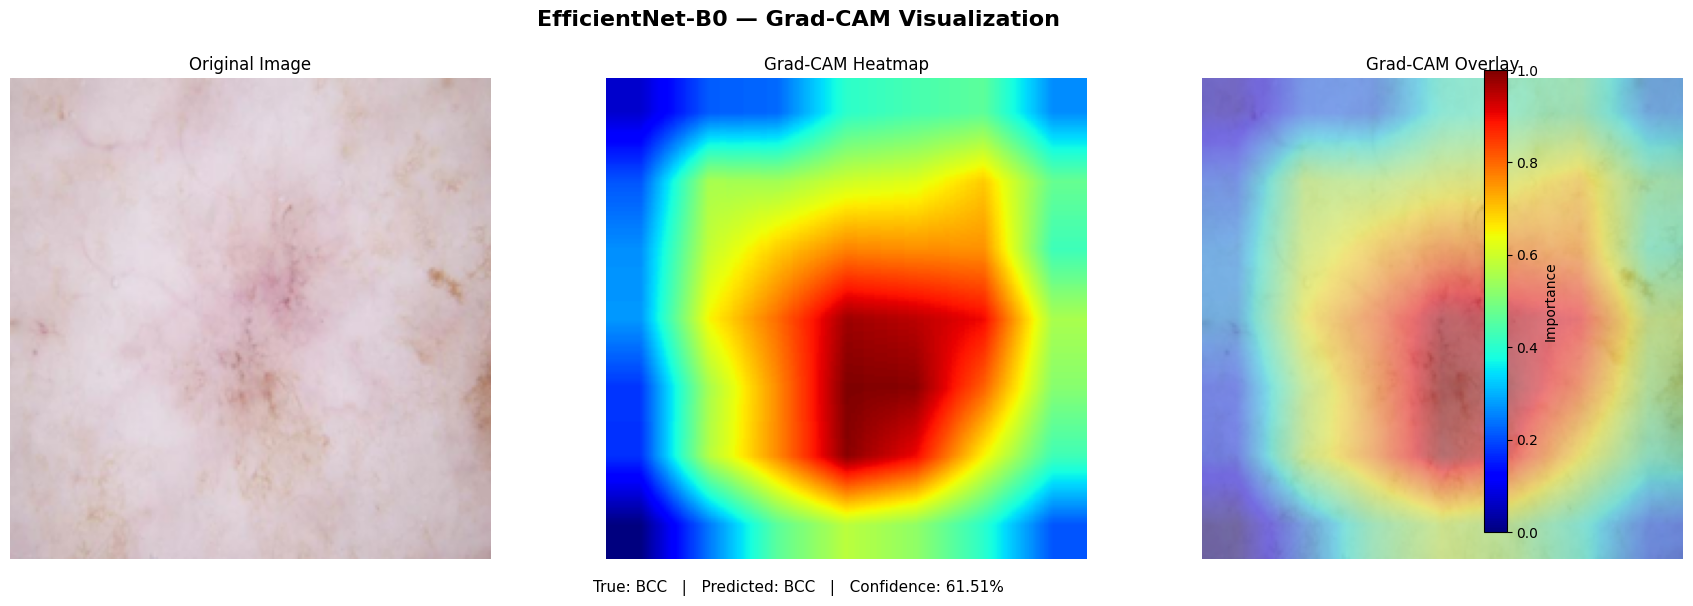


Sample 2/6
Image: ISIC_0067005.jpg


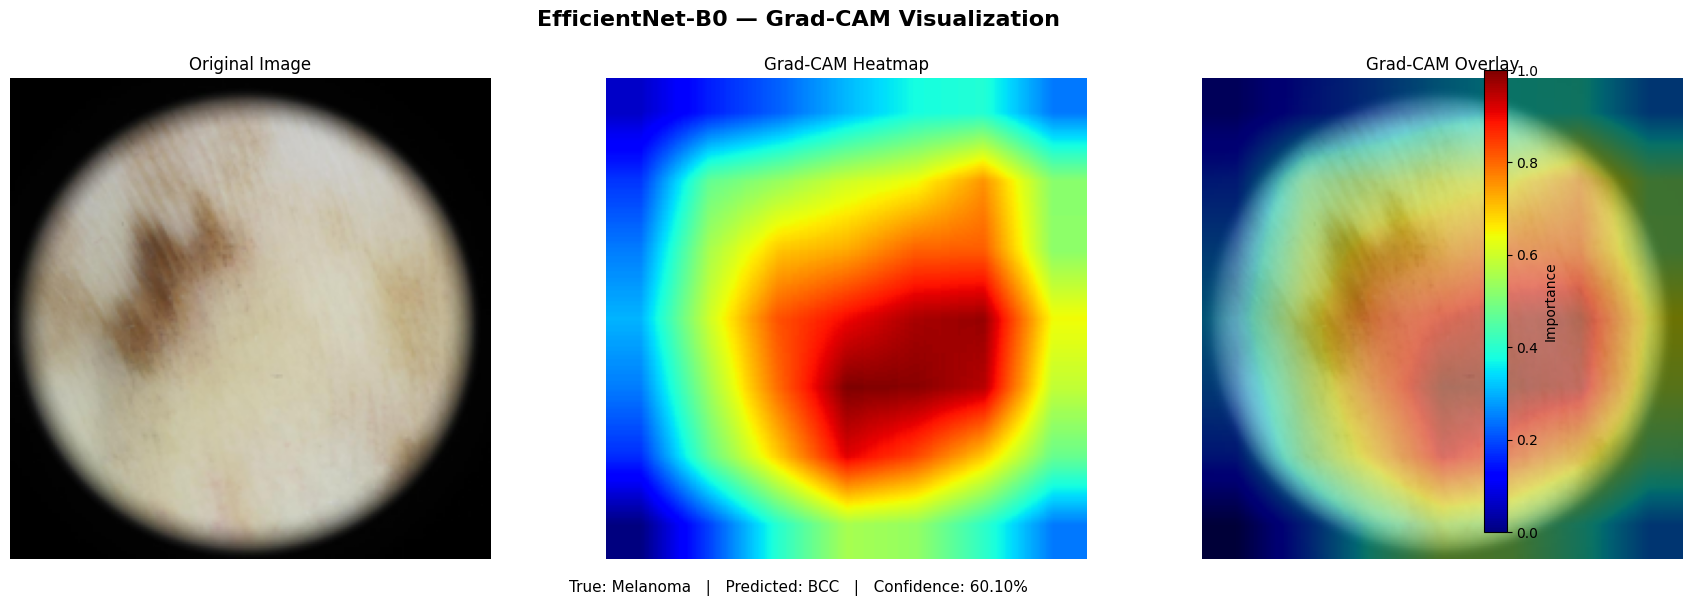


Sample 3/6
Image: ISIC_8738186.jpg


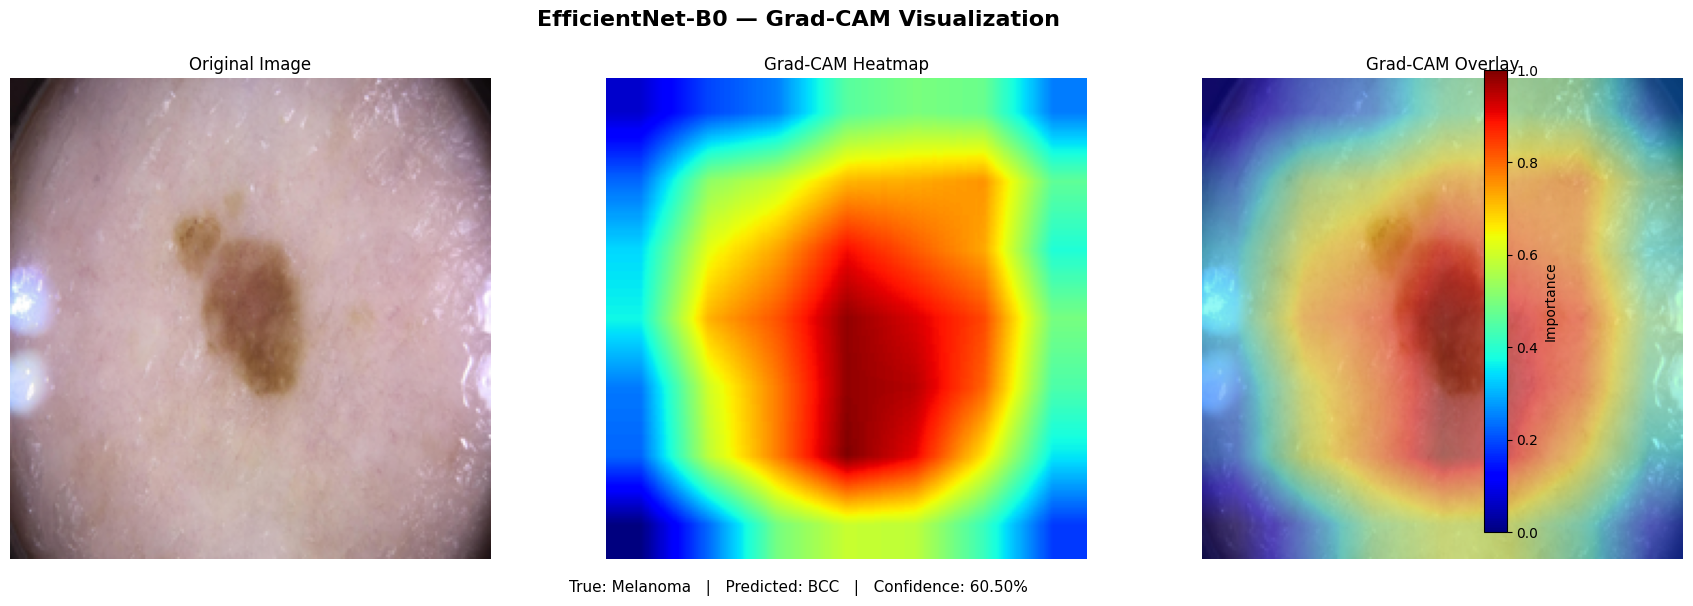


Sample 4/6
Image: ISIC_0063302.jpg


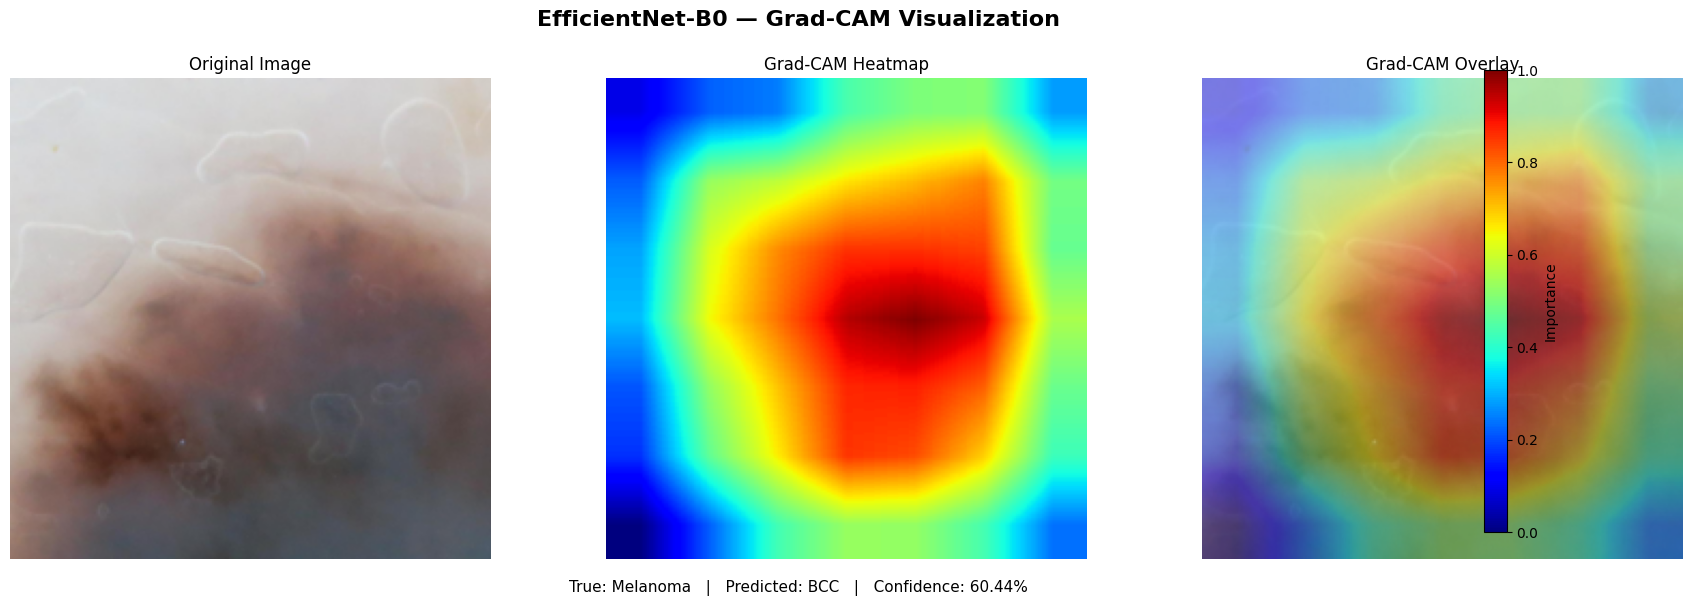


Sample 5/6
Image: ISIC_0011590.jpg


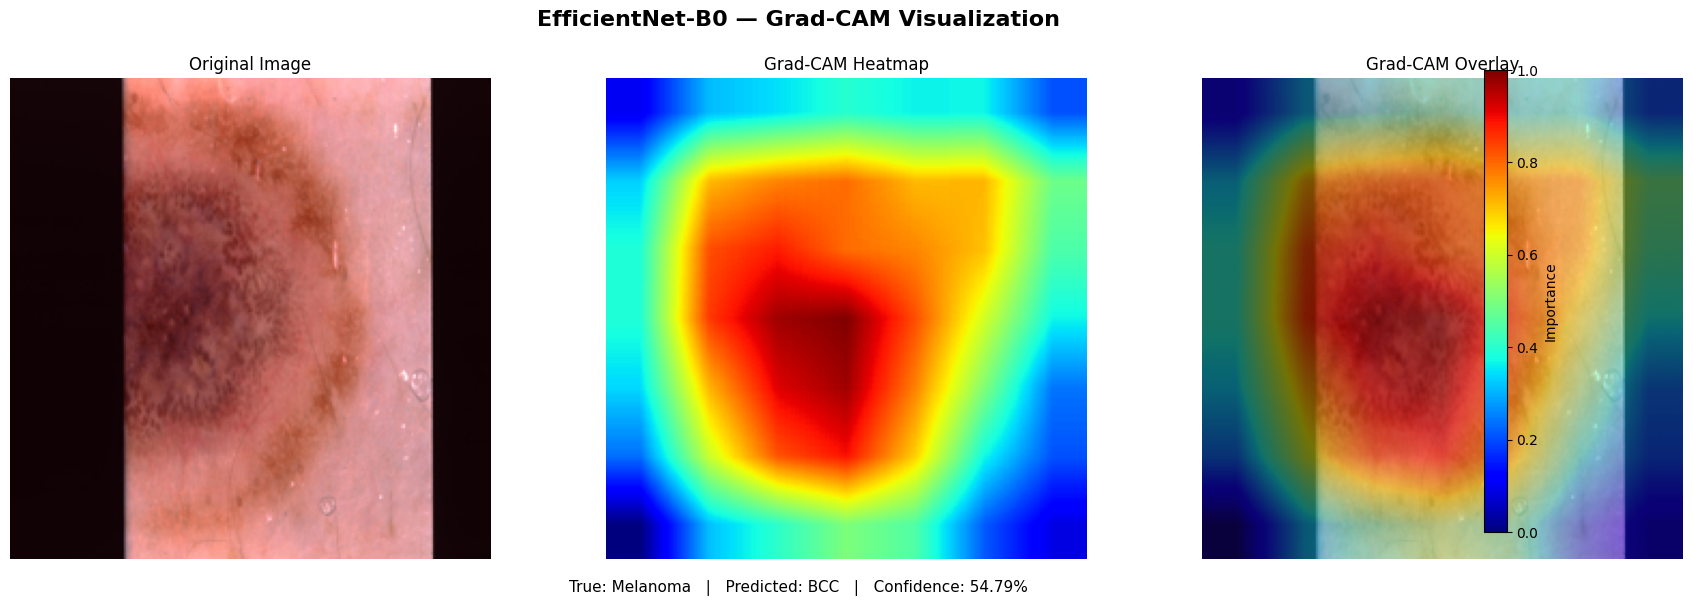


Sample 6/6
Image: ISIC_0060008.jpg


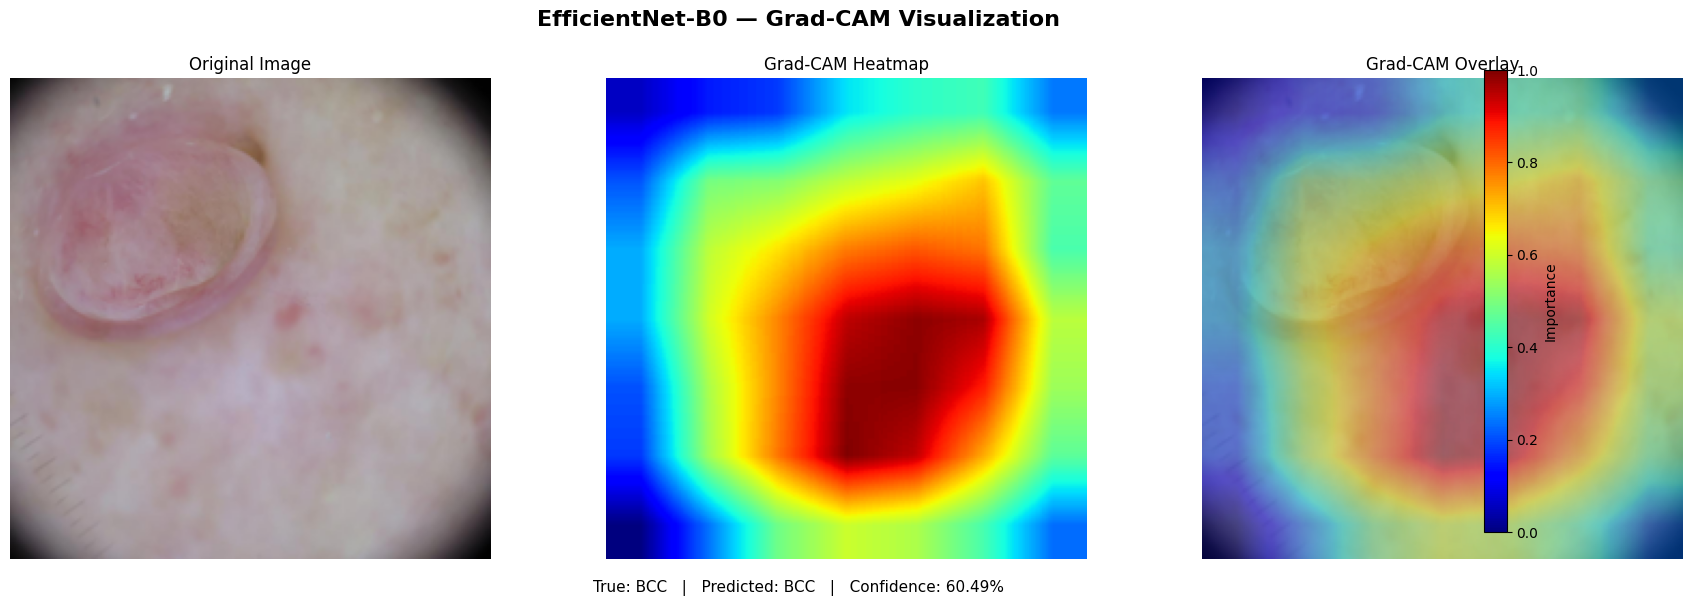


STEP 18C COMPLETE
Images visualized : 6

Grad-CAM output directory:
/kaggle/working/skin_cancer_project/results/step18C_gradcam

Results CSV:
/kaggle/working/skin_cancer_project/results/step18C_gradcam_results.csv

Summary JSON:
/kaggle/working/skin_cancer_project/results/step18C_gradcam_summary.json

✅ Grad-CAM + Heatmap generation finished.

🧹 STEP 18C memory cleanup completed.


In [60]:
  # ============================================================
# STEP 18C — GRAD-CAM + HEATMAP VISUALIZATION
# ============================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    "skin_cancer_efficientnetb0_FINAL_weights.pth"
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "test.csv"
)

GRADCAM_DIR = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam"
)

os.makedirs(
    GRADCAM_DIR,
    exist_ok=True
)

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

NUM_CLASSES = 4
INPUT_SIZE = 224

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

# Number of examples to visualize
N_SAMPLES = 6

print("=" * 75)
print("STEP 18C — GRAD-CAM + HEATMAP VISUALIZATION")
print("=" * 75)

print("Device :", DEVICE)
print("Weights:", WEIGHTS_PATH)
print("Input  :", INPUT_SIZE)
print("Classes:", CLASS_NAMES)


# ============================================================
# 2. CHECK FILES
# ============================================================

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(
        "\n❌ FINAL weights not found:\n"
        + WEIGHTS_PATH
    )

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        "\n❌ Test CSV not found:\n"
        + TEST_CSV
    )

print("\n✅ Required files found")


# ============================================================
# 3. LOAD TEST DATA
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)

print(
    "\nTest samples:",
    len(test_df)
)

print(
    "Columns:",
    test_df.columns.tolist()
)


# ============================================================
# 4. DETERMINE COLUMNS
# ============================================================

IMAGE_COL = "image_path"

if IMAGE_COL not in test_df.columns:
    raise ValueError(
        f"\n❌ '{IMAGE_COL}' column not found."
    )

if "label" in test_df.columns:
    LABEL_COL = "label"

elif "class_name" in test_df.columns:
    LABEL_COL = "class_name"

else:
    LABEL_COL = None


# ============================================================
# 5. IMAGE TRANSFORM
# ============================================================

# IMPORTANT:
# Use the same basic 224x224 input convention used by the
# EfficientNet-B0 training pipeline.

transform = transforms.Compose([
    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE)
    ),
    transforms.ToTensor()
])


# ============================================================
# 6. BUILD EFFICIENTNET-B0
# ============================================================

model = models.efficientnet_b0(
    weights=None
)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(
    DEVICE
)


# ============================================================
# 7. LOAD FINAL WEIGHTS
# ============================================================

print("\nLoading FINAL weights...")

state_dict = torch.load(
    WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        clean_key = key[7:]
    else:
        clean_key = key

    clean_state_dict[
        clean_key
    ] = value


missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False
    )
)

if missing_keys:
    print(
        "\n❌ Missing keys:",
        missing_keys
    )

if unexpected_keys:
    print(
        "\n❌ Unexpected keys:",
        unexpected_keys
    )

if missing_keys or unexpected_keys:
    raise RuntimeError(
        "\n❌ Model weights do not match architecture."
    )

model.eval()

print(
    "✅ FINAL weights loaded successfully"
)


# ============================================================
# 8. GRAD-CAM TARGET LAYER
# ============================================================

# EfficientNet-B0 final feature extractor.
#
# We capture the output of model.features[-1], which is the
# final convolutional feature representation before pooling
# and classification.

TARGET_LAYER = model.features[-1]

activations = None
gradients = None


# ============================================================
# 9. FORWARD HOOK
# ============================================================

def forward_hook(
    module,
    input,
    output
):

    global activations

    activations = output


# ============================================================
# 10. BACKWARD HOOK
# ============================================================

def backward_hook(
    module,
    grad_input,
    grad_output
):

    global gradients

    gradients = grad_output[0]


forward_handle = TARGET_LAYER.register_forward_hook(
    forward_hook
)

backward_handle = TARGET_LAYER.register_full_backward_hook(
    backward_hook
)

print(
    "✅ Grad-CAM hooks registered"
)


# ============================================================
# 11. GRAD-CAM FUNCTION
# ============================================================

def generate_gradcam(
    image_tensor,
    target_class
):

    global activations
    global gradients

    activations = None
    gradients = None

    model.zero_grad(
        set_to_none=True
    )

    output = model(
        image_tensor
    )

    score = output[
        0,
        target_class
    ]

    score.backward()

    if activations is None:
        raise RuntimeError(
            "❌ Activations were not captured."
        )

    if gradients is None:
        raise RuntimeError(
            "❌ Gradients were not captured."
        )

    # --------------------------------------------------------
    # Global average pooling over spatial dimensions
    # --------------------------------------------------------

    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    # --------------------------------------------------------
    # Weighted feature maps
    # --------------------------------------------------------

    cam = (
        weights * activations
    ).sum(
        dim=1,
        keepdim=False
    )

    cam = torch.relu(
        cam
    )

    cam = cam[
        0
    ]

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    cam -= cam.min()

    cam_max = cam.max()

    if cam_max > 0:

        cam /= cam_max

    cam = cam.detach().cpu().numpy()

    return cam


# ============================================================
# 12. IMAGE PREPARATION
# ============================================================

def load_image(
    image_path
):

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    original = image.copy()

    resized = image.resize(
        (INPUT_SIZE, INPUT_SIZE)
    )

    tensor = transform(
        image
    ).unsqueeze(
        0
    )

    tensor = tensor.to(
        DEVICE
    )

    return (
        original,
        resized,
        tensor
    )


# ============================================================
# 13. SELECT VALID TEST IMAGES
# ============================================================

valid_rows = []

for idx, row in test_df.iterrows():

    image_path = str(
        row[IMAGE_COL]
    )

    if os.path.exists(
        image_path
    ):

        valid_rows.append(
            idx
        )

    if len(valid_rows) >= N_SAMPLES:
        break


if len(valid_rows) == 0:

    raise RuntimeError(
        "\n❌ No valid test image paths found."
    )


print(
    f"\nSelected {len(valid_rows)} test images"
)


# ============================================================
# 14. GENERATE GRAD-CAM VISUALIZATIONS
# ============================================================

results = []

print("\nGenerating Grad-CAM...")
print("-" * 75)


for sample_number, row_idx in enumerate(
    valid_rows,
    start=1
):

    row = test_df.loc[
        row_idx
    ]

    image_path = str(
        row[IMAGE_COL]
    )

    print(
        f"\nSample {sample_number}/{len(valid_rows)}"
    )

    print(
        "Image:",
        os.path.basename(
            image_path
        )
    )

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original, resized, image_tensor = (
        load_image(
            image_path
        )
    )

    # --------------------------------------------------------
    # Forward prediction
    # --------------------------------------------------------

    model.zero_grad(
        set_to_none=True
    )

    output = model(
        image_tensor
    )

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_class = int(
        probabilities.argmax(
            dim=1
        ).item()
    )

    confidence = float(
        probabilities[
            0,
            predicted_class
        ].item()
    )

    # --------------------------------------------------------
    # True label
    # --------------------------------------------------------

    true_class = "Unknown"

    if LABEL_COL is not None:

        true_value = row[
            LABEL_COL
        ]

        try:

            if isinstance(
                true_value,
                (int, np.integer)
            ):

                true_idx = int(
                    true_value
                )

                if 0 <= true_idx < NUM_CLASSES:
                    true_class = CLASS_NAMES[
                        true_idx
                    ]

            elif str(
                true_value
            ).strip() in CLASS_NAMES:

                true_class = str(
                    true_value
                ).strip()

            else:

                label_map = {
                    "melanoma": "Melanoma",
                    "bcc": "BCC",
                    "scc": "SCC",
                    "mcc": "MCC"
                }

                true_class = label_map.get(
                    str(
                        true_value
                    ).strip().lower(),
                    "Unknown"
                )

        except Exception:

            true_class = "Unknown"

    # --------------------------------------------------------
    # Generate CAM
    # --------------------------------------------------------

    cam = generate_gradcam(
        image_tensor,
        predicted_class
    )

    # --------------------------------------------------------
    # Resize CAM to image size
    # --------------------------------------------------------

    cam_image = Image.fromarray(
        np.uint8(
            cam * 255
        )
    )

    cam_image = cam_image.resize(
        (INPUT_SIZE, INPUT_SIZE),
        resample=Image.BILINEAR
    )

    cam_resized = (
        np.asarray(
            cam_image
        ).astype(
            np.float32
        ) / 255.0
    )

    # --------------------------------------------------------
    # Original image array
    # --------------------------------------------------------

    original_array = np.asarray(
        resized
    ).astype(
        np.float32
    ) / 255.0

    # --------------------------------------------------------
    # Save data
    # --------------------------------------------------------

    safe_name = (
        os.path.splitext(
            os.path.basename(
                image_path
            )
        )[0]
    )

    heatmap_path = os.path.join(
        GRADCAM_DIR,
        f"{sample_number:02d}_{safe_name}_heatmap.png"
    )

    overlay_path = os.path.join(
        GRADCAM_DIR,
        f"{sample_number:02d}_{safe_name}_overlay.png"
    )

    figure_path = os.path.join(
        GRADCAM_DIR,
        f"{sample_number:02d}_{safe_name}_gradcam_figure.png"
    )

    # --------------------------------------------------------
    # Create heatmap
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        cam_resized,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    plt.axis(
        "off"
    )

    plt.colorbar(
        fraction=0.046,
        pad=0.04,
        label="Importance"
    )

    plt.title(
        f"Grad-CAM Heatmap\n"
        f"Prediction: {CLASS_NAMES[predicted_class]} "
        f"({confidence*100:.2f}%)"
    )

    plt.tight_layout()

    plt.savefig(
        heatmap_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Create overlay
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        original_array
    )

    plt.imshow(
        cam_resized,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    plt.axis(
        "off"
    )

    plt.title(
        f"Grad-CAM Overlay\n"
        f"Prediction: {CLASS_NAMES[predicted_class]} "
        f"({confidence*100:.2f}%)"
    )

    plt.colorbar(
        fraction=0.046,
        pad=0.04,
        label="Importance"
    )

    plt.tight_layout()

    plt.savefig(
        overlay_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Create 3-panel figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )

    # Original
    axes[0].imshow(
        original_array
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis(
        "off"
    )

    # Heatmap
    heatmap_plot = axes[1].imshow(
        cam_resized,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[1].axis(
        "off"
    )

    # Overlay
    axes[2].imshow(
        original_array
    )

    axes[2].imshow(
        cam_resized,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis(
        "off"
    )

    fig.colorbar(
        heatmap_plot,
        ax=axes,
        fraction=0.025,
        pad=0.02,
        label="Importance"
    )

    fig.suptitle(
        "EfficientNet-B0 — Grad-CAM Visualization",
        fontsize=16,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.01,
        (
            f"True: {true_class}   |   "
            f"Predicted: {CLASS_NAMES[predicted_class]}   |   "
            f"Confidence: {confidence*100:.2f}%"
        ),
        ha="center",
        fontsize=11
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 0.95]
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    results.append({
        "sample_number": sample_number,
        "image_name": os.path.basename(
            image_path
        ),
        "image_path": image_path,
        "true_class": true_class,
        "predicted_class": CLASS_NAMES[
            predicted_class
        ],
        "predicted_index": predicted_class,
        "confidence": confidence,
        "heatmap_path": heatmap_path,
        "overlay_path": overlay_path,
        "figure_path": figure_path
    })

    # Cleanup
    del image_tensor
    del output
    del probabilities

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 15. SAVE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_csv = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False
)


# ============================================================
# 16. SAVE JSON SUMMARY
# ============================================================

summary_json = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam_summary.json"
)

with open(
    summary_json,
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


# ============================================================
# 17. REMOVE HOOKS
# ============================================================

forward_handle.remove()
backward_handle.remove()


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 18C COMPLETE")
print("=" * 75)

print(
    f"Images visualized : {len(results)}"
)

print(
    "\nGrad-CAM output directory:"
)

print(
    GRADCAM_DIR
)

print(
    "\nResults CSV:"
)

print(
    results_csv
)

print(
    "\nSummary JSON:"
)

print(
    summary_json
)

print(
    "\n✅ Grad-CAM + Heatmap generation finished."
)

print("=" * 75)


# ============================================================
# 19. CLEANUP
# ============================================================

del model
del state_dict
del clean_state_dict

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    "\n🧹 STEP 18C memory cleanup completed."
)

In [44]:
# ============================================================
# STEP 18D-PROXY
# IMAGE-DERIVED SKIN-TONE PROXY-WISE GRAD-CAM
#
# IMPORTANT:
# Proxy Group 1-6 are NOT Fitzpatrick I-VI.
# They are dataset-relative image-derived tone groups.
# ============================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
PROJECT_DIR = "/kaggle/working/skin_cancer_project"

WEIGHTS_PATH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "skin_cancer_efficientnetb0_FINAL_weights.pth"
)

TEST_CSV = os.path.join(
    PROJECT_DIR,
    "data",
    "test.csv"
)

PROXY_MANIFEST = os.path.join(
    PROJECT_DIR,
    "results",
    "step18A_proxy",
    "step18A_skin_tone_proxy_manifest.csv"
)

PREDICTIONS_CSV = os.path.join(
    PROJECT_DIR,
    "results",
    "step18_test_predictions.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "step18D_proxy_gradcam"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

RESULTS_CSV = os.path.join(
    OUTPUT_DIR,
    "step18D_proxy_gradcam_results.csv"
)

SUMMARY_JSON = os.path.join(
    OUTPUT_DIR,
    "step18D_proxy_gradcam_summary.json"
)

COMBINED_FIGURE = os.path.join(
    OUTPUT_DIR,
    "step18D_proxy_gradcam_all_groups.png"
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
IMAGE_SIZE = 224

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# HEADER
# ------------------------------------------------------------
print("=" * 70)
print("STEP 18D-PROXY — PROXY-WISE GRAD-CAM")
print("=" * 70)

print("\nDevice :", DEVICE)
print("Weights:", WEIGHTS_PATH)
print("Input  :", IMAGE_SIZE)
print("Groups :", "1, 2, 3, 4, 5, 6")

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------
required_files = [
    WEIGHTS_PATH,
    TEST_CSV,
    PROXY_MANIFEST,
    PREDICTIONS_CSV
]

for path in required_files:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

print("\nAll required files found.")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
test_df = pd.read_csv(TEST_CSV)

proxy_df = pd.read_csv(
    PROXY_MANIFEST
)

pred_df = pd.read_csv(
    PREDICTIONS_CSV
)

print("\nTest shape      :", test_df.shape)
print("Proxy shape     :", proxy_df.shape)
print("Prediction shape:", pred_df.shape)

# ------------------------------------------------------------
# MERGE EVERYTHING
# ------------------------------------------------------------
merge_cols_proxy = [
    "image_name",
    "skin_tone_proxy_group",
    "skin_tone_proxy_label",
    "robust_L"
]

merge_cols_proxy = [
    c for c in merge_cols_proxy
    if c in proxy_df.columns
]

proxy_small = proxy_df[
    merge_cols_proxy
].drop_duplicates(
    subset=["image_name"]
)

prediction_cols = [
    "image_name",
    "true_class",
    "pred_class",
    "correct",
    "confidence"
]

prediction_cols = [
    c for c in prediction_cols
    if c in pred_df.columns
]

pred_small = pred_df[
    prediction_cols
].drop_duplicates(
    subset=["image_name"]
)

keep_test = [
    "image_name",
    "image_path"
]

if "class_name" in test_df.columns:
    keep_test.append("class_name")

test_small = test_df[
    keep_test
].drop_duplicates(
    subset=["image_name"]
)

analysis_df = (
    test_small
    .merge(
        proxy_small,
        on="image_name",
        how="inner"
    )
    .merge(
        pred_small,
        on="image_name",
        how="left"
    )
)

print(
    "\nMerged analysis rows:",
    len(analysis_df)
)

if len(analysis_df) == 0:
    raise RuntimeError(
        "No matching rows after merge."
    )

# ------------------------------------------------------------
# RESOLVE IMAGE PATH
# ------------------------------------------------------------
def resolve_path(row):

    value = str(
        row["image_path"]
    )

    candidates = [
        value,
        os.path.join(
            PROJECT_DIR,
            value
        ),
        os.path.join(
            "/kaggle/working",
            value
        )
    ]

    for p in candidates:

        if os.path.exists(p):
            return p

    return None


analysis_df["resolved_path"] = (
    analysis_df.apply(
        resolve_path,
        axis=1
    )
)

missing = analysis_df[
    "resolved_path"
].isna().sum()

print(
    "Missing image paths:",
    missing
)

if missing > 0:
    raise RuntimeError(
        f"{missing} images could not be resolved."
    )

# ------------------------------------------------------------
# LOAD EFFICIENTNET-B0
# ------------------------------------------------------------
print("\nLoading EfficientNet-B0...")

model = models.efficientnet_b0(
    weights=None
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(CLASS_NAMES)
)

state_dict = torch.load(
    WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    state_dict,
    strict=True
)

model = model.to(DEVICE)
model.eval()

print("FINAL weights loaded successfully.")

# ------------------------------------------------------------
# TRANSFORM
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

# ------------------------------------------------------------
# GRAD-CAM CLASS
# ------------------------------------------------------------
class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output
    ):

        self.activations = (
            output.detach()
        )

    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = (
            grad_output[0].detach()
        )

    def generate(
        self,
        input_tensor,
        target_class
    ):

        self.model.zero_grad(
            set_to_none=True
        )

        output = self.model(
            input_tensor
        )

        score = output[
            0,
            target_class
        ]

        score.backward()

        if self.activations is None:
            raise RuntimeError(
                "Grad-CAM activations not captured."
            )

        if self.gradients is None:
            raise RuntimeError(
                "Grad-CAM gradients not captured."
            )

        # ----------------------------------------
        # Global-average-pool gradients
        # ----------------------------------------
        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # ----------------------------------------
        # Weighted activation maps
        # ----------------------------------------
        cam = (
            weights *
            self.activations
        ).sum(
            dim=1,
            keepdim=True
        )

        # ReLU
        cam = torch.relu(
            cam
        )

        # Resize to input resolution
        cam = torch.nn.functional.interpolate(
            cam,
            size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )

        cam = cam[
            0,
            0
        ].cpu().numpy()

        # Normalize 0-1
        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max > cam_min:

            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )

        else:

            cam = np.zeros_like(
                cam
            )

        probabilities = torch.softmax(
            output,
            dim=1
        )[0].detach().cpu().numpy()

        return (
            cam,
            probabilities
        )

    def close(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


# ------------------------------------------------------------
# TARGET LAYER
# ------------------------------------------------------------
#
# EfficientNet-B0 final feature block
# ------------------------------------------------------------
target_layer = model.features[-1]

gradcam = GradCAM(
    model,
    target_layer
)

print(
    "\nGrad-CAM target layer:",
    "model.features[-1]"
)

# ------------------------------------------------------------
# SELECT REPRESENTATIVE IMAGE PER GROUP
# ------------------------------------------------------------
#
# We do NOT select manually for the "best-looking" result.
#
# Representative selection:
#   1. valid image
#   2. correctly classified if possible
#   3. closest L* to group median
#
# This reduces cherry-picking.
# ------------------------------------------------------------
selected_rows = []

for group_id in range(1, 7):

    g = analysis_df[
        analysis_df[
            "skin_tone_proxy_group"
        ].astype(int)
        == group_id
    ].copy()

    if len(g) == 0:
        print(
            f"Group {group_id}: NO IMAGE"
        )
        continue

    # Prefer correctly classified
    if "correct" in g.columns:

        correct_g = g[
            g["correct"] == True
        ].copy()

    else:

        correct_g = pd.DataFrame()

    if len(correct_g) > 0:
        candidates = correct_g
        selection_reason = (
            "correct prediction + "
            "closest to group median L*"
        )
    else:
        candidates = g
        selection_reason = (
            "closest to group median L* "
            "(no correct sample available)"
        )

    group_median_L = float(
        g["robust_L"].median()
    )

    candidates = candidates.copy()

    candidates["_distance_L"] = (
        candidates["robust_L"]
        .astype(float)
        .sub(group_median_L)
        .abs()
    )

    selected = candidates.sort_values(
        "_distance_L"
    ).iloc[0].copy()

    selected[
        "_selection_reason"
    ] = selection_reason

    selected_rows.append(
        selected
    )

selected_df = pd.DataFrame(
    selected_rows
)

print(
    "\nSelected representative images:"
)

display(
    selected_df[
        [
            "image_name",
            "skin_tone_proxy_group",
            "skin_tone_proxy_label",
            "robust_L",
            "true_class",
            "pred_class",
            "confidence",
            "_selection_reason"
        ]
    ]
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
results = []

panel_images = []

# ------------------------------------------------------------
# GENERATE GRAD-CAM
# ------------------------------------------------------------
print(
    "\nGenerating proxy-group Grad-CAM..."
)

for idx, row in selected_df.iterrows():

    group_id = int(
        row["skin_tone_proxy_group"]
    )

    image_name = str(
        row["image_name"]
    )

    image_path = str(
        row["resolved_path"]
    )

    print(
        f"\nGroup {group_id}/6"
    )

    print(
        "Image:",
        image_name
    )

    # ----------------------------------------
    # Load original image
    # ----------------------------------------
    with Image.open(
        image_path
    ) as img:

        original = img.convert(
            "RGB"
        )

    original_resized = original.resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    )

    original_np = np.asarray(
        original_resized
    ).astype(
        np.float32
    ) / 255.0

    # ----------------------------------------
    # Tensor
    # ----------------------------------------
    input_tensor = transform(
        original_resized
    ).unsqueeze(0).to(
        DEVICE
    )

    # ----------------------------------------
    # Prediction + Grad-CAM
    # ----------------------------------------
    cam, probabilities = (
        gradcam.generate(
            input_tensor,
            target_class=int(
                model(input_tensor)
                .argmax(dim=1)
                .item()
            )
        )
    )

    # Re-run prediction cleanly
    with torch.no_grad():

        logits = model(
            input_tensor
        )

        pred_index = int(
            logits.argmax(
                dim=1
            ).item()
        )

        probs = torch.softmax(
            logits,
            dim=1
        )[0].cpu().numpy()

    predicted_class = (
        CLASS_NAMES[
            pred_index
        ]
    )

    predicted_confidence = float(
        probs[pred_index]
    )

    true_class = str(
        row["true_class"]
    )

    # ----------------------------------------
    # Heatmap
    # ----------------------------------------
    heatmap_rgba = plt.cm.jet(
        cam
    )

    heatmap_rgb = heatmap_rgba[
        :, :, :3
    ]

    # ----------------------------------------
    # Overlay
    # ----------------------------------------
    overlay = (
        0.55 * original_np
        +
        0.45 * heatmap_rgb
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # ----------------------------------------
    # Save individual figure
    # ----------------------------------------
    safe_name = (
        os.path.splitext(
            image_name
        )[0]
        .replace(
            "/",
            "_"
        )
    )

    output_path = os.path.join(
        OUTPUT_DIR,
        f"group_{group_id}_{safe_name}_gradcam.png"
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        original_np
    )

    axes[0].set_title(
        f"Original\nProxy Group {group_id}"
    )

    axes[0].axis(
        "off"
    )

    im = axes[1].imshow(
        cam,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[1].axis(
        "off"
    )

    fig.colorbar(
        im,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        f"Overlay\n"
        f"True: {true_class} | "
        f"Pred: {predicted_class} "
        f"({predicted_confidence:.1%})"
    )

    axes[2].axis(
        "off"
    )

    fig.suptitle(
        f"STEP 18D-PROXY — "
        f"Proxy Group {group_id}\n"
        f"Image: {image_name}",
        fontsize=13
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )

    # ----------------------------------------
    # Store panel data
    # ----------------------------------------
    panel_images.append({
        "group_id": group_id,
        "image_name": image_name,
        "original": original_np,
        "cam": cam,
        "overlay": overlay,
        "true_class": true_class,
        "predicted_class": predicted_class,
        "confidence": predicted_confidence
    })

    # ----------------------------------------
    # Result row
    # ----------------------------------------
    results.append({
        "proxy_group": group_id,
        "proxy_label": row[
            "skin_tone_proxy_label"
        ],
        "image_name": image_name,
        "robust_L": float(
            row["robust_L"]
        ),
        "true_class": true_class,
        "predicted_class": predicted_class,
        "confidence": predicted_confidence,
        "correct": (
            predicted_class
            == true_class
        ),
        "output_file": output_path,
        "selection_reason": row[
            "_selection_reason"
        ]
    })

    print(
        "True:",
        true_class
    )

    print(
        "Pred:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{predicted_confidence:.4f}"
    )

    print(
        "Saved:",
        output_path
    )

# ------------------------------------------------------------
# COMBINED SIX-GROUP FIGURE
# ------------------------------------------------------------
print(
    "\nCreating combined 6-group figure..."
)

if len(panel_images) > 0:

    fig, axes = plt.subplots(
        len(panel_images),
        3,
        figsize=(15, 5 * len(panel_images))
    )

    if len(panel_images) == 1:
        axes = np.expand_dims(
            axes,
            axis=0
        )

    for r, item in enumerate(
        panel_images
    ):

        group_id = item[
            "group_id"
        ]

        axes[r, 0].imshow(
            item["original"]
        )

        axes[r, 0].set_title(
            f"Group {group_id} — Original"
        )

        axes[r, 0].axis(
            "off"
        )

        im = axes[r, 1].imshow(
            item["cam"],
            cmap="jet",
            vmin=0,
            vmax=1
        )

        axes[r, 1].set_title(
            "Grad-CAM Heatmap"
        )

        axes[r, 1].axis(
            "off"
        )

        axes[r, 2].imshow(
            item["overlay"]
        )

        axes[r, 2].set_title(
            f"Overlay | "
            f"True: {item['true_class']} | "
            f"Pred: {item['predicted_class']} "
            f"({item['confidence']:.1%})"
        )

        axes[r, 2].axis(
            "off"
        )

    fig.suptitle(
        "STEP 18D-PROXY — "
        "Image-Derived Skin-Tone Proxy Groups",
        fontsize=16,
        y=0.995
    )

    plt.tight_layout()

    fig.savefig(
        COMBINED_FIGURE,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------
results_df = pd.DataFrame(
    results
)

results_df.to_csv(
    RESULTS_CSV,
    index=False
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
summary = {
    "step": "18D-PROXY",
    "status": "COMPLETE",

    "number_of_groups": int(
        len(panel_images)
    ),

    "groups_visualized": [
        int(x["group_id"])
        for x in panel_images
    ],

    "target_layer": "model.features[-1]",

    "selection_method": (
        "One representative image per proxy group; "
        "prefer correctly classified samples and "
        "choose the image closest to that group's "
        "median robust L* value."
    ),

    "important_note": (
        "Proxy Group 1-6 are image-derived, "
        "dataset-relative skin-tone proxy groups. "
        "They are NOT Fitzpatrick I-VI labels."
    ),

    "results_csv": RESULTS_CSV,
    "combined_figure": COMBINED_FIGURE,

    "individual_output_directory": OUTPUT_DIR
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------
gradcam.close()

del model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 18D-PROXY COMPLETE")
print("=" * 70)

print(
    "\nGroups visualized:",
    len(panel_images)
)

print(
    "\nResults CSV:"
)

print(
    RESULTS_CSV
)

print(
    "\nCombined figure:"
)

print(
    COMBINED_FIGURE
)

print(
    "\nSummary JSON:"
)

print(
    SUMMARY_JSON
)

print(
    "\nIndividual Grad-CAM images:"
)

print(
    OUTPUT_DIR
)

print(
    "\nIMPORTANT:"
)

print(
    "These are proxy-group Grad-CAM visualizations."
)

print(
    "They are NOT Fitzpatrick-wise clinical Grad-CAM."
)

print(
    "\nMemory cleanup complete."
)

STEP 18D-PROXY — PROXY-WISE GRAD-CAM

Device : cuda:0
Weights: /kaggle/working/skin_cancer_project/checkpoints/skin_cancer_efficientnetb0_FINAL_weights.pth
Input  : 224
Groups : 1, 2, 3, 4, 5, 6

All required files found.

Test shape      : (2052, 7)
Proxy shape     : (2052, 13)
Prediction shape: (2052, 18)

Merged analysis rows: 2052
Missing image paths: 0

Loading EfficientNet-B0...
FINAL weights loaded successfully.

Grad-CAM target layer: model.features[-1]

Selected representative images:


,image_name,skin_tone_proxy_group,skin_tone_proxy_label,robust_L,true_class,pred_class,confidence,_selection_reason
785,ISIC_0057020,1,Proxy Group 1 - Lightest,55.112564,BCC,BCC,0.402972,correct prediction + closest to group median L*
270,ISIC_0057170,2,Proxy Group 2,60.952492,BCC,BCC,0.569917,correct prediction + closest to group median L*
111,ISIC_0066430,3,Proxy Group 3,64.965759,Melanoma,Melanoma,0.642478,correct prediction + closest to group median L*
732,ISIC_0031531,4,Proxy Group 4,69.371773,BCC,BCC,0.515448,correct prediction + closest to group median L*
6,ISIC_0022332,5,Proxy Group 5,73.454239,Melanoma,Melanoma,0.824028,correct prediction + closest to group median L*
1339,ISIC_0065843,6,Proxy Group 6 - Darkest,79.189224,Melanoma,Melanoma,0.371824,correct prediction + closest to group median L*



Generating proxy-group Grad-CAM...

Group 1/6
Image: ISIC_0057020
True: BCC
Pred: BCC
Confidence: 0.3894
Saved: /kaggle/working/skin_cancer_project/results/step18D_proxy_gradcam/group_1_ISIC_0057020_gradcam.png

Group 2/6
Image: ISIC_0057170
True: BCC
Pred: BCC
Confidence: 0.5688
Saved: /kaggle/working/skin_cancer_project/results/step18D_proxy_gradcam/group_2_ISIC_0057170_gradcam.png

Group 3/6
Image: ISIC_0066430
True: Melanoma
Pred: Melanoma
Confidence: 0.6493
Saved: /kaggle/working/skin_cancer_project/results/step18D_proxy_gradcam/group_3_ISIC_0066430_gradcam.png

Group 4/6
Image: ISIC_0031531
True: BCC
Pred: BCC
Confidence: 0.5143
Saved: /kaggle/working/skin_cancer_project/results/step18D_proxy_gradcam/group_4_ISIC_0031531_gradcam.png

Group 5/6
Image: ISIC_0022332
True: Melanoma
Pred: Melanoma
Confidence: 0.8279
Saved: /kaggle/working/skin_cancer_project/results/step18D_proxy_gradcam/group_5_ISIC_0022332_gradcam.png

Group 6/6
Image: ISIC_0065843
True: Melanoma
Pred: Melanoma
Con

In [61]:
# ============================================================
# STEP 18D — EFFICIENTNET-B0 GRAD-CAM RESULTS VERIFICATION
# ============================================================

import os
import json
import pandas as pd

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

GRADCAM_DIR = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam"
)

RESULTS_CSV = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam_results.csv"
)

SUMMARY_JSON = os.path.join(
    RESULTS_DIR,
    "step18C_gradcam_summary.json"
)

print("=" * 75)
print("STEP 18D — EFFICIENTNET-B0 GRAD-CAM RESULTS VERIFICATION")
print("=" * 75)


# ============================================================
# 1. CHECK OUTPUT FILES
# ============================================================

if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError(
        "\n❌ Grad-CAM results CSV not found:\n"
        + RESULTS_CSV
    )

if not os.path.exists(SUMMARY_JSON):
    raise FileNotFoundError(
        "\n❌ Grad-CAM summary JSON not found:\n"
        + SUMMARY_JSON
    )

print("\n✅ Grad-CAM output files found")


# ============================================================
# 2. LOAD RESULTS
# ============================================================

gradcam_df = pd.read_csv(
    RESULTS_CSV
)

print(
    "\nNumber of Grad-CAM samples:",
    len(gradcam_df)
)

print(
    "\nGrad-CAM Results:"
)

display(
    gradcam_df[
        [
            "sample_number",
            "image_name",
            "true_class",
            "predicted_class",
            "confidence"
        ]
    ]
)


# ============================================================
# 3. PREDICTION DISTRIBUTION
# ============================================================

print("\n" + "-" * 75)
print("Predicted Class Distribution")
print("-" * 75)

prediction_distribution = (
    gradcam_df[
        "predicted_class"
    ]
    .value_counts()
    .reindex(
        [
            "Melanoma",
            "BCC",
            "SCC",
            "MCC"
        ],
        fill_value=0
    )
)

display(
    prediction_distribution
    .rename("count")
    .to_frame()
)


# ============================================================
# 4. CONFIDENCE SUMMARY
# ============================================================

print("\n" + "-" * 75)
print("Prediction Confidence Summary")
print("-" * 75)

confidence_summary = gradcam_df[
    "confidence"
].describe()

display(
    confidence_summary.to_frame(
        name="confidence"
    )
)


# ============================================================
# 5. VERIFY GENERATED IMAGE FILES
# ============================================================

print("\n" + "-" * 75)
print("Grad-CAM File Verification")
print("-" * 75)

heatmap_exists = []
overlay_exists = []
figure_exists = []

for _, row in gradcam_df.iterrows():

    heatmap_exists.append(
        os.path.exists(
            str(row["heatmap_path"])
        )
    )

    overlay_exists.append(
        os.path.exists(
            str(row["overlay_path"])
        )
    )

    figure_exists.append(
        os.path.exists(
            str(row["figure_path"])
        )
    )

print(
    "Heatmaps found:",
    sum(heatmap_exists),
    "/",
    len(heatmap_exists)
)

print(
    "Overlays found:",
    sum(overlay_exists),
    "/",
    len(overlay_exists)
)

print(
    "3-panel figures found:",
    sum(figure_exists),
    "/",
    len(figure_exists)
)


# ============================================================
# 6. SAVE VERIFICATION SUMMARY
# ============================================================

verification = {
    "step": "18D",
    "model": "EfficientNet-B0",
    "gradcam_samples": int(len(gradcam_df)),
    "heatmaps_found": int(sum(heatmap_exists)),
    "overlays_found": int(sum(overlay_exists)),
    "three_panel_figures_found": int(sum(figure_exists)),
    "gradcam_results_csv": RESULTS_CSV,
    "gradcam_output_directory": GRADCAM_DIR
}

verification_json = os.path.join(
    RESULTS_DIR,
    "step18D_gradcam_verification.json"
)

with open(
    verification_json,
    "w"
) as f:

    json.dump(
        verification,
        f,
        indent=4
    )


# ============================================================
# 7. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 18D COMPLETE")
print("=" * 75)

if (
    all(heatmap_exists)
    and all(overlay_exists)
    and all(figure_exists)
):

    print(
        "✅ All Grad-CAM outputs verified successfully."
    )

else:

    print(
        "⚠️ Some Grad-CAM output files are missing."
    )

print(
    "\nVerification JSON:"
)

print(
    verification_json
)

print("=" * 75)

STEP 18D — EFFICIENTNET-B0 GRAD-CAM RESULTS VERIFICATION

✅ Grad-CAM output files found

Number of Grad-CAM samples: 6

Grad-CAM Results:


,sample_number,image_name,true_class,predicted_class,confidence
0,1,ISIC_0025322.jpg,BCC,BCC,0.615056
1,2,ISIC_0067005.jpg,Melanoma,BCC,0.601033
2,3,ISIC_8738186.jpg,Melanoma,BCC,0.604971
3,4,ISIC_0063302.jpg,Melanoma,BCC,0.604365
4,5,ISIC_0011590.jpg,Melanoma,BCC,0.547920
5,6,ISIC_0060008.jpg,BCC,BCC,0.604904



---------------------------------------------------------------------------
Predicted Class Distribution
---------------------------------------------------------------------------


,count
predicted_class,
Melanoma,0
BCC,6
SCC,0
MCC,0



---------------------------------------------------------------------------
Prediction Confidence Summary
---------------------------------------------------------------------------


,confidence
count,6.000000
mean,0.596375
std,0.024203
min,0.547920
25%,0.601866
50%,0.604635
75%,0.604954
max,0.615056



---------------------------------------------------------------------------
Grad-CAM File Verification
---------------------------------------------------------------------------
Heatmaps found: 6 / 6
Overlays found: 6 / 6
3-panel figures found: 6 / 6

STEP 18D COMPLETE
✅ All Grad-CAM outputs verified successfully.

Verification JSON:
/kaggle/working/skin_cancer_project/results/step18D_gradcam_verification.json


STEP 19 FINAL — EFFICIENTNET-B0 TRAINING CURVES

Actual recorded epochs: 10

History columns:
['Epoch', 'train_loss', 'val_loss', 'learning_rate']

Best Validation Loss:
Epoch 9 → 1.75839

Creating Chart 1 — Loss...


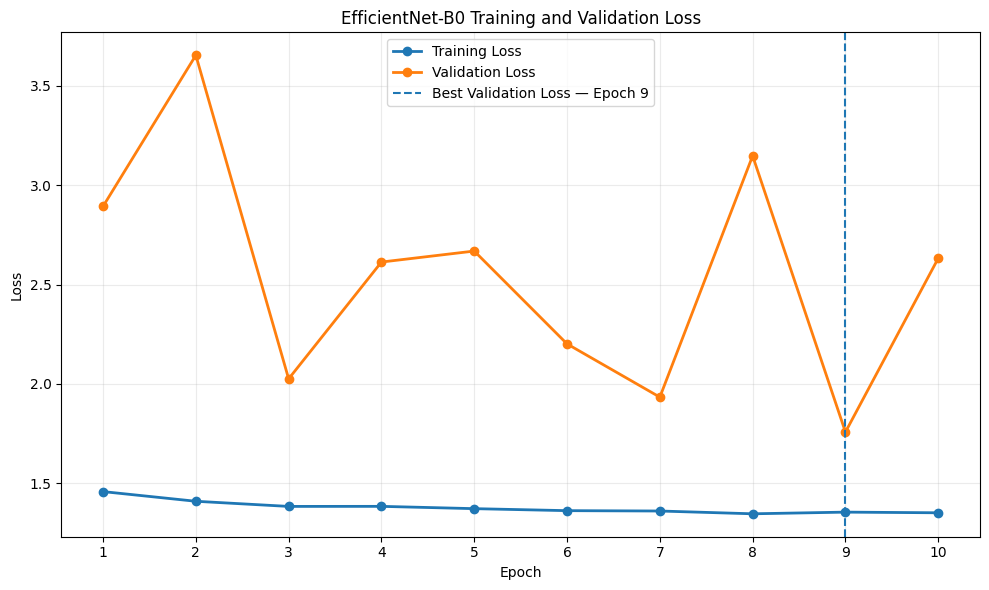

✅ Chart 1 saved:
/kaggle/working/skin_cancer_project/results/STEP19_FINAL_training_validation_loss.png

Creating Chart 2 — Learning Rate...


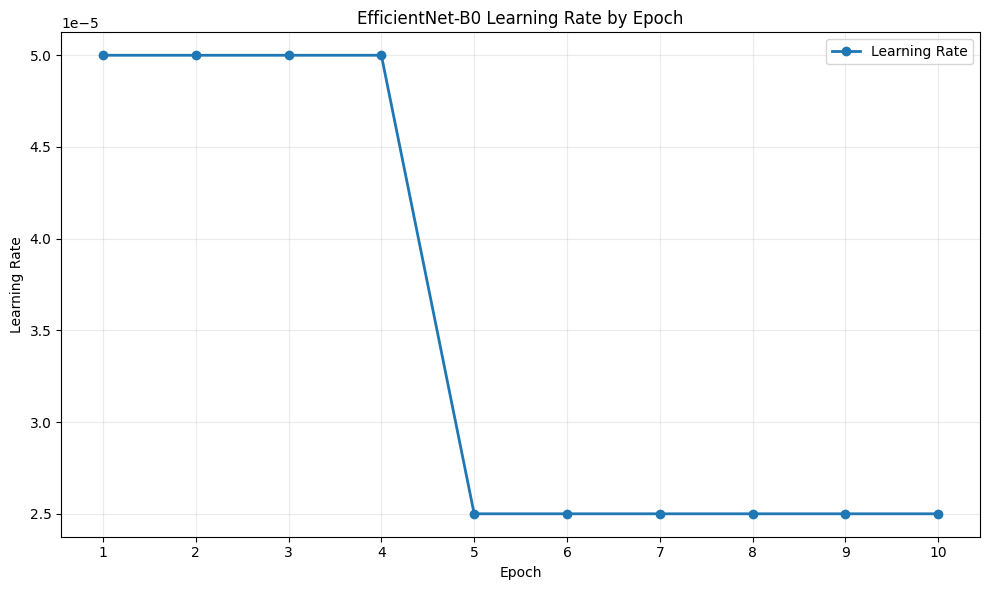

✅ Chart 2 saved:
/kaggle/working/skin_cancer_project/results/STEP19_FINAL_learning_rate.png

FINAL EFFICIENTNET-B0 TRAINING HISTORY


,Epoch,train_loss,val_loss,learning_rate
0,1,1.459030,2.892965,0.000050
1,2,1.410372,3.652683,0.000050
2,3,1.384510,2.025852,0.000050
3,4,1.384819,2.613092,0.000050
4,5,1.373264,2.668334,0.000025
5,6,1.363192,2.201595,0.000025
6,7,1.361408,1.933845,0.000025
7,8,1.347412,3.146964,0.000025
8,9,1.355791,1.758393,0.000025
9,10,1.352487,2.632037,0.000025



ACCURACY HISTORY STATUS

⚠️ train_acc / val_acc were not recorded in the final EfficientNet-B0 history.
✓ Loss curve uses real recorded values.
✓ Learning-rate curve uses real recorded values.
✓ No artificial accuracy values were created.

STEP 19 FINAL COMPLETE

Best Validation Loss:
Epoch 9 → 1.75839

Chart 1:
/kaggle/working/skin_cancer_project/results/STEP19_FINAL_training_validation_loss.png

Chart 2:
/kaggle/working/skin_cancer_project/results/STEP19_FINAL_learning_rate.png

Training History CSV:
/kaggle/working/skin_cancer_project/results/STEP19_FINAL_training_history.csv

✅ TWO REAL FINAL-MODEL TRAINING CHARTS GENERATED


In [65]:
# ============================================================
# STEP 19 FINAL — EFFICIENTNET-B0 TRAINING CURVES
#                 LOSS + LEARNING RATE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("STEP 19 FINAL — EFFICIENTNET-B0 TRAINING CURVES")
print("=" * 75)


# ============================================================
# 1. RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 2. GET REAL TRAINING HISTORY
# ============================================================

if "history" not in globals():

    raise RuntimeError(
        "\n❌ Final EfficientNet-B0 'history' variable "
        "is not available."
    )


if not isinstance(history, dict):

    raise TypeError(
        "\n❌ Expected history to be a dictionary."
    )


required_keys = [
    "train_loss",
    "val_loss",
    "learning_rate"
]

for key in required_keys:

    if key not in history:

        raise KeyError(
            f"\n❌ Missing history key: {key}"
        )


# ============================================================
# 3. CREATE HISTORY DATAFRAME
# ============================================================

num_epochs = len(
    history["train_loss"]
)

epochs = np.arange(
    1,
    num_epochs + 1
)

history_df = pd.DataFrame({

    "Epoch": epochs,

    "train_loss": np.asarray(
        history["train_loss"],
        dtype=float
    ),

    "val_loss": np.asarray(
        history["val_loss"],
        dtype=float
    ),

    "learning_rate": np.asarray(
        history["learning_rate"],
        dtype=float
    )
})


print(
    "\nActual recorded epochs:",
    num_epochs
)

print(
    "\nHistory columns:"
)

print(
    history_df.columns.tolist()
)


# ============================================================
# 4. BEST VALIDATION LOSS
# ============================================================

best_idx = (
    history_df["val_loss"]
    .idxmin()
)

best_epoch = int(
    history_df.loc[
        best_idx,
        "Epoch"
    ]
)

best_val_loss = float(
    history_df.loc[
        best_idx,
        "val_loss"
    ]
)

print(
    "\nBest Validation Loss:"
)

print(
    f"Epoch {best_epoch} → "
    f"{best_val_loss:.5f}"
)


# ============================================================
# 5. CHART 1 — LOSS CURVE
# ============================================================

print(
    "\nCreating Chart 1 — Loss..."
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best Validation Loss — "
        f"Epoch {best_epoch}"
    )
)

plt.title(
    "EfficientNet-B0 Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


loss_plot_path = os.path.join(
    RESULTS_DIR,
    "STEP19_FINAL_training_validation_loss.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


print(
    "✅ Chart 1 saved:"
)

print(
    loss_plot_path
)


# ============================================================
# 6. CHART 2 — LEARNING RATE CURVE
# ============================================================

print(
    "\nCreating Chart 2 — Learning Rate..."
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["Epoch"],
    history_df["learning_rate"],
    marker="o",
    linewidth=2,
    label="Learning Rate"
)

plt.title(
    "EfficientNet-B0 Learning Rate by Epoch"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


lr_plot_path = os.path.join(
    RESULTS_DIR,
    "STEP19_FINAL_learning_rate.png"
)

plt.savefig(
    lr_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


print(
    "✅ Chart 2 saved:"
)

print(
    lr_plot_path
)


# ============================================================
# 7. SAVE TRAINING HISTORY TABLE
# ============================================================

history_csv_path = os.path.join(
    RESULTS_DIR,
    "STEP19_FINAL_training_history.csv"
)

history_df.to_csv(
    history_csv_path,
    index=False
)


# ============================================================
# 8. DISPLAY HISTORY TABLE
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "FINAL EFFICIENTNET-B0 TRAINING HISTORY"
)

print(
    "=" * 75
)

display(
    history_df.round(6)
)


# ============================================================
# 9. ACCURACY STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "ACCURACY HISTORY STATUS"
)

print(
    "=" * 75
)

print(
    "\n⚠️ train_acc / val_acc were not recorded "
    "in the final EfficientNet-B0 history."
)

print(
    "✓ Loss curve uses real recorded values."
)

print(
    "✓ Learning-rate curve uses real recorded values."
)

print(
    "✓ No artificial accuracy values were created."
)


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 19 FINAL COMPLETE"
)

print(
    "=" * 75
)

print(
    "\nBest Validation Loss:"
)

print(
    f"Epoch {best_epoch} → "
    f"{best_val_loss:.5f}"
)

print(
    "\nChart 1:"
)

print(
    loss_plot_path
)

print(
    "\nChart 2:"
)

print(
    lr_plot_path
)

print(
    "\nTraining History CSV:"
)

print(
    history_csv_path
)

print(
    "\n✅ TWO REAL FINAL-MODEL TRAINING CHARTS GENERATED"
)

print("=" * 75)

In [64]:
# ============================================================
# STEP 19A — CHECK FINAL EFFICIENTNET-B0 TRAINING HISTORY
# ============================================================

print("=" * 75)
print("STEP 19A — FINAL EFFICIENTNET-B0 HISTORY CHECK")
print("=" * 75)

if "history" not in globals():

    print("\n❌ 'history' variable is not available.")
    print("The final EfficientNet-B0 training history was not retained.")

else:

    print("\n✅ 'history' variable found.")

    print(
        "\nHistory type:",
        type(history)
    )

    # --------------------------------------------------------
    # CHECK DICTIONARY HISTORY
    # --------------------------------------------------------

    if isinstance(history, dict):

        print("\nHistory keys:")
        print(
            list(history.keys())
        )

        print("\nAvailable training records:")

        for key, value in history.items():

            try:
                print(
                    f"{key}: {len(value)} values"
                )
            except Exception:
                print(
                    f"{key}: available"
                )

    # --------------------------------------------------------
    # CHECK DATAFRAME HISTORY
    # --------------------------------------------------------

    elif isinstance(history, pd.DataFrame):

        print(
            "\nHistory columns:"
        )

        print(
            history.columns.tolist()
        )

        print(
            "\nHistory shape:",
            history.shape
        )

        display(
            history.head(10)
        )

    else:

        print(
            "\nHistory object contents:"
        )

        print(
            history
        )

print("\n" + "=" * 75)
print("STEP 19A COMPLETE")
print("=" * 75)

STEP 19A — FINAL EFFICIENTNET-B0 HISTORY CHECK

✅ 'history' variable found.

History type: <class 'dict'>

History keys:
['train_loss', 'val_loss', 'learning_rate']

Available training records:
train_loss: 10 values
val_loss: 10 values
learning_rate: 10 values

STEP 19A COMPLETE


STEP 19B — EFFICIENTNET-B0 FINAL CLASS-WISE PERFORMANCE

Loaded metrics:
/kaggle/working/skin_cancer_project/results/step18_class_wise_metrics.csv

Columns:
['Unnamed: 0', 'precision', 'recall', 'f1-score', 'support']

RAW STEP 18 METRICS


,class_name,precision,recall,f1-score,support
0,Melanoma,0.8620,0.7355,0.7937,1104.0000
1,BCC,0.5848,0.8792,0.7024,737.0000
2,SCC,0.0000,0.0000,0.0000,207.0000
3,MCC,0.0000,0.0000,0.0000,4.0000
4,accuracy,0.7115,0.7115,0.7115,0.7115
5,macro avg,0.3617,0.4037,0.3740,2052.0000
6,weighted avg,0.6738,0.7115,0.6793,2052.0000



EFFICIENTNET-B0 FINAL CLASS-WISE PERFORMANCE


,class_name,precision,recall,f1-score,support
0,Melanoma,0.8620,0.7355,0.7937,1104.0
1,BCC,0.5848,0.8792,0.7024,737.0
2,SCC,0.0000,0.0000,0.0000,207.0
3,MCC,0.0000,0.0000,0.0000,4.0


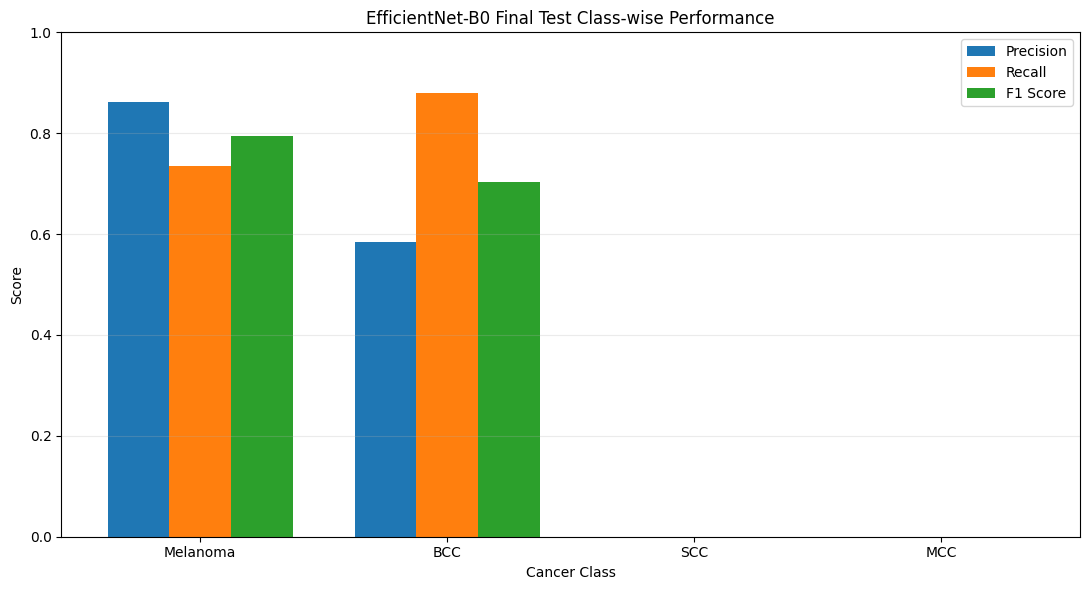


STEP 19B — EFFICIENTNET-B0 COMPLETE

Model:
EfficientNet-B0

Actual cancer classes:
['Melanoma', 'BCC', 'SCC', 'MCC']

Chart saved:
/kaggle/working/skin_cancer_project/results/efficientnetb0_final_classwise_performance.png

Clean CSV saved:
/kaggle/working/skin_cancer_project/results/step19B_efficientnetb0_classwise_performance.csv

Important:
This chart uses the values stored in step18_class_wise_metrics.csv.
No screenshot values or manually entered values are used.



In [56]:
# ============================================================
# STEP 19B — EFFICIENTNET-B0 FINAL CLASS-WISE PERFORMANCE
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("STEP 19B — EFFICIENTNET-B0 FINAL CLASS-WISE PERFORMANCE")
print("=" * 75)


# ------------------------------------------------------------
# 1. PATH
# ------------------------------------------------------------

RESULTS_DIR = (
    "/kaggle/working/skin_cancer_project/results"
)

METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "step18_class_wise_metrics.csv"
)


# ------------------------------------------------------------
# 2. CHECK METRICS FILE
# ------------------------------------------------------------

if not os.path.exists(METRICS_PATH):

    raise FileNotFoundError(
        f"\nMetrics file not found:\n{METRICS_PATH}"
    )


# ------------------------------------------------------------
# 3. LOAD METRICS
# ------------------------------------------------------------

metrics_df = pd.read_csv(
    METRICS_PATH
)

print("\nLoaded metrics:")
print(METRICS_PATH)

print("\nColumns:")
print(metrics_df.columns.tolist())


# ------------------------------------------------------------
# 4. IDENTIFY CLASS COLUMN
# ------------------------------------------------------------

if "Unnamed: 0" in metrics_df.columns:

    metrics_df = metrics_df.rename(
        columns={
            "Unnamed: 0": "class_name"
        }
    )

elif "class_name" not in metrics_df.columns:

    raise KeyError(
        "\nCould not find class-name column."
    )


# ------------------------------------------------------------
# 5. REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "class_name",
    "precision",
    "recall",
    "f1-score",
    "support"
]

for col in required_columns:

    if col not in metrics_df.columns:

        raise KeyError(
            f"\nRequired column missing: {col}"
        )


# ------------------------------------------------------------
# 6. DISPLAY RAW METRICS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RAW STEP 18 METRICS")
print("=" * 75)

display(
    metrics_df.round(4)
)


# ============================================================
# 7. FOUR CANCER CLASSES
# ============================================================

class_names = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]


# ------------------------------------------------------------
# 8. FILTER CANCER CLASSES
# ------------------------------------------------------------

class_df = metrics_df[
    metrics_df["class_name"].isin(class_names)
].copy()


# ------------------------------------------------------------
# 9. CHECK MISSING CLASSES
# ------------------------------------------------------------

found_classes = class_df[
    "class_name"
].astype(str).tolist()

missing_classes = [
    cls
    for cls in class_names
    if cls not in found_classes
]

if len(missing_classes) > 0:

    raise ValueError(
        "\nMissing cancer classes:\n"
        +
        "\n".join(missing_classes)
    )


# ------------------------------------------------------------
# 10. CORRECT CLASS ORDER
# ------------------------------------------------------------

class_df["class_name"] = pd.Categorical(
    class_df["class_name"],
    categories=class_names,
    ordered=True
)

class_df = (
    class_df
    .sort_values("class_name")
    .reset_index(drop=True)
)


# ============================================================
# 11. FINAL CLASS-WISE TABLE
# ============================================================

print("\n" + "=" * 75)
print("EFFICIENTNET-B0 FINAL CLASS-WISE PERFORMANCE")
print("=" * 75)

display(
    class_df[
        [
            "class_name",
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)


# ============================================================
# 12. CREATE CHART
# ============================================================

plt.figure(
    figsize=(11, 6)
)

x = range(
    len(class_df)
)

width = 0.25


# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

plt.bar(
    [
        i - width
        for i in x
    ],
    class_df["precision"],
    width=width,
    label="Precision"
)


# ------------------------------------------------------------
# Recall
# ------------------------------------------------------------

plt.bar(
    list(x),
    class_df["recall"],
    width=width,
    label="Recall"
)


# ------------------------------------------------------------
# F1 Score
# ------------------------------------------------------------

plt.bar(
    [
        i + width
        for i in x
    ],
    class_df["f1-score"],
    width=width,
    label="F1 Score"
)


# ------------------------------------------------------------
# AXIS
# ------------------------------------------------------------

plt.xticks(
    list(x),
    class_df["class_name"]
)

plt.xlabel(
    "Cancer Class"
)

plt.ylabel(
    "Score"
)

plt.title(
    "EfficientNet-B0 Final Test Class-wise Performance"
)

plt.ylim(
    0,
    1
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()


# ============================================================
# 13. SAVE CHART
# ============================================================

OUTPUT_PATH = os.path.join(
    RESULTS_DIR,
    "efficientnetb0_final_classwise_performance.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. SAVE CLEAN CSV
# ============================================================

CLEAN_CSV_PATH = os.path.join(
    RESULTS_DIR,
    "step19B_efficientnetb0_classwise_performance.csv"
)

class_df[
    [
        "class_name",
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].to_csv(
    CLEAN_CSV_PATH,
    index=False
)


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 19B — EFFICIENTNET-B0 COMPLETE"
)

print(
    "=" * 75
)

print("\nModel:")
print("EfficientNet-B0")

print("\nActual cancer classes:")
print(class_names)

print("\nChart saved:")
print(OUTPUT_PATH)

print("\nClean CSV saved:")
print(CLEAN_CSV_PATH)

print("\nImportant:")
print(
    "This chart uses the values stored in "
    "step18_class_wise_metrics.csv."
)

print(
    "No screenshot values or manually entered values are used."
)

print(
    "\n" + "=" * 75
)

STEP 20B — EFFICIENTNET-B0 FINAL CONFUSION MATRIX

Prediction file:
/kaggle/working/skin_cancer_project/results/step18_test_predictions.csv

Test samples: 2052

CONFUSION MATRIX VALUES


,Predicted Melanoma,Predicted BCC,Predicted SCC,Predicted MCC
Actual Melanoma,812,291,1,0
Actual BCC,88,648,1,0
Actual SCC,41,166,0,0
Actual MCC,1,3,0,0


,Predicted Melanoma,Predicted BCC,Predicted SCC,Predicted MCC
Actual Melanoma,812,291,1,0
Actual BCC,88,648,1,0
Actual SCC,41,166,0,0
Actual MCC,1,3,0,0


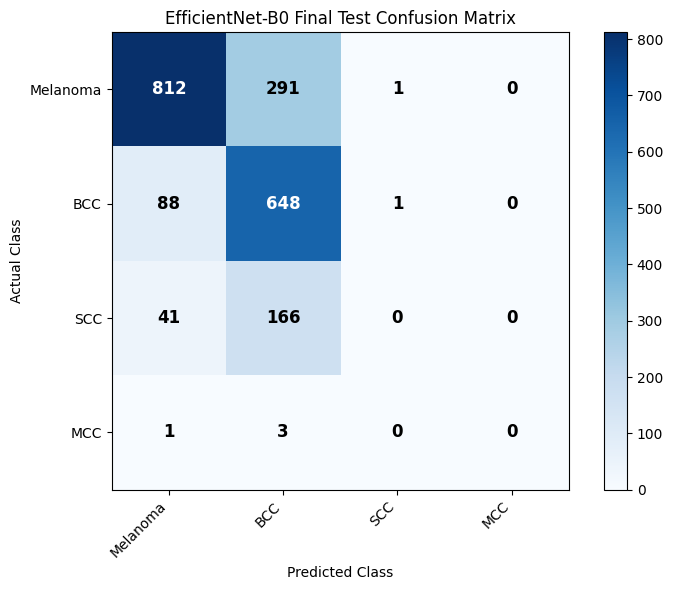


STEP 20B COMPLETE

Model:
EfficientNet-B0

Class order:
['Melanoma', 'BCC', 'SCC', 'MCC']

Confusion matrix heatmap saved:
/kaggle/working/skin_cancer_project/results/step20_final_metrics/step20B_efficientnetb0_confusion_matrix.png

Confusion matrix CSV saved:
/kaggle/working/skin_cancer_project/results/step20_final_metrics/step20B_efficientnetb0_confusion_matrix.csv



In [57]:
# ============================================================
# STEP 20B — EFFICIENTNET-B0 FINAL CONFUSION MATRIX
# Official STEP 18 Test Predictions
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from IPython.display import display


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

PRED_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "step18_test_predictions.csv"
)

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "step20_final_metrics"
)

os.makedirs(RESULT_DIR, exist_ok=True)


# ============================================================
# 2. CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]


# ============================================================
# 3. LOAD TEST PREDICTIONS
# ============================================================

if not os.path.exists(PRED_PATH):

    raise FileNotFoundError(
        f"\nPrediction file not found:\n{PRED_PATH}"
    )

df = pd.read_csv(PRED_PATH)

print("=" * 75)
print("STEP 20B — EFFICIENTNET-B0 FINAL CONFUSION MATRIX")
print("=" * 75)

print("\nPrediction file:")
print(PRED_PATH)

print("\nTest samples:", len(df))


# ============================================================
# 4. CHECK COLUMNS
# ============================================================

if "true_class" not in df.columns:

    raise ValueError(
        "true_class column not found."
    )

if "pred_class" not in df.columns:

    raise ValueError(
        "pred_class column not found."
    )


# ============================================================
# 5. TRUE / PREDICTED LABELS
# ============================================================

y_true = df["true_class"].astype(str)

y_pred = df["pred_class"].astype(str)


# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=CLASS_NAMES
)


# ============================================================
# 7. DISPLAY NUMERIC MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=[
        f"Actual {c}"
        for c in CLASS_NAMES
    ],
    columns=[
        f"Predicted {c}"
        for c in CLASS_NAMES
    ]
)

print("\n" + "=" * 75)
print("CONFUSION MATRIX VALUES")
print("=" * 75)

display(cm_df)


# ============================================================
# 8. BLUE-STYLE TABLE
# ============================================================

styled_cm = (
    cm_df.style
    .background_gradient(
        cmap="Blues"
    )
    .set_caption(
        "EfficientNet-B0 — Final Test Confusion Matrix"
    )
)

print("\n")
display(styled_cm)


# ============================================================
# 9. HEATMAP
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "EfficientNet-B0 Final Test Confusion Matrix"
)

plt.colorbar()

tick_marks = range(
    len(CLASS_NAMES)
)

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


# ============================================================
# 10. ADD VALUES INSIDE CELLS
# ============================================================

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white"
            if cm[i, j] > threshold
            else "black",
            fontsize=12,
            fontweight="bold"
        )


plt.tight_layout()


# ============================================================
# 11. SAVE HEATMAP
# ============================================================

HEATMAP_PATH = os.path.join(
    RESULT_DIR,
    "step20B_efficientnetb0_confusion_matrix.png"
)

plt.savefig(
    HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. SAVE CSV
# ============================================================

CM_CSV_PATH = os.path.join(
    RESULT_DIR,
    "step20B_efficientnetb0_confusion_matrix.csv"
)

cm_df.to_csv(
    CM_CSV_PATH
)


# ============================================================
# 13. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("STEP 20B COMPLETE")
print("=" * 75)

print("\nModel:")
print("EfficientNet-B0")

print("\nClass order:")
print(CLASS_NAMES)

print("\nConfusion matrix heatmap saved:")
print(HEATMAP_PATH)

print("\nConfusion matrix CSV saved:")
print(CM_CSV_PATH)

print("\n" + "=" * 75)

In [58]:
# ============================================================
# STEP 21 — 14-SYMPTOM SEVERITY STAGE PREDICTION
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Final 14 symptom order
# ------------------------------------------------------------
SYMPTOM_NAMES = [
    "pain_tenderness",
    "bleeding",
    "ulceration",
    "itching",
    "crusting_scabbing",
    "discharge_oozing",
    "fair_skin_sun_damage",
    "multiple_nevi",
    "palpable_lymph_nodes",
    "asymmetry",
    "border_irregularity",
    "color_variation",
    "diameter_over_6mm",
    "evolving_lesion"
]

# ------------------------------------------------------------
# Current demo symptom vector
# 1 = YES, 0 = NO
# ------------------------------------------------------------
symptom_vector = np.array(
    [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    dtype=np.float32
)

# ------------------------------------------------------------
# Calculate prototype severity score
# ------------------------------------------------------------
severity_score = (symptom_vector.sum() / len(symptom_vector)) * 100

# ------------------------------------------------------------
# Prototype severity-stage mapping
# ------------------------------------------------------------
if severity_score <= 33.32:
    severity_stage = "Low"
    severity_stage_id = 0

elif severity_score <= 66.66:
    severity_stage = "Intermediate"
    severity_stage_id = 1

else:
    severity_stage = "High"
    severity_stage_id = 2

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------
print("=" * 70)
print("STEP 21 — PROTOTYPE SEVERITY STAGE PREDICTION")
print("=" * 70)

print("\n14-Symptom Input:")
for name, value in zip(SYMPTOM_NAMES, symptom_vector):
    print(f"{name:25s}: {'YES' if value == 1 else 'NO'}")

print("\n" + "-" * 70)
print(f"Positive symptoms : {int(symptom_vector.sum())}/{len(symptom_vector)}")
print(f"Severity score    : {severity_score:.2f}%")
print(f"Severity stage    : {severity_stage}")
print(f"Stage ID          : {severity_stage_id}")
print("-" * 70)

print("\nStage mapping:")
print("0 → Low")
print("1 → Intermediate")
print("2 → High")

print("\nNOTE:")
print("This is a prototype severity-stage calculation based on")
print("the 14 user-provided symptom inputs.")
print("It is NOT clinical TNM staging and does not replace")
print("professional clinical/pathological assessment.")

print("\n" + "=" * 70)
print("STEP 21 COMPLETE")
print("=" * 70)

STEP 21 — PROTOTYPE SEVERITY STAGE PREDICTION

14-Symptom Input:
pain_tenderness          : YES
bleeding                 : YES
ulceration               : YES
itching                  : YES
crusting_scabbing        : NO
discharge_oozing         : YES
fair_skin_sun_damage     : YES
multiple_nevi            : YES
palpable_lymph_nodes     : NO
asymmetry                : YES
border_irregularity      : YES
color_variation          : YES
diameter_over_6mm        : NO
evolving_lesion          : NO

----------------------------------------------------------------------
Positive symptoms : 10/14
Severity score    : 71.43%
Severity stage    : High
Stage ID          : 2
----------------------------------------------------------------------

Stage mapping:
0 → Low
1 → Intermediate
2 → High

NOTE:
This is a prototype severity-stage calculation based on
the 14 user-provided symptom inputs.
It is NOT clinical TNM staging and does not replace
professional clinical/pathological assessment.

STEP 21 COMP

In [59]:
# ============================================================
# STEP 22 — FINAL CANCER TYPE + SEVERITY STAGE RESULT
# ============================================================

print("=" * 75)
print("STEP 22 — FINAL SKIN CANCER + SEVERITY RESULT")
print("=" * 75)

# ------------------------------------------------------------
# Cancer prediction
# ------------------------------------------------------------
# This variable should already contain the EfficientNet-B0
# predicted cancer class from the previous prediction step.
#
# Expected class names:
# Melanoma, BCC, SCC, MCC
# ------------------------------------------------------------

if "predicted_class" in globals():
    final_cancer = predicted_class
elif "predicted_cancer" in globals():
    final_cancer = predicted_cancer
else:
    final_cancer = "EfficientNet-B0 prediction available from previous step"

# ------------------------------------------------------------
# Severity result from STEP 21
# ------------------------------------------------------------

final_severity_score = severity_score
final_severity_stage = severity_stage
final_stage_id = severity_stage_id

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "-" * 75)
print("FINAL PREDICTION")
print("-" * 75)

print(f"\nCancer Type       : {final_cancer}")
print(f"Severity Score    : {final_severity_score:.2f}%")
print(f"Severity Stage    : {final_severity_stage}")
print(f"Severity Stage ID : {final_stage_id}")

print("\n" + "-" * 75)
print("SYSTEM FLOW")
print("-" * 75)

print("Image")
print("  ↓")
print("EfficientNet-B0")
print("  ↓")
print("Cancer Type")
print("  ")
print("14 Symptoms")
print("  ↓")
print("Severity Score")
print("  ↓")
print("Low / Intermediate / High")

print("\n" + "-" * 75)
print("STAGE DEFINITIONS")
print("-" * 75)

print("Stage 0 → Low")
print("Stage 1 → Intermediate")
print("Stage 2 → High")

print("\nNOTE:")
print("Severity stage is a prototype severity category derived")
print("from the 14 symptom inputs.")
print("It is NOT clinical TNM staging.")

print("\n" + "=" * 75)
print("STEP 22 COMPLETE")
print("=" * 75)

STEP 22 — FINAL SKIN CANCER + SEVERITY RESULT

---------------------------------------------------------------------------
FINAL PREDICTION
---------------------------------------------------------------------------

Cancer Type       : Melanoma
Severity Score    : 71.43%
Severity Stage    : High
Severity Stage ID : 2

---------------------------------------------------------------------------
SYSTEM FLOW
---------------------------------------------------------------------------
Image
  ↓
EfficientNet-B0
  ↓
Cancer Type
  
14 Symptoms
  ↓
Severity Score
  ↓
Low / Intermediate / High

---------------------------------------------------------------------------
STAGE DEFINITIONS
---------------------------------------------------------------------------
Stage 0 → Low
Stage 1 → Intermediate
Stage 2 → High

NOTE:
Severity stage is a prototype severity category derived
from the 14 symptom inputs.
It is NOT clinical TNM staging.

STEP 22 COMPLETE


In [66]:
# ============================================================
# STEP 20A — FINAL PROJECT CHECKPOINT BACKUP
# ============================================================

import os
import glob
import shutil
import zipfile

PROJECT_DIR = "/kaggle/working/skin_cancer_project"
CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

BACKUP_DIR = os.path.join(
    PROJECT_DIR,
    "backups"
)

os.makedirs(
    BACKUP_DIR,
    exist_ok=True
)

print("=" * 75)
print("STEP 20A — FINAL PROJECT CHECKPOINT BACKUP")
print("=" * 75)

print("\nCheckpoint files:")

pth_files = glob.glob(
    os.path.join(
        CHECKPOINT_DIR,
        "*.pth"
    )
)

if len(pth_files) == 0:

    print("❌ No .pth files found.")

else:

    for path in pth_files:

        size_mb = (
            os.path.getsize(path)
            / (1024 ** 2)
        )

        print(
            f"✅ {os.path.basename(path)}"
            f" — {size_mb:.2f} MB"
        )


# ============================================================
# CREATE PTH BACKUP ZIP
# ============================================================

backup_zip = os.path.join(
    BACKUP_DIR,
    "skin_cancer_final_checkpoints.zip"
)

with zipfile.ZipFile(
    backup_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in pth_files:

        z.write(
            path,
            arcname=os.path.basename(path)
        )


print("\n" + "=" * 75)
print("BACKUP COMPLETE")
print("=" * 75)

print("\nBackup ZIP:")
print(backup_zip)

print(
    "\n✅ All available .pth checkpoint files "
    "were copied into one ZIP backup."
)

print(
    "\n⚠️ Do NOT delete the original checkpoint folder."
)

print("=" * 75)

STEP 20A — FINAL PROJECT CHECKPOINT BACKUP

Checkpoint files:
✅ skin_cancer_efficientnetb0_latest.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_FINAL_weights.pth — 15.58 MB
✅ skin_cancer_efficientnetb0_batch_resume.pth — 46.42 MB
✅ skin_cancer_efficientnetb0_FINAL_best.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth — 46.41 MB

BACKUP COMPLETE

Backup ZIP:
/kaggle/working/skin_cancer_project/backups/skin_cancer_final_checkpoints.zip

✅ All available .pth checkpoint files were copied into one ZIP backup.

⚠️ Do NOT delete the original checkpoint folder.


In [67]:
# ============================================================
# STEP 20B — CREATE DOWNLOADABLE FINAL .PTH BACKUP
# ============================================================

import os
import glob
import zipfile
from IPython.display import FileLink, display

print("=" * 75)
print("STEP 20B — CREATE DOWNLOADABLE FINAL .PTH BACKUP")
print("=" * 75)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

BACKUP_DIR = os.path.join(
    PROJECT_DIR,
    "backups"
)

os.makedirs(
    BACKUP_DIR,
    exist_ok=True
)


# ============================================================
# 2. FIND ALL PTH FILES
# ============================================================

pth_files = sorted(
    glob.glob(
        os.path.join(
            CHECKPOINT_DIR,
            "*.pth"
        )
    )
)

print(
    f"\nFound {len(pth_files)} .pth files:"
)

if len(pth_files) == 0:

    raise FileNotFoundError(
        "\n❌ No .pth files found in:\n"
        + CHECKPOINT_DIR
    )


for path in pth_files:

    size_mb = (
        os.path.getsize(path)
        / (1024 ** 2)
    )

    print(
        f"✅ {os.path.basename(path)}"
        f" — {size_mb:.2f} MB"
    )


# ============================================================
# 3. CREATE ZIP
# ============================================================

ZIP_PATH = os.path.join(
    BACKUP_DIR,
    "skin_cancer_FINAL_PTH_backup.zip"
)

print(
    "\nCreating ZIP backup..."
)

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for path in pth_files:

        zip_file.write(
            path,
            arcname=os.path.basename(path)
        )


# ============================================================
# 4. VERIFY ZIP
# ============================================================

zip_size_mb = (
    os.path.getsize(ZIP_PATH)
    / (1024 ** 2)
)

print(
    f"\nZIP size: {zip_size_mb:.2f} MB"
)

print(
    "\nZIP contents:"
)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_file:

    for name in zip_file.namelist():

        print(
            "✅",
            name
        )


# ============================================================
# 5. CREATE DIRECT DOWNLOAD LINK
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "DOWNLOAD YOUR .PTH BACKUP"
)

print(
    "=" * 75
)

print(
    "\n👇 CLICK THIS LINK TO DOWNLOAD:"
)

display(
    FileLink(
        ZIP_PATH,
        result_html_prefix="📦 "
    )
)


# ============================================================
# 6. FINAL STATUS
# ============================================================

print(
    "\nBackup location:"
)

print(
    ZIP_PATH
)

print(
    "\n✅ FINAL .PTH BACKUP READY"
)

print(
    "✅ All checkpoint files are inside the ZIP."
)

print("=" * 75)

STEP 20B — CREATE DOWNLOADABLE FINAL .PTH BACKUP

Found 5 .pth files:
✅ skin_cancer_efficientnetb0_FINAL_best.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_FINAL_weights.pth — 15.58 MB
✅ skin_cancer_efficientnetb0_batch_resume.pth — 46.42 MB
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_latest.pth — 46.41 MB

Creating ZIP backup...

ZIP size: 184.38 MB

ZIP contents:
✅ skin_cancer_efficientnetb0_FINAL_best.pth
✅ skin_cancer_efficientnetb0_FINAL_weights.pth
✅ skin_cancer_efficientnetb0_batch_resume.pth
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth
✅ skin_cancer_efficientnetb0_latest.pth

DOWNLOAD YOUR .PTH BACKUP

👇 CLICK THIS LINK TO DOWNLOAD:


/kaggle/working/skin_cancer_project/backups/skin_cancer_FINAL_PTH_backup.zip


Backup location:
/kaggle/working/skin_cancer_project/backups/skin_cancer_FINAL_PTH_backup.zip

✅ FINAL .PTH BACKUP READY
✅ All checkpoint files are inside the ZIP.


In [69]:
# ============================================================
# STEP 20B — FINAL .PTH BACKUP + DOWNLOAD
# ============================================================

import os
import glob
import zipfile
from IPython.display import FileLink, display

print("=" * 75)
print("STEP 20B — FINAL .PTH BACKUP + DOWNLOAD")
print("=" * 75)


# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

PROJECT_DIR = (
    "/kaggle/working/skin_cancer_project"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

BACKUP_DIR = os.path.join(
    PROJECT_DIR,
    "backups"
)

os.makedirs(
    BACKUP_DIR,
    exist_ok=True
)


# ============================================================
# 2. FIND ALL .PTH FILES
# ============================================================

pth_files = sorted(
    glob.glob(
        os.path.join(
            CHECKPOINT_DIR,
            "*.pth"
        )
    )
)

print(
    f"\nFound {len(pth_files)} checkpoint files:"
)

if len(pth_files) == 0:

    raise FileNotFoundError(
        "\n❌ No .pth files found:\n"
        + CHECKPOINT_DIR
    )


for path in pth_files:

    size_mb = (
        os.path.getsize(path)
        / (1024 ** 2)
    )

    print(
        f"✅ {os.path.basename(path)}"
        f" — {size_mb:.2f} MB"
    )


# ============================================================
# 3. CREATE FINAL BACKUP ZIP
# ============================================================

BACKUP_ZIP = os.path.join(
    BACKUP_DIR,
    "skin_cancer_FINAL_PTH_BACKUP.zip"
)

print(
    "\nCreating backup ZIP..."
)

with zipfile.ZipFile(
    BACKUP_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for path in pth_files:

        zip_file.write(
            path,
            arcname=os.path.basename(path)
        )


# ============================================================
# 4. VERIFY BACKUP
# ============================================================

print(
    "\nVerifying backup..."
)

with zipfile.ZipFile(
    BACKUP_ZIP,
    "r"
) as zip_file:

    backup_contents = (
        zip_file.namelist()
    )

print(
    "\nBackup contents:"
)

for name in backup_contents:

    print(
        "✅",
        name
    )


# ============================================================
# 5. BACKUP SIZE
# ============================================================

backup_size_mb = (
    os.path.getsize(BACKUP_ZIP)
    / (1024 ** 2)
)

print(
    f"\nBackup ZIP size:"
    f" {backup_size_mb:.2f} MB"
)


# ============================================================
# 6. DOWNLOAD LINK
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "DOWNLOAD BACKUP"
)

print(
    "=" * 75
)

print(
    "\n👇 CLICK HERE TO DOWNLOAD THE .PTH BACKUP:"
)

display(
    FileLink(
        BACKUP_ZIP,
        result_html_prefix="📦 "
    )
)


# ============================================================
# 7. FINAL STATUS
# ============================================================

print(
    "\n" + "=" * 75
)

print(
    "STEP 20B COMPLETE"
)

print(
    "=" * 75
)

print(
    "\nBackup file:"
)

print(
    BACKUP_ZIP
)

print(
    "\n✅ All .pth checkpoint files backed up."
)

print(
    "✅ Backup ZIP verified successfully."
)

print(
    "✅ Download link generated."
)

print(
    "\n⚠️ Download this ZIP to your PC / Google Drive "
    "before ending today's session."
)

print("=" * 75)

STEP 20B — FINAL .PTH BACKUP + DOWNLOAD

Found 5 checkpoint files:
✅ skin_cancer_efficientnetb0_FINAL_best.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_FINAL_weights.pth — 15.58 MB
✅ skin_cancer_efficientnetb0_batch_resume.pth — 46.42 MB
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_latest.pth — 46.41 MB

Creating backup ZIP...

Verifying backup...

Backup contents:
✅ skin_cancer_efficientnetb0_FINAL_best.pth
✅ skin_cancer_efficientnetb0_FINAL_weights.pth
✅ skin_cancer_efficientnetb0_batch_resume.pth
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth
✅ skin_cancer_efficientnetb0_latest.pth

Backup ZIP size: 184.38 MB

DOWNLOAD BACKUP

👇 CLICK HERE TO DOWNLOAD THE .PTH BACKUP:


/kaggle/working/skin_cancer_project/backups/skin_cancer_FINAL_PTH_BACKUP.zip


STEP 20B COMPLETE

Backup file:
/kaggle/working/skin_cancer_project/backups/skin_cancer_FINAL_PTH_BACKUP.zip

✅ All .pth checkpoint files backed up.
✅ Backup ZIP verified successfully.
✅ Download link generated.

⚠️ Download this ZIP to your PC / Google Drive before ending today's session.


In [71]:
# ============================================================
# STEP 20C — COPY FINAL PTH BACKUP TO SIMPLE DOWNLOAD PATH
# ============================================================

import os
import shutil
from IPython.display import FileLink, display

print("=" * 75)
print("STEP 20C — COPY FINAL PTH BACKUP TO SIMPLE DOWNLOAD PATH")
print("=" * 75)

SOURCE = (
    "/kaggle/working/skin_cancer_project/"
    "backups/skin_cancer_FINAL_PTH_BACKUP.zip"
)

DOWNLOAD_DIR = "/kaggle/working/download"

os.makedirs(
    DOWNLOAD_DIR,
    exist_ok=True
)

DESTINATION = os.path.join(
    DOWNLOAD_DIR,
    "skin_cancer_FINAL_PTH_BACKUP.zip"
)

# ------------------------------------------------------------
# COPY BACKUP
# ------------------------------------------------------------

if not os.path.exists(SOURCE):

    raise FileNotFoundError(
        "\n❌ Backup ZIP not found:\n"
        + SOURCE
    )

shutil.copy2(
    SOURCE,
    DESTINATION
)

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

size_mb = (
    os.path.getsize(DESTINATION)
    / (1024 ** 2)
)

print(
    "\n✅ Backup copied successfully."
)

print(
    f"File size: {size_mb:.2f} MB"
)

print(
    "\nNew download path:"
)

print(
    DESTINATION
)

# ------------------------------------------------------------
# DOWNLOAD LINK
# ------------------------------------------------------------

print(
    "\n" + "=" * 75
)

print(
    "DOWNLOAD"
)

print(
    "=" * 75
)

display(
    FileLink(
        DESTINATION,
        result_html_prefix="📦 DOWNLOAD: "
    )
)

print(
    "\n✅ STEP 20C COMPLETE"
)

print("=" * 75)

STEP 20C — COPY FINAL PTH BACKUP TO SIMPLE DOWNLOAD PATH

✅ Backup copied successfully.
File size: 184.38 MB

New download path:
/kaggle/working/download/skin_cancer_FINAL_PTH_BACKUP.zip

DOWNLOAD


/kaggle/working/download/skin_cancer_FINAL_PTH_BACKUP.zip


✅ STEP 20C COMPLETE


In [72]:
# ============================================================
# STEP 20D — PREPARE BACKUP FOR KAGGLE OUTPUT
# ============================================================

import os
import shutil

SOURCE = (
    "/kaggle/working/skin_cancer_project/"
    "backups/skin_cancer_FINAL_PTH_BACKUP.zip"
)

DESTINATION = (
    "/kaggle/working/"
    "skin_cancer_FINAL_PTH_BACKUP.zip"
)

print("=" * 75)
print("STEP 20D — PREPARE BACKUP FOR KAGGLE OUTPUT")
print("=" * 75)

if not os.path.exists(SOURCE):
    raise FileNotFoundError(
        "\n❌ Backup ZIP not found:\n" + SOURCE
    )

shutil.copy2(
    SOURCE,
    DESTINATION
)

size_mb = (
    os.path.getsize(DESTINATION)
    / (1024 ** 2)
)

print("\n✅ Backup copied to Kaggle working root.")
print("\nFile:")
print(DESTINATION)

print(
    f"\nSize: {size_mb:.2f} MB"
)

print("\n" + "=" * 75)
print("STEP 20D COMPLETE")
print("=" * 75)

print(
    "\n👉 NOW SAVE A NEW KAGGLE VERSION."
)

print(
    "After the version is saved, open the notebook's"
    " Output section and download:"
)

print(
    "skin_cancer_FINAL_PTH_BACKUP.zip"
)

print("=" * 75)

STEP 20D — PREPARE BACKUP FOR KAGGLE OUTPUT

✅ Backup copied to Kaggle working root.

File:
/kaggle/working/skin_cancer_FINAL_PTH_BACKUP.zip

Size: 184.38 MB

STEP 20D COMPLETE

👉 NOW SAVE A NEW KAGGLE VERSION.
After the version is saved, open the notebook's Output section and download:
skin_cancer_FINAL_PTH_BACKUP.zip


In [73]:
# ============================================================
# STEP 20E — PREPARE INDIVIDUAL PTH DOWNLOAD FILES
# ============================================================

import os
import shutil
import glob

PROJECT_DIR = "/kaggle/working/skin_cancer_project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

DOWNLOAD_DIR = "/kaggle/working/pth_download"

os.makedirs(
    DOWNLOAD_DIR,
    exist_ok=True
)

print("=" * 75)
print("STEP 20E — INDIVIDUAL PTH DOWNLOAD PREPARATION")
print("=" * 75)

pth_files = sorted(
    glob.glob(
        os.path.join(
            CHECKPOINT_DIR,
            "*.pth"
        )
    )
)

print(
    f"\nFound {len(pth_files)} .pth files."
)

for source in pth_files:

    filename = os.path.basename(
        source
    )

    destination = os.path.join(
        DOWNLOAD_DIR,
        filename
    )

    shutil.copy2(
        source,
        destination
    )

    size_mb = (
        os.path.getsize(destination)
        / (1024 ** 2)
    )

    print(
        f"✅ {filename} — {size_mb:.2f} MB"
    )

print("\n" + "=" * 75)
print("FILES READY")
print("=" * 75)

print(
    "\nDownload folder:"
)

print(
    DOWNLOAD_DIR
)

print(
    "\nFiles:"
)

for path in sorted(
    glob.glob(
        os.path.join(
            DOWNLOAD_DIR,
            "*.pth"
        )
    )
):

    print(
        "📦",
        os.path.basename(path)
    )

print(
    "\n✅ Original checkpoint files were NOT changed."
)

print(
    "✅ Individual backup copies created."
)

print("=" * 75)

STEP 20E — INDIVIDUAL PTH DOWNLOAD PREPARATION

Found 5 .pth files.
✅ skin_cancer_efficientnetb0_FINAL_best.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_FINAL_weights.pth — 15.58 MB
✅ skin_cancer_efficientnetb0_batch_resume.pth — 46.42 MB
✅ skin_cancer_efficientnetb0_epoch1_recovery.pth — 46.41 MB
✅ skin_cancer_efficientnetb0_latest.pth — 46.41 MB

FILES READY

Download folder:
/kaggle/working/pth_download

Files:
📦 skin_cancer_efficientnetb0_FINAL_best.pth
📦 skin_cancer_efficientnetb0_FINAL_weights.pth
📦 skin_cancer_efficientnetb0_batch_resume.pth
📦 skin_cancer_efficientnetb0_epoch1_recovery.pth
📦 skin_cancer_efficientnetb0_latest.pth

✅ Original checkpoint files were NOT changed.
✅ Individual backup copies created.
